<a href="https://colab.research.google.com/github/Kripit/AI_series_till_genai/blob/main/AI_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 1 — Linear Regression**

* price = w x size + b

* w is the slope - how much does price go up per extra square foot? b is the intercept whats the base price even if size were 0


> Our job is to find the right w and b. thats it, everything else is about how to find them optimally

---

**Part 2 — The math, built from scratch**

What does "best line" mean?


```
Suppose your line predicts house price as ŷ (y-hat) but the real price is y. The error for one house is:
```


> error = y - ŷ = y - (w·x + b)



1.   You have many houses. You want to minimize all errors at once. But errors can be positive (you predicted too low) or negative (too high).

2.  If you just add them up they cancel out. A model that is always wrong by +100 on half the houses and -100 on the other half would look perfect. That's wrong.

**Solution: square the errors. Squaring does two things:**

1. Makes all errors positive — no cancellation

2. Punishes big errors harder (an error of 10 becomes 100 after squaring, but an error of 2 becomes only 4)

* So the total loss — called Mean Squared Error (MSE) — is:

```
MSE = (1/n) × Σᵢ (yᵢ - (w·xᵢ + b))²
```


Read this as: for each data point i, compute the difference between the real value and your prediction, square it, add them all up, divide by n to get the average.



> The goal
Find w and b that make MSE as small as possible. This is an optimization problem.









## How do we find the minimum? — Calculus
To find where a function hits its minimum, you take the derivative and set it to zero. The derivative tells you the slope of the function at any point — at the minimum, the slope is flat, so derivative = 0.


---


**Derivative with respect to w:**
`∂MSE/∂w = (2/n) × Σᵢ (ŷᵢ - yᵢ) × xᵢ`
How to read this: for each data point, compute how wrong your prediction was (ŷᵢ - yᵢ), multiply it by the input xᵢ, average all of them, multiply by 2.



---


**Derivative with respect to b:**
`∂MSE/∂b = (2/n) × Σᵢ (ŷᵢ - yᵢ)`
Same thing but without multiplying by xᵢ.

These derivatives are called **gradients**. They tell you: if you increase w slightly, does the loss go up or down — and by how much?



---


**Gradient descent — the algorithm**
Instead of solving for zero analytically (which gets hard in complex models), we do this iteratively:

1. Start with random w and b
2. Compute the gradient
3. Move w and b a small step in the opposite direction of the gradient (because we want to go downhill)
4. Repeat until the loss stops decreasing

`w := w - α × ∂MSE/∂w`
`b := b - α × ∂MSE/∂b`

`α` (alpha) is the **learning rate** — how big each step is. Too big and you overshoot the minimum. Too small and it takes forever.

In [ ]:
from IPython.display import HTML

# Read the content of the HTML file
with open('/content/linear_regression_loss_surface (1).html', 'r') as f:
    html_content = f.read()

# Display the HTML content
HTML(html_content)

In [ ]:
# STEP 1 - IMPORT LIBRARIES

import numpy as np

# STEP 2 - CREATE FAKE DATA TO TEST ON

np.random.seed(42)

# it sets the random number generator to fixed starting point, this means every time you run this code u get the same "random" number.
#without this, every run gives different data and your results change, making debugging impossible. 42 is just a convention - any number works

n = 100 # we will make 100 data points

X = 2*np.random.rand(n,1)

#it creates and array of shape (100,1) - 100 rows and 1 column- fillwed with random numbers between 0 and 1
#multiplyin by 2 stretches the range to 0-1. the shape (100,1) matters: its a column vector, not a flat list. this lets numpy do the matrix math later correctly

y = 4 + 3 * X + np.random.randn(n,1)
# this creates our target values, the true relationship is y = 4+3x ( so true b = 4 and true w = 3)
#we add np.random.randn - gaussian noise - to simulate real-world messsiness.
# the model's job is to recover  w≈3 and b≈4 from this noisy data.

# STEP 3 - SCALE THE FEATURES

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

# X.mean() computes the average of all values in X.
# X.std() computes the standard deviation — how spread out the values are
# Subtracting the mean and dividing by std is called standardization. After this, X has mean=0 and std=1.
# Why? Because gradient descent is sensitive to the scale of features. If one feature is in the millions and another is in the 0–1 range, the gradients will be wildly different in magnitude and the optimization bounces around. Scaling makes all features live on the same scale and gradient descent converges much faster.
# Critical mistake beginners make: Compute mean and std on the training data only. Apply those same numbers to the test data. Never compute stats on test data — that's cheating (you'd be using future information).


# STEP 4 - INTIALIZE PARAMETERS

w = 0.0
b = 0.0

# Start with a guess. For linear regression any starting point works because the loss surface is convex (bowl-shaped) — there's only one minimum, so we always find it regardless of where we start. For neural networks, initialization is a much deeper topic.

# STEP 5 - THE TRAINING LOOP

learning_rate = 0.1
epochs = 1000
n_samples = len(X_scaled)
loss_history = []

# learning_rate = 0.1 — the step size. We will move w and b by 10% of the gradient each step.
# epochs = 1000 — how many full passes through the data we do. Each pass is one opportunity to update w and b.
# n_samples = len(X_scaled) — stores 100, the number of data points. We need this to compute the average in the gradient formula.
# loss_history = [] — an empty list where we'll store the MSE at each epoch, so we can later plot how training progressed.

for epoch in range(epochs):

  y_pred = w * X_scaled + b

# This is the forward pass — given current w and b, predict y for every data point. Because X_scaled is a numpy array of shape (100, 1), this line computes w × xᵢ + b for all 100 points at once using numpy's vectorization. No Python loop needed. This is much faster.

  error = y_pred - y
#error is a (100, 1) array. Each entry is how wrong our prediction was for one data point. Positive means we predicted too high. Negative means too low.

  dw = ( 2 / n_samples  ) *  (X_scaled.T @error).sum()

# This is the gradient with respect to w. Let's unpack it:

# 1. X_scaled.T — .T is the transpose. Turns shape (100,1) into (1,100). Think of it as flipping rows and columns
# 2. @ error — the @ operator is matrix multiplication. (1,100) @ (100,1) = (1,1) — it multiplies each xᵢ by its errorᵢ and sums them all. This is exactly Σ xᵢ × errorᵢ from the math.
# 3. .sum() — flattens the result to a plain Python number.
# 4. (2 / n_samples) — the 2/n factor from the derivative.

  db = ( 2 / n_samples ) * error.sum()

# Gradient with respect to b. Simpler — just the average error, scaled by 2/n. No xᵢ multiplication because when we differentiated with respect to b, xᵢ disappeared (the derivative of w·xᵢ + b with respect to b is just 1).

  w -= learning_rate * dw
  b -= learning_rate * db

# Parameter update. We subtract because we want to go downhill. The gradient points uphill (toward higher loss), so moving opposite to it reduces the loss. learning_rate controls the step size.

  mse = ( error ** 2).mean()
  loss_history.append(mse)



## STEP - 6 - PUT IT ALL TOGETHER AS A CLASS

Learned w: 1.5889
Learned b: 6.7581
Train R²:  0.7749
Test R²:   0.7297


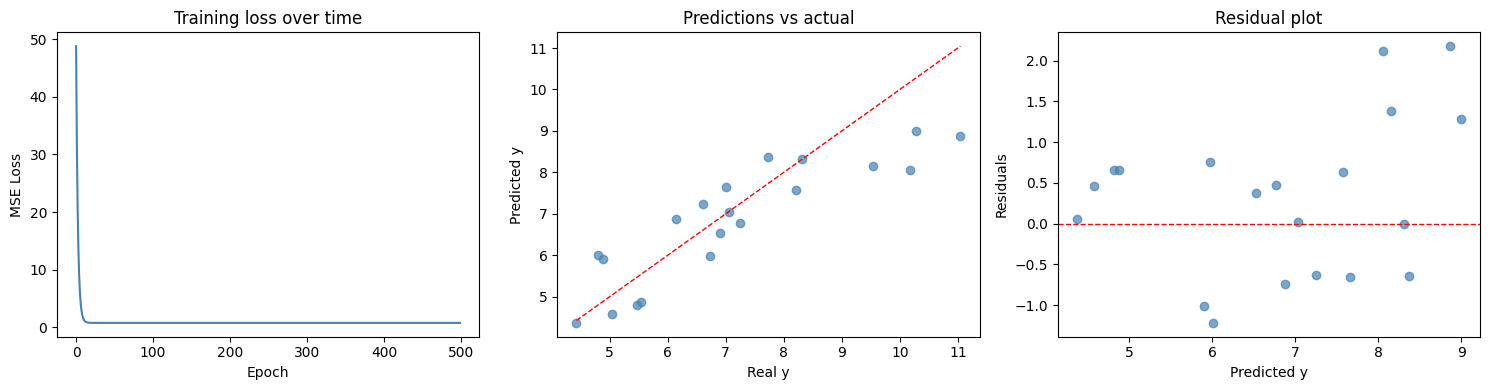

In [ ]:
import numpy as np

class LinearRegression:
    """
    Linear regression trained with gradient descent.
    Supports single and multiple features.
    """


    def __init__(self, learning_rate: float = 0.01, epochs: int = 1000):
      # __init__ is called when you do LinearRegression(lr = 0.1)
      # it sets up the object's intial state

      self.learning_rate = learning_rate    # how big each step is
      self.epochs = epochs        # how many training passes
      self.w = None             # weights — unknown until fit() is called
      self.b = 0.0            # bias starts at zero
      self.loss_history = []    # stores MSE per epoch for plotting


    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":

        """
        Train the model on data X with targets y.
        X shape: (n_samples, n_features)
        y shape: (n_samples,)
        Returns self so you can chain: model.fit(X, y).predict(X_test)
        """

        n_samples, n_features = X.shape
        #X.shape return a tuple like (100,3)
        #n_samples = 100 ( rows = datapoint )
        #n_features = 3 ( column = input variable )

        self.w = np.zeros(n_features)
        # np.zeros(n_features) creates an array [0., 0., 0.] — one weight per feature.
        # We start all weights at zero.

        self.b = 0.0
        #bias ( intercept ) starts at zerp

        self.loss_history = []
        # Reset history is case fit() is called again


        for epoch in range(self.epochs):

          y_pred = X @ self.w + self.b

            # Forward pass. X @ self.w is matrix multiplication:
            # X is (100, 3), self.w is (3,).
            # Result is (100,) — one prediction per sample.
            # + self.b adds the bias to every prediction.

          error = y_pred - y

          # shape: (100,). each entry: how wrong were we for that sample?

          dw = ( 2/ n_samples) * (X.T @ error)
            # Gradient for weights.
            # X.T is (3, 100). @ error is (3, 100) @ (100,) = (3,).
            # So dw has one value per weight — tells us how to adjust each w.
            # (2 / n_samples) is the scaling factor from the MSE derivative.

          db = (2 / n_samples) * error.sum()

            # Gradient for bias.
            # Sum all errors, divide by n, scale by 2.

          self.w -= self.learning_rate * dw        # Move each weight opposite to its gradient.
          self.b -= self.learning_rate * db        # Move bias opposite to its gradient.


          mse = ( error ** 2).mean()

              # Compute MSE: square all errors, take the mean.

          self.loss_history.append(float(mse))            # Store as plain float (not numpy scalar) for cleaner printing.


        return self
        # Returning self lets you write: model.fit(X, y).predict(X_new)

    def predict(self, X: np.ndarray) -> np.ndarray:

      """
      Given new input X, return predicted y values.
      This is just the formula y = wx+b
      """

      return X @ self.w + self.b

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """
        Returns R² — how much of the variance in y our model explains.
        R² = 1 means perfect predictions.
        R² = 0 means our model is no better than predicting the mean.
        R² < 0 means our model is worse than predicting the mean (bad).
        fit()      = learn
        predict()  = use what was learned
        error      = measure how wrong the prediction was
        """

        y_pred  = self.predict(X)

        ss_res = ((y - y_pred)**2).sum()
        # Sum of squared residuals — total prediction error.
        # y - y_pred is the residual for each sample.
        # ** 2 squares each one. .sum() adds them up.

        ss_tot = ((y - y.mean()) ** 2).sum()

        # Total sum of squares — how spread out the real values are.
        # y.mean() is the average of all targets.
        # If we subtract mean from each y, square, and sum — that's total variance.


        return 1 - (ss_res / ss_tot)
        # R² = 1 - (how much error remains / how much total variance exists)
        # If ss_res is tiny compared to ss_tot, R² is close to 1 — great.
        # If ss_res equals ss_tot, R² = 0 — as bad as predicting the mean


# --- Generate data ---
np.random.seed(42)
n = 100
X_raw = 2 * np.random.rand(n, 1)          # raw feature, shape (100, 1)
y     = (4 + 3 * X_raw + np.random.randn(n, 1)).ravel()
# .ravel() flattens (100, 1) to (100,) — a 1D array.
# Our model expects y to be 1D.

# --- Scale features ---
X_mean = X_raw.mean()
X_std  = X_raw.std()
X = (X_raw - X_mean) / X_std
# Now X has mean≈0 and std≈1. Same shape (100, 1).

# --- Split into train / test ---
split = 80
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
# First 80 samples for training. Last 20 for testing.
# We evaluate on test data the model has NEVER seen.

# --- Train ---
model = LinearRegression(learning_rate=0.1, epochs=500)
model.fit(X_train, y_train)
# fit() runs 500 gradient descent steps on the 80 training samples.

# --- Evaluate ---
train_r2 = model.score(X_train, y_train)
test_r2  = model.score(X_test, y_test)

print(f"Learned w: {model.w[0]:.4f}")   # should be close to the scaled version of 3
print(f"Learned b: {model.b:.4f}")       # should be close to the mean of y
print(f"Train R²:  {train_r2:.4f}")
print(f"Test R²:   {test_r2:.4f}")


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Loss curve ---
axes[0].plot(model.loss_history, color='steelblue', linewidth=1.5)
# model.loss_history is the list of MSE values we stored during training.
# A decreasing curve means the model is learning.
# If the curve is flat from epoch 0, your learning rate is too small.
# If it explodes upward, your learning rate is too large.
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training loss over time')

# --- Plot 2: Predictions vs real values ---
y_pred_test = model.predict(X_test)
axes[1].scatter(y_test, y_pred_test, alpha=0.7, color='steelblue')
# Each dot is one test sample.
# x-axis: real y value. y-axis: what the model predicted.
# Perfect predictions would fall exactly on the diagonal line y=x.
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1)
# This red dashed line is the "perfect prediction" reference.
axes[1].set_xlabel('Real y')
axes[1].set_ylabel('Predicted y')
axes[1].set_title('Predictions vs actual')

# --- Plot 3: Residuals ---
residuals = y_test - y_pred_test
# Residual = real - predicted. Positive = under-predicted. Negative = over-predicted.
axes[2].scatter(y_pred_test, residuals, alpha=0.7, color='steelblue')
axes[2].axhline(0, color='red', linewidth=1, linestyle='--')
# If the model is good, residuals should be randomly scattered around the zero line.
# If you see a pattern (curve, fan shape), the model is systematically wrong — you're missing something.
axes[2].set_xlabel('Predicted y')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residual plot')

plt.tight_layout()
# tight_layout() automatically adjusts spacing so subplots don't overlap.
plt.show()

# --- Note regarding epochs in scikit-learn's LinearRegression ---
# The sklearn.linear_model.LinearRegression used in the other cell (pqk9NdjwR3IC)
# does not use the concept of 'epochs'. It finds the optimal solution
# directly through a closed-form method (e.g., Ordinary Least Squares or SVD),
# rather than iterative gradient descent with epochs. Therefore, it does not have an 'epochs' parameter.

# **BY SKLEARN**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import  Pipeline
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score


# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.18, random_state=42
)
# test_size=0.2 means 20% goes to test set.
# random_state=42 makes the split reproducible.

# Build a pipeline: scale then fit, in one object


pipeline = Pipeline([
    ('scaler', StandardScaler()),

    # StandardScaler does (x - mean) / std — same as our manual scaling.
    # But it stores mean and std from training data and applies them to test data automatically.

    ('model', LinearRegression())
    # sklearn's LinearRegression uses SVD (a numerically stable matrix method)
    # instead of gradient descent — it finds the exact optimal weights directly.

])

pipeline.fit(X_train, y_train)
# Fits the scaler on X_train, transforms X_train, fits the model.
# ALL in one call. No data leakage risk.
y_pred = pipeline.predict(X_test)
# Transforms X_test using the TRAINING scaler, then predicts.
# Correct: test data gets scaled using training statistics.
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²:  {r2_score(y_test, y_pred):.4f}")


MSE: 0.7201
R²:  0.7922


## Part 4 — The 5 assumptions of linear regression (and what breaks when they're violated)
Knowing these is what separates someone who runs a model from someone who understands it.

1.  **Linearity** — the relationship between X and y is actually linear. If it's curved and you fit a line, your predictions will be systematically wrong. Fix: add polynomial features, or use a tree-based model.
2.  **Independence** — data points don't influence each other. Violated by time-series data (tomorrow's price depends on today's). Fix: time-series models.
3.  **Homoscedasticity** — error variance is constant. If errors are small for small y and large for large y, the model is less reliable at the high end. Fix: log-transform y.
4.  **Normality of residuals** — residuals (errors) should be roughly normally distributed. Important for confidence intervals and hypothesis tests. Fix: more data, better features.
5.  **No multicollinearity** — features shouldn't be strongly correlated with each other. If feature_A ≈ 2 × feature_B, the model can't tell which one matters and the weights become unstable. Fix: remove one, or use Ridge regression (Module 3).

## Part 5 — Interview questions answered deeply

**Q:** What is the difference between MSE and MAE?

MSE = mean of squared errors. MAE = mean of absolute errors.
MSE penalizes large errors much more (squaring). If your dataset has outliers — houses with freak prices — MSE will try hard to fit them and distort your line. MAE treats a $100k error the same as ten $10k errors. Use MAE when outliers exist and you don't want them to dominate. Use MSE when large errors are genuinely more dangerous than small ones.

**Q:** Why do we divide by n in MSE?

So the loss doesn't grow just because you have more data. With 1000 samples vs 100, the raw sum of squared errors would be ~10× larger even if the model is equally good. Dividing by n makes MSE comparable across datasets of different sizes.

**Q:** What happens if learning rate is too high?

The loss curve goes up instead of down, or bounces erratically. You are taking steps so large that you jump past the minimum to the other side of the bowl, then back again, never settling. Solution: lower the learning rate, or use learning rate schedules that start high and decay.

**Q:** Can linear regression have multiple outputs?

Yes. If y is a vector (e.g., predict both price and time-to-sell), you fit one set of weights per output. sklearn supports this natively.



---

---





## Module 2 — Logistic Regression
From zero to production. Every line explained. All math shown.

In [ ]:
from IPython.display import HTML

# Read the content of the HTML file
with open('/content/sigmoid_interactive.html', 'r') as f:
    html_content = f.read()

# Display the HTML content
HTML(html_content)

# 📘 Logistic Regression — Full Notes

---

## Part 3 — The Full Model

Logistic Regression is just **two steps**:

**Step 1 — Same as Linear Regression:**
$$z = w \cdot x + b$$

**Step 2 — Squeeze through Sigmoid:**
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

> 💡 **$\hat{y}$ is now a probability** — "the chance this sample belongs to class 1"

---

### Making a Hard Prediction (0 or 1)

Apply a **threshold** (usually 0.5):

| Condition | Prediction |
|-----------|-----------|
| $\hat{y} \geq 0.5$ | → **1** |
| $\hat{y} < 0.5$ | → **0** |

---

## Part 4 — Why Cross-Entropy Loss? (The *Why* Most Courses Skip)

### Starting From Probability

When the model outputs $\hat{y} = 0.8$, it's saying **"I'm 80% sure this is class 1."**

We train using **Maximum Likelihood Estimation (MLE)** — make the probabilities as accurate as possible.

For one data point:
- True label **y = 1** → we want $\hat{y}$ close to 1 → likelihood = $\hat{y}$
- True label **y = 0** → we want $\hat{y}$ close to 0 → likelihood = $1 - \hat{y}$

**Both cases in one formula (a neat trick):**

$$\text{likelihood} = \hat{y}^{\,y} \times (1 - \hat{y})^{(1-y)}$$

✅ Check:
- When **y = 1**: $\hat{y}^1 \times (1-\hat{y})^0 = \hat{y}$
- When **y = 0**: $\hat{y}^0 \times (1-\hat{y})^1 = 1 - \hat{y}$

---

### From Likelihood → Loss

**Maximize likelihood** across all $n$ samples:

$$\text{Maximize: } \prod_i \left[ \hat{y}_i^{\,y_i} \times (1 - \hat{y}_i)^{(1-y_i)} \right]$$

> ⚠️ Multiplying many tiny probabilities → numbers get **too small for computers** (underflow)

**Fix: Take the log** (log turns products into sums — numerically stable):

$$\text{Maximize: } \sum_i \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

**Maximizing = Minimizing the negative**, so flip the sign:

$$\boxed{L = -\frac{1}{n} \sum_i \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]}$$

> ✅ This is **Binary Cross-Entropy Loss** — not arbitrary, it comes directly from maximizing prediction probability.

---

### Why is it called "Cross-Entropy"?

- **Entropy** = measures uncertainty in a distribution
- **Cross-entropy** = measures how *different* two distributions are
  - Here: **y** (true) vs **ŷ** (predicted)
  - When they match perfectly → cross-entropy is at its minimum
  - When they diverge → cross-entropy goes up

> 🧠 We are literally measuring *how wrong our probabilities are* in information-theoretic terms.

---

### What Does the Loss Actually Do?

| Case | Prediction | Loss | Effect |
|------|-----------|------|--------|
| y = 1, $\hat{y}$ = 0.99 ✅ | Nearly correct | $-\log(0.99) \approx 0.01$ | **Tiny update** |
| y = 1, $\hat{y}$ = 0.01 ❌ | Catastrophically wrong | $-\log(0.01) \approx 4.60$ | **Massive update** |

> 💥 **Being confidently wrong is punished hard.** The model learns most from its biggest mistakes.

---

## Part 5 — The Gradients (Calculus Step by Step)

We need $\frac{\partial L}{\partial w}$ and $\frac{\partial L}{\partial b}$ to run gradient descent.

**Setup:**
$$z = w \cdot x + b$$
$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$
$$L = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

We use the **chain rule**: $w \rightarrow z \rightarrow \hat{y} \rightarrow L$

---

### Step 1 — Derivative of Sigmoid (Beautiful Result)

$$\frac{d\sigma}{dz} = \sigma(z) \cdot (1 - \sigma(z))$$

**Derivation:**

$$\sigma(z) = (1 + e^{-z})^{-1}$$

$$\frac{d\sigma}{dz} = -1 \cdot (1 + e^{-z})^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1+e^{-z})^2} = \sigma(z)(1 - \sigma(z))$$

> 💡 Gradient is **largest at z = 0** (maximum uncertainty), shrinks when the model is very confident.

---

### Step 2 — Derivative of Loss w.r.t. $\hat{y}$

$$\frac{\partial L}{\partial \hat{y}} = -\left[\frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}}\right]$$

---

### Step 3 — Chain Rule to get $\partial L / \partial z$

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}$$

After algebraic simplification, this collapses **beautifully** to:

$$\boxed{\frac{\partial L}{\partial z} = \hat{y} - y}$$

> ✨ **Prediction minus true label.** That's it. This is NOT a coincidence — cross-entropy and sigmoid were designed together to produce this clean result.

---

### Step 4 — From z to w and b

Since $z = w \cdot x + b$:

$$\frac{\partial z}{\partial w} = x \qquad \frac{\partial z}{\partial b} = 1$$

---

### Final Gradients (over all n samples)

$$\boxed{\frac{\partial L}{\partial w} = \frac{1}{n} \sum_i (\hat{y}_i - y_i) \cdot x_i}$$

$$\boxed{\frac{\partial L}{\partial b} = \frac{1}{n} \sum_i (\hat{y}_i - y_i)}$$

> 🔁 These look **almost identical to Linear Regression's gradients!**
> The only difference: $\hat{y}_i$ is now a **probability from the sigmoid**, not a raw linear output.
> **The training loop is the same — only the forward pass changes.**

# Step 1 — Create classification data

In [ ]:
import numpy as np

np.random.seed(42)

n = 200    # Fix the random seed so our results are reproducible.

X =np.random.randn(n,2) # We'll generate 200 data points.

# np.random.randn(n, 2) creates an array of shape (200, 2).
# Each row is one data point with 2 features.
# randn (note the 'n') gives values from a standard normal distribution
# (bell curve centred at 0, std 1). Unlike rand() which gives 0-1 uniform.
# We use 2 features so we can visualise the decision boundary in 2D.

y = ((X[:, 0] + X[:,1]) > 0).astype(float)

# X[:, 0] means: take ALL rows, column 0 (first feature).
# X[:, 1] means: take ALL rows, column 1 (second feature).
# X[:, 0] + X[:, 1] adds the two features together.
# > 0 checks if the sum is positive — gives True/False for each row.
# .astype(float) converts True→1.0, False→0.0.
# So: class 1 if (feature1 + feature2 > 0), else class 0.
# This creates a linearly separable problem — a diagonal decision boundary.

# Step 2 — The sigmoid function

In [ ]:
def sigmoid(z):
    # z can be a single number or a numpy array.
    # numpy will apply the formula element-wise automatically.
    return 1 / (1 + np.exp(-z))
    # np.exp(-z) computes e^(-z) for every element.
    # 1 + that = (1 + e^-z)
    # 1 / that = σ(z)
    # Output is always in (0, 1).

# Step 3 — The full LogisticRegression class

In [ ]:
class LogisticRegression:
    """
    Binary logistic regression trained with gradient descent.
    Output: probability that sample belongs to class 1.
    """

    def __init__(self, learning_rate: float = 0.1, epochs: int = 1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w = None      # weights — one per feature
        self.b = 0.0       # bias
        self.loss_history = []

    def sigmoid(self, z: np.ndarray) -> np.ndarray:
        # Same sigmoid formula. Defined as a method so the class is self-contained.
        return 1 / (1 + np.exp(-z))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        n_samples, n_features = X.shape
        # X.shape → (200, 2). So n_samples=200, n_features=2.

        self.w = np.zeros(n_features)
        # Start with weights = [0.0, 0.0] — one zero per feature.

        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.epochs):

            # ── Forward pass ──────────────────────────────────────────────
            z = X @ self.w + self.b
            # Matrix multiply X (200×2) by w (2,) → result is (200,).
            # Each entry: w[0]*x[0] + w[1]*x[1] + b for one sample.
            # This is the raw score (logit) before sigmoid.

            y_pred = self.sigmoid(z)
            # Pass every z through sigmoid → (200,) array of probabilities.
            # Each value is between 0 and 1.
            # y_pred[i] = "probability that sample i is class 1"

            # ── Loss (Binary Cross-Entropy) ───────────────────────────────
            epsilon = 1e-15
            # A tiny number to prevent log(0) which is -infinity.
            # log(0) would crash or produce NaN. This is called numerical stability.
            # 1e-15 means 0.000000000000001 — negligible effect on the math.

            loss = -np.mean(
                y * np.log(y_pred + epsilon) +
                (1 - y) * np.log(1 - y_pred + epsilon)
            )
            # Unpack this carefully:
            # y * np.log(y_pred + epsilon)
            #   → for each sample: true_label × log(predicted_probability)
            #   → when y=1: log(ŷ) — want this to be log(1)=0 (minimum loss)
            #   → when y=0: 0 × anything = 0 — this term vanishes
            #
            # (1 - y) * np.log(1 - y_pred + epsilon)
            #   → for each sample: (1-true_label) × log(1 - predicted_probability)
            #   → when y=0: log(1-ŷ) — want ŷ≈0 so log(1)=0 (minimum loss)
            #   → when y=1: 0 × anything = 0 — this term vanishes
            #
            # np.mean(...) averages over all 200 samples.
            # The minus sign converts max-likelihood to min-loss.

            self.loss_history.append(float(loss))

            # ── Gradients ─────────────────────────────────────────────────
            error = y_pred - y
            # (predicted - true) for every sample. Shape: (200,).
            # This is the clean result we derived in Part 5.
            # Positive error → predicted too high → need to reduce w.
            # Negative error → predicted too low → need to increase w.

            dw = (1 / n_samples) * (X.T @ error)
            # X.T is (2, 200). @ error is (2,200)×(200,) = (2,).
            # So dw has one gradient per weight.
            # For each weight: average of (error × corresponding feature value).
            # Dividing by n_samples makes the gradient independent of dataset size.

            db = (1 / n_samples) * error.sum()
            # Gradient for bias: just the average error.
            # No feature multiplication because ∂z/∂b = 1 (always).

            # ── Parameter update ──────────────────────────────────────────
            self.w -= self.learning_rate * dw
            # Move each weight in the direction that reduces loss.
            # If dw[0] is positive, loss increases when w[0] increases,
            # so we decrease w[0].

            self.b -= self.learning_rate * db
            # Same for bias.

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Return probability of class 1 for each sample."""
        z = X @ self.w + self.b
        # Compute raw scores.
        return self.sigmoid(z)
        # Apply sigmoid → probabilities.

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        """Return hard class labels (0 or 1)."""
        return (self.predict_proba(X) >= threshold).astype(int)
        # predict_proba gives probabilities.
        # >= threshold checks if each probability exceeds our cutoff.
        # .astype(int) converts True→1, False→0.
        # Default threshold 0.5: predict 1 if model is >50% confident.

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """Accuracy: fraction of correct predictions."""
        predictions = self.predict(X)
        # Get 0/1 predictions for every sample.
        return (predictions == y).mean()
        # predictions == y → True where correct, False where wrong.
        # .mean() → fraction of True values = accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Scale features ─────────────────────────────────────────────────────────
scaler = StandardScaler()
# StandardScaler will subtract mean and divide by std.

X_scaled = scaler.fit_transform(X)
# fit_transform on all data here (ok for a demo).
# In real code: fit_transform on train, transform on test only.

# ── Split ──────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
# test_size=0.2 → 20% of 200 = 40 test samples, 160 train samples.
# random_state=42 → same shuffle every run.

# ── Train ──────────────────────────────────────────────────────────────────
model = LogisticRegression(learning_rate=0.1, epochs=300)
model.fit(X_train, y_train)

# ── Evaluate ───────────────────────────────────────────────────────────────
train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)

probas = model.predict_proba(X_test)
# Get the actual probabilities, not just 0/1.
# Useful for metrics like ROC-AUC (Module 10).

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Learned weights: {model.w}")
print(f"Learned bias:    {model.b:.4f}")

Train accuracy: 0.9938
Test accuracy:  1.0000
Learned weights: [2.43456217 2.18377685]
Learned bias:    0.0338


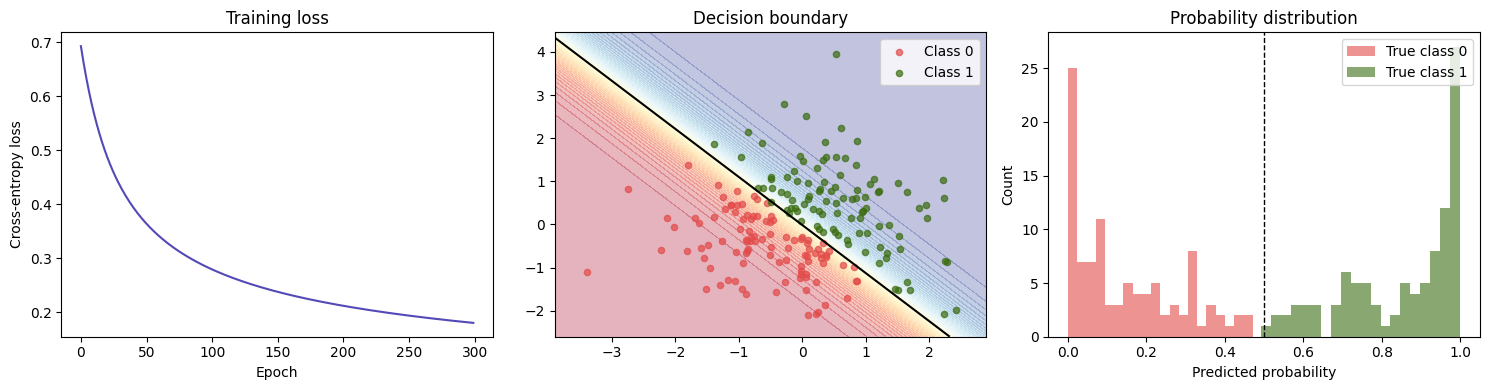

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Loss curve ──────────────────────────────────────────────────────
axes[0].plot(model.loss_history, color='#534AB7', linewidth=1.5)
# Cross-entropy loss per epoch. Should decrease and flatten.
# If it goes down fast then flatlines → model has converged.
# If it's noisy or goes up → learning rate too high.
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss')

# ── Plot 2: Decision boundary ───────────────────────────────────────────────
h = 0.02
# Resolution of the grid. Smaller = smoother boundary but slower to compute.

x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
# Find the range of each feature so we can create a grid covering all the data.
# We add/subtract 0.5 for a small margin around the data.

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
# np.meshgrid creates a 2D grid of (x, y) coordinates.
# xx has the x-coordinates, yy has the y-coordinates, for every point on the grid.
# Think of it as a very dense scatter plot covering the whole space.

grid_points = np.c_[xx.ravel(), yy.ravel()]
# xx.ravel() flattens the 2D grid to a 1D array.
# np.c_ joins two 1D arrays as columns → shape (n_grid_points, 2).
# This is a large array of [feature1, feature2] pairs for every grid point.

Z = model.predict_proba(grid_points).reshape(xx.shape)
# Predict probability of class 1 for every grid point.
# .reshape(xx.shape) converts the flat 1D predictions back to 2D grid shape.

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu', levels=50)
# contourf draws filled contours — it colours each region by probability.
# alpha=0.3 makes it semi-transparent so we can see the data points on top.
# cmap='RdYlBu' → red (class 1), yellow (boundary), blue (class 0).
# levels=50 → 50 colour bands → smooth gradient from 0 to 1.

axes[1].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
# contour draws the 0.5 probability line — the actual decision boundary.
# Where the model is exactly 50% confident.

class0 = X_scaled[y == 0]
class1 = X_scaled[y == 1]
# Split the data by true class label for plotting.

axes[1].scatter(class0[:, 0], class0[:, 1], c='#E24B4A', s=20, alpha=0.7, label='Class 0')
axes[1].scatter(class1[:, 0], class1[:, 1], c='#3B6D11', s=20, alpha=0.7, label='Class 1')
# Plot class 0 and class 1 data points in different colours.
# s=20 sets the marker size. alpha=0.7 makes overlapping points visible.

axes[1].set_title('Decision boundary')
axes[1].legend()

# ── Plot 3: Probability distribution ───────────────────────────────────────
all_probas = model.predict_proba(X_scaled)
# Get probabilities for all 200 samples.

axes[2].hist(all_probas[y == 0], bins=20, alpha=0.6, color='#E24B4A', label='True class 0')
# Histogram of predicted probabilities for true class 0 samples.
# We WANT these to cluster near 0 — model saying "pretty sure it's class 0".

axes[2].hist(all_probas[y == 1], bins=20, alpha=0.6, color='#3B6D11', label='True class 1')
# Histogram for true class 1. We WANT these to cluster near 1.

axes[2].axvline(x=0.5, color='black', linestyle='--', linewidth=1)
# Vertical line at 0.5 — the default decision threshold.

axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Probability distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

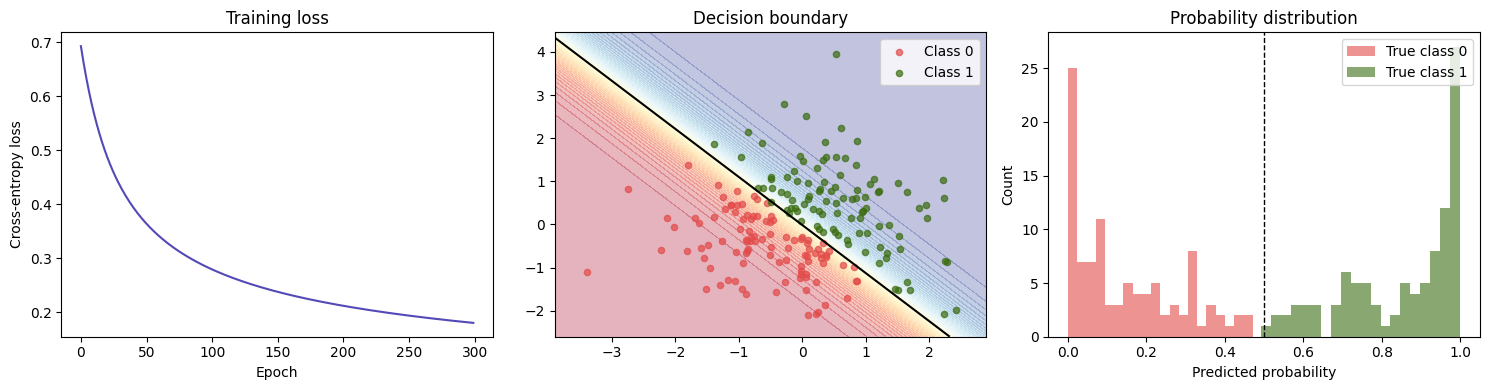

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Plot 1: Loss curve ──────────────────────────────────────────────────────
axes[0].plot(model.loss_history, color='#534AB7', linewidth=1.5)
# Cross-entropy loss per epoch. Should decrease and flatten.
# If it goes down fast then flatlines → model has converged.
# If it's noisy or goes up → learning rate too high.
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Training loss')

# ── Plot 2: Decision boundary ───────────────────────────────────────────────
h = 0.02
# Resolution of the grid. Smaller = smoother boundary but slower to compute.

x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
# Find the range of each feature so we can create a grid covering all the data.
# We add/subtract 0.5 for a small margin around the data.

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
# np.meshgrid creates a 2D grid of (x, y) coordinates.
# xx has the x-coordinates, yy has the y-coordinates, for every point on the grid.
# Think of it as a very dense scatter plot covering the whole space.

grid_points = np.c_[xx.ravel(), yy.ravel()]
# xx.ravel() flattens the 2D grid to a 1D array.
# np.c_ joins two 1D arrays as columns → shape (n_grid_points, 2).
# This is a large array of [feature1, feature2] pairs for every grid point.

Z = model.predict_proba(grid_points).reshape(xx.shape)
# Predict probability of class 1 for every grid point.
# .reshape(xx.shape) converts the flat 1D predictions back to 2D grid shape.

axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu', levels=50)
# contourf draws filled contours — it colours each region by probability.
# alpha=0.3 makes it semi-transparent so we can see the data points on top.
# cmap='RdYlBu' → red (class 1), yellow (boundary), blue (class 0).
# levels=50 → 50 colour bands → smooth gradient from 0 to 1.

axes[1].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5)
# contour draws the 0.5 probability line — the actual decision boundary.
# Where the model is exactly 50% confident.

class0 = X_scaled[y == 0]
class1 = X_scaled[y == 1]
# Split the data by true class label for plotting.

axes[1].scatter(class0[:, 0], class0[:, 1], c='#E24B4A', s=20, alpha=0.7, label='Class 0')
axes[1].scatter(class1[:, 0], class1[:, 1], c='#3B6D11', s=20, alpha=0.7, label='Class 1')
# Plot class 0 and class 1 data points in different colours.
# s=20 sets the marker size. alpha=0.7 makes overlapping points visible.

axes[1].set_title('Decision boundary')
axes[1].legend()

# ── Plot 3: Probability distribution ───────────────────────────────────────
all_probas = model.predict_proba(X_scaled)
# Get probabilities for all 200 samples.

axes[2].hist(all_probas[y == 0], bins=20, alpha=0.6, color='#E24B4A', label='True class 0')
# Histogram of predicted probabilities for true class 0 samples.
# We WANT these to cluster near 0 — model saying "pretty sure it's class 0".

axes[2].hist(all_probas[y == 1], bins=20, alpha=0.6, color='#3B6D11', label='True class 1')
# Histogram for true class 1. We WANT these to cluster near 1.

axes[2].axvline(x=0.5, color='black', linestyle='--', linewidth=1)
# Vertical line at 0.5 — the default decision threshold.

axes[2].set_xlabel('Predicted probability')
axes[2].set_ylabel('Count')
axes[2].set_title('Probability distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

Part 7 — Multi-class: how logistic regression extends beyond binary
So far: predict between 2 classes. What about 10 classes (like handwritten digits 0-9)?
The answer is Softmax, which is the generalisation of sigmoid to multiple classes.
$$ softmax(zₖ) =  e^zₖ / Σⱼ e^zʲ $$
You compute one raw score zₖ per class k. Softmax converts these into probabilities that all sum to 1. The denominator Σⱼ e^zʲ is the sum of e^z for every class — it normalises everything.

In [ ]:
def softmax(z: np.ndarray) -> np.ndarray:
    # z has shape (n_samples, n_classes).
    # Each row is the raw scores for one sample across all classes.

    z_shifted = z - z.max(axis=1, keepdims=True)
    # CRITICAL: subtract the max score from each row before exponentiating.
    # This is numerical stability. e^700 overflows to infinity in float32.
    # Subtracting the max makes all values <= 0, so e^z <= 1.
    # Mathematically equivalent (the max cancels in numerator and denominator).
    # axis=1 means max across columns (across classes) for each row.
    # keepdims=True keeps shape (n_samples, 1) so subtraction broadcasts correctly.

    exp_z = np.exp(z_shifted)
    # e^(z - max) for every element. All values now ≤ 1. No overflow.

    return exp_z / exp_z.sum(axis=1, keepdims=True)
    # Divide each e^z by the sum of e^z for that sample.
    # axis=1 sums across classes for each sample.
    # Result: (n_samples, n_classes) where each row sums to 1.

    """
    The loss for multi-class is categorical cross-entropy — same idea, generalised:
L = -(1/n) Σᵢ Σₖ yᵢₖ × log(ŷᵢₖ)
For each sample i and each class k, multiply the true label (1 if correct class, 0 otherwise) by the log of the predicted probability. This is implemented in sklearn as multi_class='multinomial'.

    """

# Part 8 — sklearn version (production code)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# ── Build pipeline ──────────────────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # Standardise features. Logistic regression needs this — gradient
    # descent converges slowly and unevenly without it.

    ('model', LogisticRegression(
        C=1.0,
        # C is the INVERSE of regularisation strength (we cover regularisation
        # deeply in Module 3). Smaller C = more regularisation = simpler model.
        # Default C=1.0 is a reasonable starting point.

        max_iter=1000,
        # Maximum gradient descent iterations. sklearn will warn you if
        # it hasn't converged — increase this if you see that warning.

        solver='lbfgs',
        # The optimisation algorithm. 'lbfgs' is a second-order method
        # (uses curvature information, not just gradient) — faster than
        # plain gradient descent for logistic regression.
        # For very large datasets, use 'saga' (supports L1 penalty too).

        random_state=42
        # For reproducibility — some solvers have random elements.
    ))
])

# ── Train ───────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
pipeline.fit(X_train, y_train)

# ── Evaluate ─────────────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
# predict_proba returns shape (n_samples, 2) — one column per class.
# [:, 1] takes column 1 = probability of class 1.

print(classification_report(y_test, y_pred))
# classification_report prints precision, recall, F1 for each class.
# These metrics are covered in depth in Module 10.
# For now: high precision = few false positives. High recall = few false negatives.

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
# 2×2 matrix:
# [[TN  FP]
#  [FN  TP]]
# TN = true negatives (correctly said class 0)
# FP = false positives (said class 1, was class 0) — Type I error
# FN = false negatives (said class 0, was class 1) — Type II error
# TP = true positives (correctly said class 1)

# ── Cross-validation ─────────────────────────────────────────────────────────
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
# Instead of one train/test split, do 5 different splits.
# Each time 4/5 of data = train, 1/5 = test. Rotate through all 5 splits.
# cv_scores is an array of 5 accuracy values — one per fold.
# This gives a much more reliable estimate of true model performance.

print(f"CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
# Mean = average performance. Std = how consistent (lower is better).
# A model with mean=0.92 and std=0.01 is reliable.
# A model with mean=0.92 and std=0.15 is unreliable — lucky on some splits.

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        21
         1.0       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion matrix:
[[21  0]
 [ 0 19]]
CV accuracy: 0.9950 ± 0.0100


# 🎯 Part 9 — Odds and Log-Odds (Interview Essential)

---

## What are Odds?

$$\text{odds} = \frac{p}{1 - p}$$

| Probability | Odds | Meaning |
|-------------|------|---------|
| p = 0.50 | 1 | Equally likely either way |
| p = 0.75 | 3 | **3× more likely** to happen than not |
| p = 0.90 | 9 | 9× more likely to happen |

> 💡 Odds = "how many times more likely is YES vs NO"

---

## What are Log-Odds?

Just take the **log of the odds**:

$$\log\left(\frac{p}{1-p}\right)$$

This is also called the **logit function** — and this is literally where the name **"logistic"** regression comes from.

---

## The Key Insight 🔑

Logistic regression models **log-odds as a linear function of features**:

$$\boxed{\log\left(\frac{p}{1-p}\right) = w_0 + w_1 x_1 + w_2 x_2 + \cdots}$$

> So the model is actually **linear under the hood** — just in log-odds space, not probability space.

---

## Why This Matters — Interpreting Weights

Each weight $w_i$ tells you:

> **"How much do the log-odds change when feature $x_i$ increases by 1?"**

But log-odds are hard to think about. So **exponentiate** to get the **odds ratio**:

$$e^{w_i} = \text{odds ratio for feature } x_i$$

| $w_i$ | $e^{w_i}$ | Meaning |
|--------|-----------|---------|
| 0 | 1.0 | Feature has **no effect** |
| 0.5 | 1.65 | Odds go up **65%** |
| 1.3 | ≈ 3.7 | Odds **3.7× higher** |
| −0.8 | 0.45 | Odds go **down 55%** |

**Real example:**
> *"Customers who see Promotion X are $e^{1.3} \approx 3.7\times$ more likely to purchase."*

That's a sentence you can say to a business stakeholder. **This is why logistic regression is used everywhere** — medicine, finance, statistics — not just ML.

---

## Quick Summary

| Term | Formula | What it means |
|------|---------|---------------|
| **Odds** | $p / (1-p)$ | How likely YES vs NO |
| **Log-odds (logit)** | $\log(p / (1-p))$ | What the model actually predicts linearly |
| **Odds Ratio** | $e^{w_i}$ | Multiplicative effect of feature $x_i$ on odds |

In [ ]:
# Get odds ratios from a trained model
model = pipeline.named_steps['model']
# Access the logistic regression step from the pipeline.

odds_ratios = np.exp(model.coef_[0])
# model.coef_ is shape (1, n_features) — the weights.
# [0] takes the first (only) row.
# np.exp converts log-odds weights to odds ratios.

for i, (feature, ratio) in enumerate(zip(['feature_1', 'feature_2'], odds_ratios)):
    print(f"{feature}: odds ratio = {ratio:.3f}")
# Odds ratio > 1 → feature increases probability of class 1.
# Odds ratio < 1 → feature decreases probability of class 1.
# Odds ratio = 1 → feature has no effect.

feature_1: odds ratio = 31.041
feature_2: odds ratio = 20.358


# Part 10 — Common Mistakes to Avoid

---

### Mistake 1 — Not Scaling Features

Like linear regression, gradient descent in logistic regression is **scale-sensitive**.

Always scale your features before training.

---

### Mistake 2 — Using Accuracy on Imbalanced Data

If 95% of emails are not spam, a model that **always predicts "not spam"** gets 95% accuracy — and is completely useless.

For imbalanced problems, use: **F1, Precision-Recall, or ROC-AUC** instead.

---

### Mistake 3 — Ignoring the `max_iter` Warning

When sklearn warns that the solver didn't converge, it means **the weights are not optimal yet**.

Fix: increase `max_iter`, or scale your features (which also helps convergence).

---

### Mistake 4 — Trusting `predict_proba` as Perfectly Calibrated

A model outputting $\hat{y} = 0.8$ does **not** necessarily mean "80% real-world probability."

When probabilities matter, use:
```python
from sklearn.calibration import CalibratedClassifierCV
```

---

### Mistake 5 — Using Sigmoid for Multi-Class

Sigmoid is **binary only** (one output between 0 and 1).

For 3+ classes, use **softmax** — or just let sklearn handle it:
```python
LogisticRegression(multi_class='multinomial')
```

---
---

# Part 11 — Interview Questions, Answered Deeply

---

### Q: What's the difference between logistic regression and a neural network?

Logistic regression **is** a neural network — with **zero hidden layers**.

- One input layer → directly to one output node → sigmoid activation
- A neural network adds **hidden layers** between input and output, learning non-linear combinations

> Logistic regression can only learn **linear decision boundaries**. Neural nets can learn curved ones.

---

### Q: Can logistic regression output poorly calibrated probabilities?

**Yes.**

It tends to be well-calibrated on simple problems, but can be **overconfident** when:
- Features are collinear
- Regularisation is too strong

Check calibration with:
```python
from sklearn.calibration import calibration_curve
```

---

### Q: Why use logistic regression when XGBoost and neural nets exist?

Three reasons:

| Reason | Why it matters |
|--------|---------------|
| **Interpretable** | Every prediction explainable via weights and odds ratios |
| **Fast** | Quick to train and serve at scale |
| **Regulation** | In fraud, credit scoring, and medicine — interpretability is often legally required |

> In many industries, logistic regression isn't just preferred — it's **mandated**.

---

### Q: What is the decision boundary geometrically?

A **hyperplane** — always flat, never curved.

- 2D → a straight line
- 3D → a flat plane
- $n$D → a hyperplane

**Why?** The boundary is where $\hat{y} = 0.5$, which means $\sigma(z) = 0.5$, which means $z = 0$:

$$w \cdot x + b = 0$$

That is the equation of a hyperplane. Logistic regression **literally cannot learn a curved boundary** without feature engineering — adding $x^2$, $x_1 \times x_2$, etc.

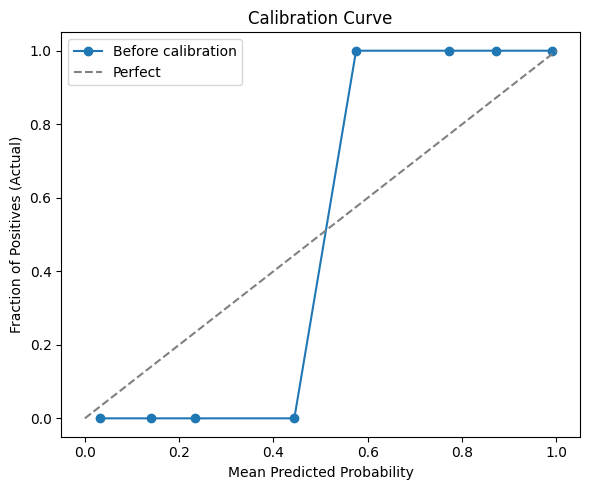

Brier score (before): 0.0247


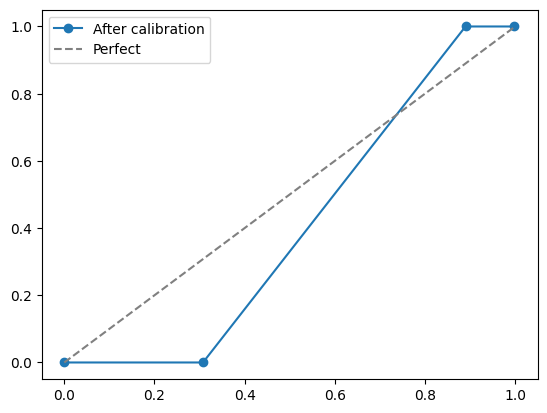

Brier score (after):  0.0027
Improvement:          0.0219


In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# ── Step 1: Get probabilities from your existing pipeline ─────────────────────
# y_proba = pipeline.predict_proba(X_test)[:, 1]

# ── Step 2: Plot calibration curve ───────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
# Each bucket: compare mean predicted prob vs actual fraction of positives

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
# Each point = one bin. Should hug the diagonal if well calibrated.
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual)")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 3: Brier score — puts a number on it ─────────────────────────────────
brier_before = brier_score_loss(y_test, y_proba)
# Mean squared error between predicted probability and true label (0 or 1)
# Lower is better. 0.0 = perfect. 0.25 = as bad as always predicting 0.5.
print(f"Brier score (before): {brier_before:.4f}")

# ── Step 4: Fix calibration if needed ────────────────────────────────────────
calibrated = CalibratedClassifierCV(
    pipeline,
    method='isotonic',   # 'isotonic' for more data, 'sigmoid' for less data
    cv=5
)
calibrated.fit(X_train, y_train)
y_proba_cal = calibrated.predict_proba(X_test)[:, 1]


prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='After calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
plt.legend()
plt.show()
# ── Step 5: Check again ───────────────────────────────────────────────────────
brier_after = brier_score_loss(y_test, y_proba_cal)
print(f"Brier score (after):  {brier_after:.4f}")
print(f"Improvement:          {brier_before - brier_after:.4f}")
# Positive = calibration helped. Zero or negative = original was already fi

# Part 11 (Extended) — Checking Probability Calibration

Using the pipeline we already built, we can check whether `predict_proba` is actually trustworthy.

---

## What does "calibrated" mean?

If the model outputs $\hat{y} = 0.8$ for 100 samples, roughly **80 of them should actually be class 1**.

A **calibration curve** checks exactly this — it plots:
- **X-axis** → the probability the model predicted
- **Y-axis** → the actual fraction of positives in that bucket

A perfectly calibrated model follows the diagonal. Deviations tell you which direction the model is overconfident or underconfident.

---

## Full Code — Check, Score, Fix, Confirm

```python
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# ── Step 1: Get probabilities from your existing pipeline ─────────────────────
# y_proba = pipeline.predict_proba(X_test)[:, 1]

# ── Step 2: Plot calibration curve ───────────────────────────────────────────
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
# Each bucket: compare mean predicted prob vs actual fraction of positives

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label='Before calibration')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect')
# Each point = one bin. Should hug the diagonal if well calibrated.
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual)")
plt.title("Calibration Curve")
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 3: Brier score — puts a number on it ─────────────────────────────────
brier_before = brier_score_loss(y_test, y_proba)
# Mean squared error between predicted probability and true label (0 or 1)
# Lower is better. 0.0 = perfect. 0.25 = as bad as always predicting 0.5.
print(f"Brier score (before): {brier_before:.4f}")

# ── Step 4: Fix calibration if needed ────────────────────────────────────────
calibrated = CalibratedClassifierCV(
    pipeline,
    method='isotonic',   # 'isotonic' for more data, 'sigmoid' for less data
    cv=5
)
calibrated.fit(X_train, y_train)
y_proba_cal = calibrated.predict_proba(X_test)[:, 1]

# ── Step 5: Check again ───────────────────────────────────────────────────────
brier_after = brier_score_loss(y_test, y_proba_cal)
print(f"Brier score (after):  {brier_after:.4f}")
print(f"Improvement:          {brier_before - brier_after:.4f}")
# Positive = calibration helped. Zero or negative = original was already fine.
```

---

## How to Read the Calibration Curve

| Curve position | What it means |
|----------------|---------------|
| On the diagonal | Well calibrated — probabilities are trustworthy |
| Below the diagonal | Overconfident — predicts 0.8 but only 60% are actually class 1 |
| Above the diagonal | Underconfident — predicts 0.4 but 65% are actually class 1 |

---

## How to Read the Brier Score

| Score | Verdict |
|-------|---------|
| < 0.10 | Good |
| 0.10 – 0.20 | Acceptable |
| > 0.20 | Poor — calibrate |

If `brier_after` is lower → calibration helped, keep `calibrated`.
If it's the same or higher → original probabilities were already fine, skip it.

---

> **When does this actually matter?** If you only care about the predicted label (0 or 1), calibration is irrelevant. It matters when the probability value itself drives a decision — ranking customers by purchase likelihood, setting risk thresholds in medicine, fraud scoring.



---



# Module 3 — Regularization
### Why models overfit, what L1 and L2 actually do

---

## Part 1 — What is Overfitting, Really?

**The exam analogy:**

You memorize last year's exam questions word for word. If the questions are identical → 100%. If they're slightly different → you fail. That's overfitting — memorizing the training data instead of learning the pattern.

**In numbers:** fit a degree-9 polynomial to 10 data points. It passes through every point perfectly. Training error = 0. Show it a new point → garbage prediction. The wiggles were fitting the **noise**, not the true relationship.

---

### The Core Tension in ML

| Model | Bias | Variance | Problem |
|-------|------|----------|---------|
| Too simple | High | Low | Underfits — misses the pattern |
| Too complex | Low | High | Overfits — memorizes the noise |

**Regularization** adds a cost for large weights → forces the model to stay simple unless the data strongly demands complexity.

---

## Part 2 — Where Regularization Comes From

Plain loss from Module 1:

$$\text{Loss} = \text{MSE} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2$$

Regularization adds a **penalty term**:

$$\boxed{\text{Regularized Loss} = \text{MSE} + \lambda \times \text{Penalty}(w)}$$

**$\lambda$ (lambda)** = regularization strength. The most important hyperparameter you'll tune.

| $\lambda$ value | Effect |
|-----------------|--------|
| $\lambda = 0$ | No regularization — model can overfit freely |
| $\lambda \to \infty$ | Penalty dominates — all weights forced to zero, severe underfitting |

**Two choices of Penalty(w) → two different algorithms:**

| Penalty | Formula | Algorithm |
|---------|---------|-----------|
| **L2** | $\sum w_i^2$ | Ridge Regression |
| **L1** | $\sum \|w_i\|$ | Lasso Regression |

They look similar but behave completely differently.

---

## Part 3 — L2 Regularization (Ridge)

### The Loss Function

$$\text{Ridge Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \lambda \sum w_i^2$$

Squaring amplifies large weights — so the model is pushed to **spread its weight budget evenly** across features rather than concentrating on a few.

---

### What it Does to the Gradient

Plain MSE gradient (from Module 1):

$$\frac{\partial \text{MSE}}{\partial w} = \frac{2}{n} X^\top (\hat{y} - y)$$

Ridge adds an extra term:

$$\frac{\partial \text{Ridge Loss}}{\partial w} = \frac{2}{n} X^\top (\hat{y} - y) + 2\lambda w$$

The $2\lambda w$ term pulls weights back toward zero at every step — proportional to their current size. This is called **weight decay**.

The update rule becomes:

$$w := w - \alpha \left[\frac{2}{n} X^\top(\hat{y} - y) + 2\lambda w\right]$$

$$= w\underbrace{(1 - 2\alpha\lambda)}_{\text{decay factor}} - \alpha \cdot \frac{2}{n} X^\top(\hat{y} - y)$$

> The $(1 - 2\alpha\lambda)$ factor means every step, the weight is multiplied by a number slightly less than 1 — it **decays**.
> The data gradient can fight this decay — but only if the feature genuinely matters.
> If a feature is noise → its gradient averages near zero → decay wins → weight shrinks toward zero.
> **But never exactly zero.**

---

### The Closed-Form Solution

$$w^* = (X^\top X + \lambda I)^{-1} X^\top y$$

$I$ = identity matrix. Adding $\lambda I$ before inverting does two things:

1. **Always invertible** — even when features are collinear ($X^\top X$ alone can be singular)
2. **Pushes eigenvalues away from zero** — numerically stable

> Ridge's second superpower: it **fixes multicollinearity**.

---

### The Geometric Picture

Think of it as two things competing:
- **MSE loss** = a bowl shape, pulling toward the best unconstrained fit
- **L2 constraint** = a **circle** centred at the origin

You're looking for the point inside the circle closest to the bottom of the bowl.

Because the circle has **curved edges with no corners**, the solution lands somewhere on the circle's boundary — almost never exactly on an axis.

**Result: weights are small, but rarely exactly zero.**

In [ ]:
from IPython.display import HTML

# Read the content of the HTML file
with open('/content/regularization_geometry.html', 'r') as f:
    html_content = f.read()

# Display the HTML content
HTML(html_content)

# Part 4 — L1 Regularization (Lasso)
### Why it creates sparsity

---

## The Loss Function

$$\text{Lasso Loss} = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 + \lambda \sum |w_i|$$

---

## The Gradient of $|w|$

$$\frac{d|w|}{dw} = \begin{cases} +1 & \text{if } w > 0 \\ -1 & \text{if } w < 0 \\ \text{undefined} & \text{if } w = 0 \quad \text{(subgradient: any value in } [-1, +1]\text{)} \end{cases}$$

---

## Why L1 Pushes Weights to Exactly Zero (but L2 Doesn't)

| | L2 (Ridge) | L1 (Lasso) |
|---|---|---|
| Penalty gradient | $2w$ — **shrinks as $w \to 0$** | $\pm\lambda$ — **constant always** |
| Pull toward zero | Gets weaker as weight gets smaller | Same strength no matter how small |
| Result | Weight asymptotically approaches zero, **never reaches it** | Weight gets pushed all the way to **exactly zero** |

> With L1, when a weight is small and the data gradient can't overcome the constant pull of $\pm\lambda$, the weight hits zero and **stays there**. That's sparsity.

---

## Why Corners Produce Zeros — Geometry

- **MSE bowl** minimum sits somewhere off the axes at $(w_1^*, w_2^*)$
- **Lasso constraint** = a **diamond** shape
- **Ridge constraint** = a **circle** shape

The solution = closest point on the shape to the bowl's minimum.

| Shape | Corners? | Result |
|-------|----------|--------|
| Diamond (L1) | Yes — corners sit on axes | Solution lands on a corner → one weight = **exactly 0** |
| Circle (L2) | No | Solution almost never lands on an axis → weights stay **non-zero** |

> A corner like $(r, 0)$ means $w_2 = 0$ exactly. **Geometry directly produces sparsity.**

---

## Why Sparsity Matters in Production

Say you have 1000 features — age, 500 product flags, 400 behavioural signals.

Lasso can automatically say: **"only these 23 features matter, the rest are zero."**

| Benefit | Why it helps |
|---------|-------------|
| Faster serving | Model only needs 23 features at prediction time |
| Automatic feature selection | You know which features actually matter |
| Interpretability | Stakeholders understand 23 features, not 1000 |

**Real-world use:**
- **Genomics** — millions of gene features, only a handful of genes actually matter
- **Finance** — thousands of signals, only a few are real

---

---

# Part 5 — ElasticNet: Getting Both Worlds

$$\text{ElasticNet Loss} = \text{MSE} + \lambda \left[\rho \sum|w_i| + (1-\rho) \sum w_i^2\right]$$

$\rho$ = mixing ratio (`l1_ratio` in sklearn)

| $\rho$ value | Equivalent to |
|--------------|--------------|
| $\rho = 1$ | Pure Lasso |
| $\rho = 0$ | Pure Ridge |
| $\rho = 0.5$ | Equal mix |

---

## When to Use ElasticNet

**Problem with Lasso on correlated features:**

If features are correlated (e.g. groups of genes that move together), Lasso **arbitrarily picks one and zeros the rest** — which is unstable. Different training runs may pick different features.

**ElasticNet's fix:** the L2 component keeps correlated features together and shrinks them as a group instead of eliminating all but one.

> Use ElasticNet when you have **many correlated features** and want sparsity without the instability of pure Lasso.

---

## Quick Cheat Sheet — Which to Use?

| Situation | Use |
|-----------|-----|
| Features are mostly independent, want to shrink all | **Ridge** |
| Many irrelevant features, want automatic selection | **Lasso** |
| Many correlated features, want stable sparsity | **ElasticNet** |
| Collinear features breaking your model | **Ridge** (fixes multicollinearity) |

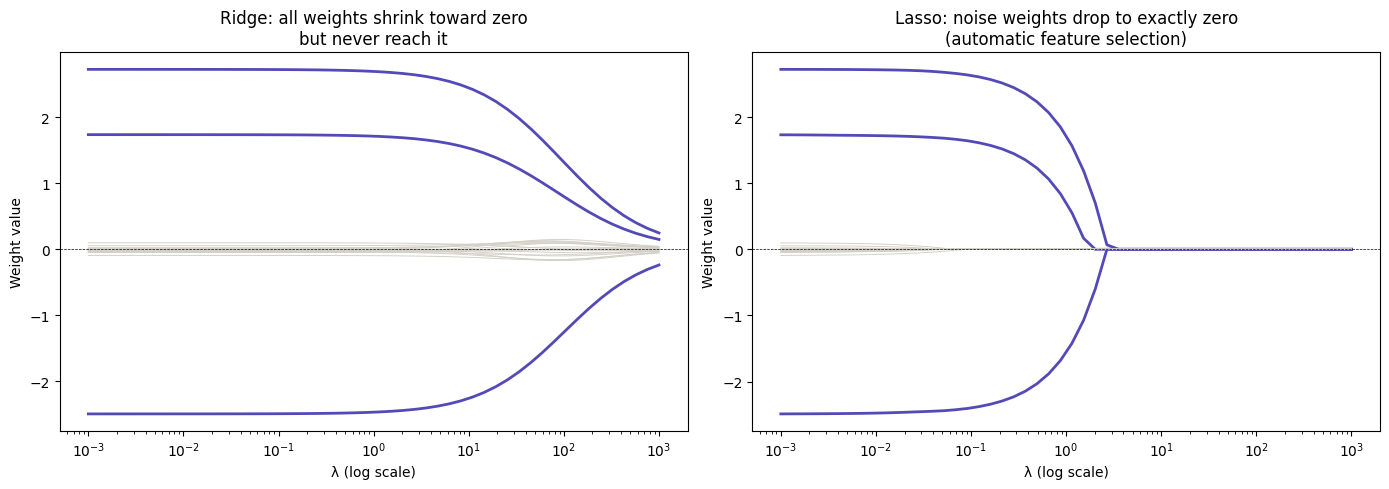

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# ── Create data with only 3 truly useful features out of 20 ──────────────
n_samples  = 100
n_features = 20
# We have 20 features total.

X = np.random.randn(n_samples, n_features)
# 100 samples, 20 features, all from standard normal distribution.

true_weights = np.zeros(n_features)
# Start with all weights at zero.

true_weights[[0, 3, 7]] = [3.0, -2.5, 1.8]
# Only features 0, 3, and 7 actually matter.
# Their true weights are 3.0, -2.5, and 1.8.
# The other 17 features are pure noise — they should have weight ≈ 0.

y = X @ true_weights + 0.5 * np.random.randn(n_samples)
# Generate targets using only the 3 real features.
# Add small Gaussian noise (std=0.5) to simulate real data messiness.

# ── Scale features ────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Regularization is sensitive to feature scale — always scale first.
# Without scaling, features with larger values get unfairly penalized more.

# ── Fit Ridge at various lambda values ────────────────────────────────────
lambdas = np.logspace(-3, 3, 50)
# np.logspace(-3, 3, 50) creates 50 values evenly spaced on a LOG scale
# from 10^-3 = 0.001 to 10^3 = 1000.
# We use log scale because the effect of lambda is multiplicative, not additive.
# The difference between λ=0.001 and λ=0.01 is as important as 1 and 10.

ridge_coefs = []
# Will store the weight array for each lambda.

for lam in lambdas:
    model = Ridge(alpha=lam)
    # sklearn calls lambda 'alpha'. Same thing.
    model.fit(X_scaled, y)
    ridge_coefs.append(model.coef_.copy())
    # .copy() is important — without it, all entries in the list
    # would point to the same array (Python's mutability trap).

ridge_coefs = np.array(ridge_coefs)
# Shape: (50 lambdas, 20 features). Each row is the weight vector for one lambda.

# ── Fit Lasso at various lambda values ────────────────────────────────────
lasso_coefs = []

for lam in lambdas:
    model = Lasso(alpha=lam, max_iter=10000)
    # max_iter=10000 because Lasso sometimes needs more iterations to converge,
    # especially for small lambda where many weights are non-zero.
    model.fit(X_scaled, y)
    lasso_coefs.append(model.coef_.copy())

lasso_coefs = np.array(lasso_coefs)
# Same shape: (50 lambdas, 20 features).

# ── Plot: regularization paths ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(n_features):
    color = '#534AB7' if i in [0, 3, 7] else '#D3D1C7'
    # Purple for real features, gray for noise features.
    width = 2.0 if i in [0, 3, 7] else 0.7
    # Thicker lines for real features so they stand out.

    axes[0].plot(lambdas, ridge_coefs[:, i], color=color, linewidth=width)
    # For each feature, plot how its Ridge weight changes as lambda increases.
    # lambdas on x-axis (we'll set log scale below).
    # ridge_coefs[:, i] = column i = that feature's weight across all 50 lambdas.

    axes[1].plot(lambdas, lasso_coefs[:, i], color=color, linewidth=width)
    # Same for Lasso.

axes[0].set_xscale('log')
# Log scale on x-axis so we can see both λ=0.001 and λ=1000 clearly.

axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
# Horizontal line at weight=0 for reference.

axes[0].set_xlabel('λ (log scale)')
axes[0].set_ylabel('Weight value')
axes[0].set_title('Ridge: all weights shrink toward zero\nbut never reach it')

axes[1].set_xscale('log')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_xlabel('λ (log scale)')
axes[1].set_ylabel('Weight value')
axes[1].set_title('Lasso: noise weights drop to exactly zero\n(automatic feature selection)')

plt.tight_layout()
plt.show()
# What you will see:
# Ridge: all 20 lines gradually approach zero as lambda grows. None reach zero.
# Lasso: the 17 noise features (gray) collapse to zero quite quickly.
#         The 3 real features (purple) hold on longer, then eventually zero too.
#         At medium lambda: you get a sparse model with only the 3 real features.

In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ── RidgeCV: tries all lambdas, picks best via cross-validation ───────────
ridge_cv = RidgeCV(
    alphas=lambdas,
    # The lambdas to try. RidgeCV internally does cross-validation
    # for each one and picks the lambda with the lowest validation loss.

    cv=5,
    # 5-fold cross-validation.
    # Splits training data into 5 equal parts.
    # For each lambda: trains on 4 parts, validates on the 5th.
    # Rotates which part is validation — all data gets validated on.
    # Picks the lambda whose average validation loss is lowest.

    scoring='neg_mean_squared_error'
    # sklearn convention: scoring metrics are negated (higher = better).
    # neg_mean_squared_error: -MSE. Maximizing -MSE = minimizing MSE.
)
ridge_cv.fit(X_train, y_train)

print(f"Best Ridge lambda: {ridge_cv.alpha_:.4f}")
# ridge_cv.alpha_ stores the lambda that cross-validation selected.

# ── LassoCV: same idea ────────────────────────────────────────────────────
lasso_cv = LassoCV(
    alphas=lambdas,
    cv=5,
    max_iter=10000,
    random_state=42
)
lasso_cv.fit(X_train, y_train)

print(f"Best Lasso lambda: {lasso_cv.alpha_:.4f}")

n_nonzero = (lasso_cv.coef_ != 0).sum()
print(f"Lasso kept {n_nonzero} features out of {n_features}")
# With a good lambda, this should print 3 — exactly the true useful features.
# That is Lasso doing automatic feature selection correctly.

# ── Final evaluation ──────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score

for name, model in [('Ridge', ridge_cv), ('Lasso', lasso_cv)]:
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2  = r2_score(y_test, y_pred)
    print(f"{name}: MSE={mse:.4f}, R²={r2:.4f}")

Best Ridge lambda: 0.2812
Best Lasso lambda: 0.0687
Lasso kept 4 features out of 20
Ridge: MSE=0.3338, R²=0.9829
Lasso: MSE=0.3133, R²=0.9840


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV

# ── Ridge pipeline with hyperparameter search ─────────────────────────────
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # Always scale INSIDE the pipeline — this prevents data leakage.
    # If you scale before the pipeline, the test set statistics contaminate training.

    ('model', Ridge())
    # Ridge with default alpha=1.0 — we'll tune it in GridSearchCV below.
])

param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
    # 'model__alpha' means: the 'alpha' parameter of the 'model' step.
    # The double underscore __ is sklearn's way of accessing nested parameters.
    # GridSearchCV will try all 6 values and pick the best via cross-validation.
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    # 5-fold cross-validation.
    scoring='neg_mean_squared_error',
    n_jobs=-1
    # n_jobs=-1 means use ALL available CPU cores in parallel.
    # Fitting 5 folds × 6 lambdas = 30 models — parallelism speeds this up.
)
grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
# Prints something like: {'model__alpha': 0.1}

best_model = grid_search.best_estimator_
# The full pipeline (scaler + Ridge) with the best lambda already set.
# Use this for final predictions on X_test.

y_pred = best_model.predict(X_test)

Best params: {'model__alpha': 0.1}


## Part 11 — Interview questions answered deeply

**Q: Why does L1 produce sparse solutions but L2 does not?**
The gradient of L2 penalty at w is 2λw — it shrinks toward zero as w shrinks. So the pulling force disappears as the weight gets close to zero, and the weight asymptotically approaches zero but never reaches it. The gradient of L1 is λ × sign(w) — constant magnitude regardless of weight size. The pull is as strong when w = 0.001 as when w = 10. If the data gradient can't overpower the constant pull (which happens for noise features), the weight goes to exactly zero and stays there.

**Q: In sklearn, alpha and lambda are the same thing — why the different name?**
Pure convention. The math literature uses λ. sklearn chose alpha to match the notation in some statistics textbooks. Same concept — the regularization strength hyperparameter.

**Q: What happens when lambda is too large?**
All weights are pushed toward zero. The model predicts close to the mean of y for every input — it has essentially learned nothing about the features. This is severe underfitting. Your training and test error will both be high.

**Q: Does regularization help with a small dataset?**
Yes — this is one of its most important use cases. With limited data, gradient descent has only a few examples to learn from and easily overfits. Regularization acts as a prior: "weights should be small unless the data overwhelmingly says otherwise." It injects bias in exchange for reduced variance, which is exactly the right trade when data is scarce.

**Q: Should you regularize the bias term?**
No. The bias term is just the intercept — it shifts all predictions up or down. Regularizing it would bias predictions toward zero regardless of the true mean of y. sklearn's Ridge/Lasso both skip bias regularization by default (fit_intercept=True keeps the intercept unpenalized).



---



# Module 4 — Gradient Descent (Deep)
### Batch vs SGD vs Mini-batch · Momentum · Adam · Learning Rate Schedules

---

## Part 1 — What Gradient Descent Actually Is

In modules 1–3, gradient descent was a black box: *compute gradient → subtract → repeat.*

The real version matters because in production, the difference between a model that trains in **2 hours vs 20 hours**, or **converges vs diverges**, comes entirely from which variant you use and how you configure it.

**The core idea — always the same:**

> You're standing on a hilly landscape (the loss surface). You want the lowest point. The gradient tells you the direction of steepest **uphill**. You step **downhill**.

The question is: **which data do you use to compute the gradient at each step?**

---

## Part 2 — The Three Variants

### Batch Gradient Descent

Use **all** $n$ training samples to compute one gradient update:

```
gradient = average of gradients over all n samples
w := w - α × gradient
```

- **1 update per epoch** (one full pass through all data)
- Very accurate gradient — it's the true gradient of your loss
- **Problem 1:** Extremely slow when $n$ is in the millions — you process everything before taking one step
- **Problem 2:** Loads the entire dataset into memory at once

---

### Stochastic Gradient Descent (SGD)

Use **one** randomly chosen sample per update:

```
for each sample i (randomly shuffled):
    gradient = gradient on sample i alone
    w := w - α × gradient
```

- **$n$ updates per epoch** — one per sample
- Very fast — weights update after every single example
- **Problem:** One sample's gradient is very noisy — rough approximation of the true gradient
- Loss curve is jagged and never converges smoothly
- The noise can actually **help escape local minima** (this is not always bad)

---

### Mini-batch Gradient Descent ← what everyone actually uses

Use a small batch of $B$ samples (typically **32–256**):

```
for each batch of B samples:
    gradient = average gradient over the B samples
    w := w - α × gradient
```

**Best of both worlds:**

| Property | Why it helps |
|----------|-------------|
| More stable than single-sample SGD | Averaging over $B$ reduces noise by $\sqrt{B}$ |
| Much faster than full batch GD | Update after every 32 samples, not 1 million |
| Fits in GPU memory | A batch of 32 images fits easily; 1 million don't |
| Mild noise from batch sampling | Helps escape sharp local minima |

---

## Part 3 — The Problem With Plain Gradient Descent

Plain GD treats every parameter the same — step size is just $\alpha \times \text{gradient}$. It has **no memory**. It doesn't know if it's been oscillating. It doesn't know whether the gradient in one direction is reliable or noisy.

Three real problems this causes:

**1. Oscillation**

If the loss surface is much steeper in one direction than another (like a narrow canyon), GD **zigzags** across the narrow dimension instead of going straight down. Gradients in the narrow direction keep flipping sign — up, down, up, down — instead of making progress.

**2. Saddle Points**

The gradient is zero at saddle points (flat in some directions, curved in others). Plain GD gets stuck here — no momentum to push through.

**3. Sparse Gradients**

In NLP, most words appear rarely. Most gradients are zero most of the time. Plain GD makes tiny updates for rare words even when those updates should be large.

> Each optimizer below was invented to solve one or more of these problems.

---

## Part 4 — Momentum: Giving GD a Memory

### The Intuition

A ball rolling downhill **accelerates** in flat regions as momentum builds. It doesn't start from rest at each step.

Momentum works the same way — instead of the raw gradient, we keep a **running average of past gradients** called the **velocity vector** and step in that direction.

### The Math

$$v := \beta \cdot v + (1 - \beta) \cdot \nabla w$$

$$w := w - \alpha \cdot v$$

$\beta$ (beta) = momentum coefficient, typically **0.9**

> With $\beta = 0.9$: velocity is 90% old velocity + 10% new gradient — a weighted average of many recent gradients.

**What this does:**

| Situation | Effect |
|-----------|--------|
| Gradient consistently points same direction | Velocity **builds up** → bigger steps (accelerates down smooth valleys) |
| Gradient keeps flipping sign (oscillating) | Successive gradients **cancel** → velocity stays small → smaller steps automatically |

This is called an **Exponentially Weighted Moving Average (EWMA)** — older gradients matter less because they get multiplied by $\beta$ one more time with every passing step.

---


## A Note on Learning From Scratch vs Production Code

**Scratch implementations are valuable once — not repeatedly.**

Writing gradient descent from scratch teaches you what the optimizer is actually doing. Once you've done it once and understood it, continuing to rewrite it is not learning — it's busywork.

**From here on: use production code.** `torch.optim.Adam`, `sklearn` pipelines, `CosineAnnealingLR` — these are battle-tested, numerically stable implementations used in real research and production systems.

The depth you need is:
- **Understand what each line of the optimizer does** (which this module covers)
- **Know when to use which optimizer and why**
- **Know how to configure hyperparameters and debug convergence**

You do **not** need to reimplement Adam from scratch every time you want to train a model. Use the library. Spend the saved time going deeper on *why* things work.

> Scratch = for understanding. Production code = for everything after.

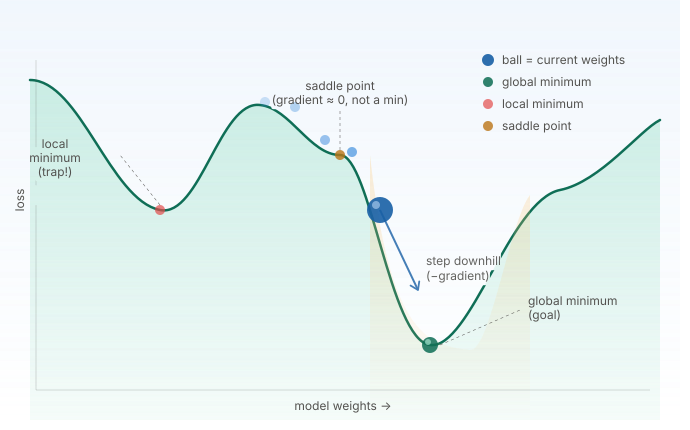

In [ ]:
from IPython.display import SVG

# Read the content of the SVG file
with open('/content/gradient_descent_loss_landscape.svg', 'r') as f:
    svg_content = f.read()

# Display the SVG content
SVG(svg_content)

# Module 4 (continued) — AdaGrad, RMSProp, Adam, and More

---

## Part 5 — AdaGrad: Different Learning Rate for Each Parameter

### The Problem It Solves

Imagine training a model on text. The word **"the"** appears in every sentence. The word **"ephemeral"** appears maybe 3 times in the whole dataset.

Plain SGD gives both words the **same learning rate**. That's wrong. When "ephemeral" finally gets a gradient, that update should be **big** — the model barely saw it. When "the" updates, it should be **small** — the model already knows it well.

AdaGrad fixes this by keeping a **separate, shrinking learning rate per parameter**.

---

### The Math

$$G := G + (\nabla w)^2$$

$$w := w - \frac{\alpha}{\sqrt{G + \epsilon}} \times \nabla w$$

In plain words:

- **$G$** (capital G) = running total of all squared gradients so far, for each parameter separately
- **$\nabla w$** (del w) = the gradient (how much to nudge this weight)
- **$\alpha$** (alpha) = base learning rate
- **$\epsilon$** (epsilon) = tiny number like `0.00000001` — just so we never divide by zero

**What's actually happening:**

| Parameter | G is... | Effective step size |
|-----------|---------|---------------------|
| Updated a lot with big gradients | Large | **Small** — divide by big number |
| Updated rarely or with tiny gradients | Small | **Large** — divide by small number |

Rare parameters get bigger updates when they finally appear. Frequent parameters get smaller updates so they don't overreact.

---

### The Fatal Problem

$G$ **only ever grows** — we keep adding squares, never removing them.

After enough steps, $G$ becomes so large that $\frac{\alpha}{\sqrt{G}}$ (your effective learning rate) becomes nearly **zero** for every parameter. Training just stops. The model freezes.

> AdaGrad works on simple problems. For deep networks — it slowly kills itself.

---

## Part 6 — RMSProp: AdaGrad But Fixed

### The Fix

Instead of adding ALL squared gradients forever, only keep a **moving average** of recent ones. Old gradients slowly fade away:

$$G := \beta \times G + (1 - \beta) \times (\nabla w)^2$$

$$w := w - \frac{\alpha}{\sqrt{G + \epsilon}} \times \nabla w$$

- **$\beta$** (beta) = typically 0.9 — how much of the old $G$ to keep (90%)
- $(1 - \beta)$ = 0.1 — how much the new gradient contributes (10%)

So $G$ now tracks **recent** gradient magnitude, not lifetime total. If a parameter had big gradients last week but small ones this week, $G$ decays down and the learning rate recovers. Training doesn't die.

> This is the same "exponentially weighted moving average" trick from momentum — old stuff fades, recent stuff matters more.

---

## Part 7 — Adam: The One Everyone Actually Uses

**Adam = Adaptive Moment Estimation**

It takes the best parts of both:
- **Momentum** → smooth out the direction (first moment)
- **RMSProp** → scale the step size per parameter (second moment)

Plus one extra trick: **bias correction**.

---

### The Math (broken down simply)

**Step 1 — Track two things per parameter:**

$$m := \beta_1 \times m + (1 - \beta_1) \times \nabla w$$

> **$m$** (first moment) = smoothed direction of gradient, like momentum.
> $\beta_1 = 0.9$ means 90% old direction + 10% new gradient.

$$v := \beta_2 \times v + (1 - \beta_2) \times (\nabla w)^2$$

> **$v$** (second moment) = smoothed size of gradient, like RMSProp.
> $\beta_2 = 0.999$ means 99.9% old scale + 0.1% new squared gradient.

---

**Step 2 — Bias correction:**

$$\hat{m} = \frac{m}{1 - \beta_1^t} \qquad \hat{v} = \frac{v}{1 - \beta_2^t}$$

> **$t$** = current step number (1, 2, 3...)
> **$\hat{m}$** (m-hat) and **$\hat{v}$** (v-hat) = corrected versions

Why? At step 1, both $m$ and $v$ start at 0. After first gradient:
$$m = (1 - 0.9) \times \nabla w = 0.1 \times \nabla w$$

The velocity is **10× too small** — it hasn't warmed up yet.

Dividing by $(1 - \beta_1^t)$ fixes this:
- Step 1: divides by $(1 - 0.9^1) = 0.1$ → scales back up ✅
- Step 100: divides by $(1 - 0.9^{100}) \approx 1.0$ → no change needed ✅

Bias correction only matters in the **first ~100 steps**. After that it disappears automatically.

---

**Step 3 — The actual update:**

$$\boxed{w := w - \frac{\alpha}{\sqrt{\hat{v}} + \epsilon} \times \hat{m}}$$

Reading it out loud:
> New weight = old weight − (learning rate ÷ square root of smoothed gradient size) × smoothed gradient direction

The $\sqrt{\hat{v}}$ in the bottom automatically makes the step **smaller** when recent gradients have been large, and **larger** when recent gradients have been small.

**Each parameter gets its own effective learning rate. That's the whole point.**

---

### Default Values (Just Use These, Don't Touch Them)

| Symbol | Value | What it controls |
|--------|-------|-----------------|
| $\beta_1$ | 0.9 | How fast direction ($m$) updates |
| $\beta_2$ | 0.999 | How fast scale ($v$) updates |
| $\epsilon$ | `1e-8` | Prevents divide by zero |
| $\alpha$ | 0.001 | Learning rate |

**Why $\beta_2 = 0.999$ but $\beta_1 = 0.9$?**

Direction should respond fast — changes within ~10 steps. Scale should be stable — averaging over ~1000 steps. A noisy scale estimate would make your step sizes jump all over the place.

---

## Part 8 — Learning Rate Schedules

Even with Adam, using the **same learning rate throughout training** is not ideal:

- **Early training** → you're far from the bottom. Take big steps. Don't be slow.
- **Late training** → you're close to the bottom. Big steps will **overshoot** and bounce you back out.

The fix: make the learning rate **shrink over time**.

---

### Step Decay

Every $k$ epochs, multiply learning rate by some factor:

```python
scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
# Every 10 epochs: lr = lr × 0.1
```

Simple. But the drop is sudden — loss can spike each time.

---

### Cosine Annealing

Smoothly reduce learning rate following a cosine curve — no sudden drops:

```python
scheduler = CosineAnnealingLR(optimizer, T_max=100)
```

Starts high, slowly decreases, flattens out near the end. Much smoother than step decay.

---

### Warmup + Decay (used in Transformers)

Start with a **very tiny** learning rate, ramp it up for the first few thousand steps, then decay.

Why warmup? At the very start, weights are random. A big learning rate causes chaos. Warmup lets the model stabilize before taking big steps.

```
lr
 |      /\
 |     /  \____________________
 |    /
 |___/
 +----warmup----decay---------> steps
```

Used in BERT, GPT, and basically every modern transformer.

---

## Part 10 — Gradient Clipping (Must Know for RNNs)

In deep networks — especially RNNs — gradients can **explode** during backpropagation.

One bad backward pass can give you a gradient of magnitude **10,000**.

Even with a tiny learning rate of `0.001`:
$$\text{weight update} = 0.001 \times 10000 = 10$$

That's a huge jump. Your model breaks.

---

### The Fix

```python
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
```

Before the optimizer step, if the **total gradient size** (the norm — think of it as the "length" of the gradient vector) exceeds `max_norm`, scale the whole gradient down so it equals exactly `max_norm`.

> Direction is preserved. Only the magnitude is capped. The model still learns which way to go — just with a sane step size.

Put it right before `optimizer.step()`:

```python
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
```

---

## Part 11 — Quick Comparison: Which Optimizer to Use

| Optimizer | Memory cost | Adaptive per-param LR? | Good for sparse data? | Use when |
|-----------|------------|----------------------|----------------------|---------|
| SGD | Minimal | No | No | Very large datasets, simple problems |
| SGD + Momentum | +1× weights | No | No | Most vision tasks, ResNet training |
| AdaGrad | +1× weights | Yes | Yes | Sparse NLP, embeddings |
| RMSProp | +1× weights | Yes | Partially | RNNs, non-stationary problems |
| Adam | +2× weights | Yes | Yes | **Default for almost everything** |
| AdamW | +2× weights | Yes | Yes | Transformers, BERT, GPT |

**AdamW** = Adam with L2 regularization (weight decay) applied **directly to the weights**, not through the gradient. Regular Adam + weight decay doesn't actually regularize correctly because the adaptive scaling interferes with the penalty. AdamW fixes that. All modern transformers use AdamW.

---

## Part 12 — Interview Questions, Answered Deeply

---

### Q: Why does Adam use $\beta_2 = 0.999$ but $\beta_1 = 0.9$?

Direction ($m$) needs to **respond fast** — you want it to update within ~10 steps so the optimizer can change direction quickly.

Scale ($v$) needs to be **stable** — it's estimating the typical size of gradients, which changes slowly. Averaging over ~1000 steps ($\beta_2 = 0.999$) gives a stable estimate. A low $\beta_2$ would make the scale noisy and the effective learning rate would jump around, defeating the whole point of Adam.

---

### Q: If Adam is so good, why does SGD + momentum sometimes beat it?

Adam adapts learning rates per parameter → converges **faster early on**. But that adaptiveness can cause it to settle into **sharper minima** — narrow valleys that don't generalize as well to new data.

SGD with momentum explores more broadly. In image classification, well-tuned SGD + cosine annealing often beats Adam on final test accuracy.

> Rule of thumb: use Adam for fast experiments. Switch to SGD + momentum for the final training run if you have time to tune it.

---

### Q: What is a saddle point and why does it matter?

A saddle point is where the gradient is zero — but it's **not** a minimum. It's a minimum in some directions and a maximum in others (like the middle of a horse saddle — flat if you face forward, but sloping if you look sideways).

In networks with millions of parameters, **most zero-gradient points are saddle points, not local minima**. Plain gradient descent stalls here — gradient is zero, so there's no signal to move.

Momentum helps escape — accumulated velocity carries the optimizer through these flat zones even when the gradient is giving no useful signal.

---

### Q: What's the difference between learning rate and momentum?

- **Learning rate $\alpha$** — how far you move each step. Controls step size.
- **Momentum $\beta$** — how much you remember past gradient directions. Controls inertia.

High $\alpha$ + low $\beta$ → fast but unstable, bounces around.
Low $\alpha$ + high $\beta$ → slow steady acceleration, much more stable.

You tune them together. Higher momentum often lets you use a lower learning rate and still converge at the same speed — with better stability.

# Module 5 — Bias–Variance Tradeoff



---



# Module 5 — Bias–Variance Tradeoff
### Decomposing error. Diagnosing underfitting vs overfitting. Cross-validation done properly.

---

## Part 1 — The Most Important Question in ML

When your model performs badly, there are **exactly two possible reasons**:

| Problem | Name | Meaning |
|---------|------|---------|
| Model is too simple | **Bias** | Can't capture the pattern even with infinite data |
| Model is too sensitive to training data | **Variance** | Retrain on slightly different data → very different predictions |

Every decision you make — model choice, regularization, data collection — is really just managing this tradeoff.

---

## Part 2 — The Math (Simply)

The true relationship in the world is:

$$y = f(x) + \epsilon$$

- **$f(x)$** = the true underlying pattern (what we're trying to learn)
- **$\epsilon$** (epsilon) = irreducible noise — measurement error, randomness — **no model can remove this**

Your model learns $\hat{f}(x)$ (f-hat = your model's guess at f).

**Total error your model makes:**

$$\boxed{E[(y - \hat{f}(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}}$$

Reading each piece:

**Bias²** = how wrong is your model ON AVERAGE?
> Train on 100 different datasets → average all predictions → how far is that average from the truth?

**Variance** = how much do predictions CHANGE across datasets?
> Train on dataset A → get prediction 5. Train on dataset B → get prediction 95. That's high variance.

**Noise** = irreducible. Fixed. Forget about it.

---

### The Core Tension

> Reducing bias (more complex model) → variance goes up
> Reducing variance (simpler model / regularization) → bias goes up

**You cannot win both at the same time just by changing model complexity.**

---

## Part 3 — Concrete Examples

### High Bias (Underfitting)

- Fitting a straight line to curved data
- Logistic regression on a problem that needs a neural network
- Decision tree with `max_depth=1`
- Too much regularization (λ too large from Module 3)

**Signs:**
```
Training error   → HIGH
Test error       → HIGH
Gap between them → SMALL  (both are bad, not just new data)
```

---

### High Variance (Overfitting)

- Degree-15 polynomial on 20 data points
- Decision tree with no depth limit (memorizes every training point)
- Neural network trained too long on too little data
- Too little regularization

**Signs:**
```
Training error   → VERY LOW (near zero — memorized everything)
Test error       → HIGH
Gap between them → LARGE  (great on seen data, terrible on new data)
```

---

## Part 4 — How to Read Learning Curves

Learning curves plot training error and test error as you add more data. Here is what each scenario looks like:

---

**High Bias (too simple — e.g. degree 1 polynomial):**
```
error
 |
 |──────────────  ← test error (plateaus HIGH)
 |
 |──────────────  ← train error (rises and plateaus HIGH too)
 |
 +──────────────────> data size

Both curves converge at a HIGH error. More data does NOT help.
Fix: more complex model, add features.
```

---

**Just Right:**
```
error
 |
 |\
 | \──────────────  ← test error (falls, approaches train)
 |
 |   ─────────────  ← train error (low, stable)
 |
 +──────────────────> data size

Small gap. Both low. More data still helps slowly.
```

---

**High Variance (too complex — e.g. degree 10 polynomial):**
```
error
 |
 |\
 | \
 |  \──────────────  ← test error (high, slow to fall)
 |
 |              ───  ← train error (stays near zero)
 |
 +──────────────────> data size

Large gap. Train is perfect, test is bad.
Fix: regularization, simpler model, more data.
```

---

## Part 5 — Cross-Validation: The Right Way to Measure

A single train/test split is unreliable. If you are unlucky with the split, test error can be wildly off.

**k-Fold Cross-Validation:**

```
Full dataset: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Fold 1: test=[1,2]   train=[3,4,5,6,7,8,9,10]
Fold 2: test=[3,4]   train=[1,2,5,6,7,8,9,10]
Fold 3: test=[5,6]   train=[1,2,3,4,7,8,9,10]
Fold 4: test=[7,8]   train=[1,2,3,4,5,6,9,10]
Fold 5: test=[9,10]  train=[1,2,3,4,5,6,7,8]

Final score = average of all 5 test scores
```

Every sample gets to be in the test set exactly once. Much more reliable than one split.

**Why k=5 or k=10?**

| k value | Problem |
|---------|---------|
| k=2 | Each fold too small → high variance in estimate |
| k=100 (leave-one-out) | Train 100 models → too slow, biased on small data |
| **k=5 or k=10** | **Sweet spot — reliable + fast** |

---

## Part 6 — Nested Cross-Validation (Where Most People Get It Wrong)

**Wrong approach (most people do this):**
```
1. Use 5-fold CV to find best hyperparameter
2. Report that CV score as your model's performance ← WRONG
```

Problem: you used all data to pick the hyperparameter AND to evaluate. The number is optimistically biased — you picked whichever hyperparameter looked best on that data, so of course it looks good.

**Right approach — Nested CV:**
```
Outer loop (5 folds) → for honest evaluation
    Inner loop (5 folds) → for hyperparameter tuning

Outer fold 1:
    test  = fold 1
    train = folds 2,3,4,5
        → inner CV on train finds best hyperparameter
        → retrain on all of folds 2,3,4,5 with best params
        → evaluate on fold 1 (never seen before)

Repeat for all 5 outer folds.
Final score = average of 5 outer test scores.
```

This gives an honest estimate because the outer test set was never used to make any decisions.

---

## Part 8 — Practical Diagnosis Guide

**Every time a model underperforms, run this:**

```
Model performs badly
│
├── Training error HIGH + Test error HIGH?
│   → HIGH BIAS (underfitting)
│   → Fixes:
│       • More complex model (more layers, higher degree, deeper tree)
│       • Add more features / better feature engineering
│       • Reduce regularization (lower λ)
│       • Train longer (more epochs)
│
├── Training error LOW + Test error HIGH?
│   → HIGH VARIANCE (overfitting)
│   → Fixes:
│       • More training data  ← most reliable fix
│       • Regularization (L1/L2/Dropout)
│       • Simpler model
│       • Early stopping
│       • Data augmentation
│       • Ensemble methods (Module 7)
│
└── Both errors LOW but not good enough?
    → Irreducible noise is high
    → Your features don't contain enough information
    → Collect better/different data
    → Try a fundamentally different model type
```

---

## Part 10 — Interview Questions, Answered Deeply

---

### Q: Does more training data always help?

**Depends on your problem.**

- High variance (overfitting) → more data **almost always helps**
- High bias (underfitting) → more data **does NOT help** — a straight line fitted to 100 parabolic points is just as wrong as fitted to 10

> More data cannot fix a fundamentally wrong model.

---

### Q: What is the difference between validation set and test set?

| | Validation Set | Test Set |
|--|--------------|---------|
| Used for | Tuning hyperparameters, comparing models | Final honest evaluation |
| How many times | Many times | **Exactly once** |
| If you peek to make decisions | Fine, that is the point | It becomes a validation set — your number is now biased |

> In Kaggle: public leaderboard = validation set. Private leaderboard = test set.
> Teams that overfit to public leaderboard often crash on private.

---

### Q: Can a model have BOTH high bias AND high variance?

Yes. Classic example: a small neural network with too few neurons (cannot fit the pattern → high bias) trained on very little data with no regularization (memorizes whatever it sees → high variance).

Fix: bigger model + regularization + more data.

---

### Q: What is the No Free Lunch theorem?

No single model is best for all problems. Every model makes assumptions:

| Model | Assumption it makes |
|-------|-------------------|
| Linear regression | Relationship is linear |
| Decision tree | Features interact in tree-like ways |
| RBF kernel SVM | Smooth local structure |

If the assumption matches your problem → bias is low.
If it does not → no amount of data or tuning will fully fix it.

---

## Always Remember

- **Bias** = consistently wrong in the same direction. More data will not fix it. Fix the model.
- **Variance** = inconsistently wrong. More data helps. Regularize.
- **Train error high** → bias problem. **Large gap between train and test** → variance problem.
- A single train/test split can lie to you. Use k-fold CV for honest estimates.
- Never use your test set more than once. Once you look at it to make a decision, it is no longer a test set.
- More data is the most reliable fix for overfitting — but useless for underfitting.
- The goal is the bottom of the U-curve — not simplest model, not most complex. The one where bias² + variance is minimized.
- Irreducible noise is the floor. No model ever beats it. If both errors are stuck high, get better data.

In [ ]:
from IPython.display import HTML

# Read the content of the HTML file
with open('/content/bias_variance_tradeoff.html', 'r') as f:
    html_content = f.read()

# Display the HTML content
HTML(html_content)

# Module 5 — The Code, Explained Line by Line
### What's important, what repeats every time, what to actually remember

---

## First — What is `PolynomialFeatures`? (new concept)

This is the one new thing in this code. Everything else builds on what you already know.

**The problem:** Linear regression can only draw straight lines. But real data is often curved (like a parabola).

**The trick:** Instead of changing the model, we change the **input**. We create new features that are powers of x.

```python
from sklearn.preprocessing import PolynomialFeatures

# Input: x = 2.5
# PolynomialFeatures(degree=3) transforms it into:
# [2.5, 2.5², 2.5³] = [2.5, 6.25, 15.625]
```

Now the model still does `w·x + b`, but now it's:
```
ŷ = w₁(2.5) + w₂(6.25) + w₃(15.625) + b
```

**This is still "linear regression"** — linear in the weights — but because the *inputs* include x², x³, the overall curve can bend. That's the whole trick behind polynomial regression.

```python
('poly', PolynomialFeatures(degree=degree, include_bias=False))
```
- `degree=1` → just x (straight line, can underfit curved data)
- `degree=2` → x, x² (can fit a parabola)
- `degree=10` → x through x¹⁰ (very wiggly, will overfit)
- `include_bias=False` → don't add a column of all 1s. `LinearRegression`/`Ridge` already add their own bias term automatically. If you don't set this to False, you'd get two bias terms — redundant and can cause issues.

> **Remember:** Higher polynomial degree = more complex model = exactly what we vary to show bias vs variance in this module.

---

## The Repeating Pattern — `build_model()`

This function appears once but the pattern inside it repeats constantly in real ML code:

```python
def build_model(degree, alpha=0.0):
    return Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha) if alpha > 0 else LinearRegression())
    ])
```

**Always the same 3-step order:**
1. **Transform features** (here: polynomial expansion)
2. **Scale** (always scale AFTER any feature engineering — x¹⁰ and x can differ by billions in scale)
3. **Model** (the actual learner)

> **Remember this order** — transform → scale → model. It's the standard sklearn pipeline shape you'll see in every production project, including the screenshot you showed me earlier.

One subtlety: `Ridge(alpha=0)` is **not** the same as `LinearRegression()` even though alpha=0 should mean "no regularization." This is a quirk of sklearn's solver — use `LinearRegression` explicitly when you want zero regularization.

---

## Part 4 — Learning Curves Code

```python
def learning_curves(model, X_train, y_train, X_test, y_test, sizes=None):
    if sizes is None:
        sizes = np.linspace(10, len(X_train), 15, dtype=int)

    train_errors, test_errors = [], []

    for size in sizes:
        X_sub = X_train[:size]
        y_sub = y_train[:size]

        model.fit(X_sub, y_sub)

        y_train_pred = model.predict(X_sub)
        y_test_pred  = model.predict(X_test)

        train_mse = mean_squared_error(y_sub, y_train_pred)
        test_mse  = mean_squared_error(y_test, y_test_pred)

        train_errors.append(train_mse)
        test_errors.append(test_mse)

    return np.array(train_errors), np.array(test_errors), sizes
```

**What's actually happening, step by step:**

1. `np.linspace(10, 240, 15)` → 15 checkpoints between 10 and 240 samples: `[10, 26, 43, ... 240]`
2. For each checkpoint size: take only that many training samples, train fresh, measure error on **both** that training subset AND the full (fixed) test set
3. As size grows → you watch how train error and test error evolve

**This is the core diagnostic tool of the whole module.** Everything else (CV, nested CV, validation curves) is a more rigorous version of the same idea: train error vs test error, compared.

> **Important to remember:** test set never changes size — only training set size changes. That's what makes it a fair comparison across checkpoints.

---

## Part 5 — Cross-Validation Code

### Basic: `cross_val_score`

```python
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error'
)
mse_scores = -cv_scores
```

**Why `neg_mean_squared_error` and not just `mean_squared_error`?**

sklearn's rule: every scorer must follow "higher is better" so it can compare scores uniformly internally (for GridSearchCV etc). But MSE should be **minimized**, not maximized. So sklearn just flips the sign — `neg_mean_squared_error` returns negative MSE. You flip it back with `-cv_scores`.

> **Remember this gotcha** — it trips up almost everyone the first time. Any time you see `neg_` in a scoring string, just negate the result to get the real value back.

---

### Better: `cross_validate` (gives you train AND test scores)

```python
cv_result = cross_validate(
    model, X_train, y_train,
    cv=5,
    scoring='neg_mean_squared_error',
    return_train_score=True   # ← the key addition
)

train_mse = -cv_result['train_score']
test_mse  = -cv_result['test_score']
```

`cross_val_score` only gives you test scores. `cross_validate` gives you a dictionary with **both** `train_score` and `test_score` per fold — which is exactly what you need to compute the bias-variance gap.

```python
gap = test_mse.mean() - train_mse.mean()
```

| Gap | Errors | Diagnosis |
|-----|--------|-----------|
| Large gap | Train low, test high | Overfitting (high variance) |
| Small gap | Both high | Underfitting (high bias) |
| Small gap | Both low | Just right |

> **This `gap` calculation is the single most useful line in the whole module.** It's literally Module 5's entire theory turned into one number.

---

### `StratifiedKFold` — only needed for classification with imbalanced classes

```python
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
```

**Problem it solves:** if your data is 90% class 0 / 10% class 1, a regular random split could accidentally put almost no class-1 samples in one fold — making that fold's validation meaningless.

`StratifiedKFold` forces every fold to keep the same class ratio as the full dataset.

> **Remember:** use plain `KFold` for regression. Use `StratifiedKFold` for classification — always, not just when imbalanced. It's a free safety net.

---

## Part 6 — Nested Cross-Validation

This is genuinely the most important code block in the whole module — and the one most people get wrong in real jobs.

```python
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=inner_cv,            # tunes hyperparameters
    scoring='neg_mean_squared_error',
    n_jobs=-1                # use all CPU cores
)

outer_scores = cross_val_score(
    grid_search,             # GridSearchCV itself is treated as "the model"
    X_train, y_train,
    cv=outer_cv,             # gives the honest final score
    scoring='neg_mean_squared_error'
)
```

**The mental model:**

```
outer_cv splits data into 5 folds
for each outer fold:
    outer_train = 4 folds, outer_test = 1 fold
    
    grid_search.fit(outer_train)
        → internally, inner_cv splits outer_train into 3 folds
        → tries every combination in param_grid
        → picks the best hyperparameters
        → retrains on all of outer_train with best params
    
    score = evaluate on outer_test (NEVER touched during tuning)

final score = average of all 5 outer_test scores
```

> **Why this matters:** the outer test fold is completely untouched by the hyperparameter search. That's what makes the final number honest. If you skip the outer loop and just report the inner CV score, you're reporting a number that was optimized to look good on that exact data — overly optimistic.

`param_grid` syntax:
```python
param_grid = {
    'poly__degree': [1, 2, 3, 5],   # double underscore = "degree param of the poly step"
    'model__alpha': [0.01, 0.1, 1.0, 10.0]
}
```
`step_name__param_name` — that double underscore is how you reach into a specific pipeline step from outside. 4 degrees × 4 alphas = 16 combinations tried per inner fold.

---

## Part 7 — Validation Curve (tune ONE hyperparameter, see the U-curve)

```python
train_scores, val_scores = validation_curve(
    pipeline,
    X_train, y_train,
    param_name='model__alpha',
    param_range=np.logspace(-3, 3, 20),   # 0.001 to 1000, 20 log-spaced values
    cv=5,
    scoring='neg_mean_squared_error'
)
```

This is simpler than nested CV — it just answers "as I change ONE hyperparameter, what happens to train vs validation error?"

```python
best_alpha = param_range[val_mean.argmin()]
```
`argmin()` finds the **index** of the lowest validation error, then you use that index to find the corresponding alpha value. This is literally finding the bottom of the U-curve from Module 5's bias-variance theory.

> Use `np.logspace` (not `np.linspace`) when your hyperparameter spans orders of magnitude like 0.001 to 1000 — linear spacing would waste almost all your search points on huge values.

---

## Part 9 — `diagnose_model()` — the most reusable function here

This function is worth keeping as a utility — you'll use it on every model you ever train.

```python
def diagnose_model(model, X_train, y_train, X_test, y_test, cv=5):
    cv_results = cross_validate(model, X_train, y_train, cv=cv,
                                  scoring='neg_mean_squared_error',
                                  return_train_score=True)

    train_mean = (-cv_results['train_score']).mean()
    val_mean   = (-cv_results['test_score']).mean()
    gap = val_mean - train_mean
    relative_gap = gap / val_mean if val_mean > 0 else 0

    if train_mean > 1.0:
        diagnosis = "HIGH BIAS"
    elif relative_gap > 0.3:
        diagnosis = "HIGH VARIANCE"
    else:
        diagnosis = "REASONABLE FIT"
```

**The decision logic in plain words:**
- If training error itself is bad (>1.0 here — this threshold depends on your problem) → model can't even fit what it's seen → bias problem
- Else if the gap between train and validation is large (>30% relative) → model fits training data way better than new data → variance problem
- Otherwise → balanced

> **The exact thresholds (1.0, 0.3) are arbitrary** — you set them based on your specific problem's error scale. The logic structure is what to remember, not the numbers.

---

## Full Working Example — California Housing Dataset

Same code pattern, but on a real built-in dataset instead of synthetic data, so you can run this directly in Colab:

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error

# ── Load real data ──────────────────────────────────────────────────────────
data = fetch_california_housing()
X, y = data.data, data.target
# X shape: (20640, 8) — 8 features like income, house age, rooms, etc.
# y = median house value (in $100,000s)

# Use just 1 feature for simplicity (median income — strongest predictor)
X = X[:, [0]]   # column 0 = median income

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Same build_model function from before ──────────────────────────────────
def build_model(degree, alpha=0.0):
    return Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=alpha) if alpha > 0 else LinearRegression())
    ])

# ── Diagnose three models exactly like before ───────────────────────────────
def diagnose_model(model, X_train, y_train, X_test, y_test, cv=5):
    cv_results = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring='neg_mean_squared_error',
        return_train_score=True
    )
    train_mean = (-cv_results['train_score']).mean()
    val_mean   = (-cv_results['test_score']).mean()
    gap = val_mean - train_mean
    relative_gap = gap / val_mean if val_mean > 0 else 0

    model.fit(X_train, y_train)
    test_mse = mean_squared_error(y_test, model.predict(X_test))

    print(f"Train MSE: {train_mean:.4f} | Val MSE: {val_mean:.4f} | "
          f"Test MSE: {test_mse:.4f} | Gap: {gap:.4f} ({relative_gap:.1%})")

    if relative_gap > 0.3:
        print("→ HIGH VARIANCE (overfitting)\n")
    elif train_mean > val_mean * 0.9:
        print("→ Reasonable fit, or check if bias is high\n")
    else:
        print("→ Reasonable fit\n")

for degree in [1, 2, 4, 10]:
    print(f"--- Degree {degree} ---")
    diagnose_model(build_model(degree), X_train, y_train, X_test, y_test)
```

Run this and watch: degree 1 will have noticeably higher error than degree 2-4 (income vs price isn't perfectly linear), and degree 10 will start showing a growing gap — classic overfitting signature, just like the synthetic example, but on real data.

---

## Always Remember — Code Edition

- **Pipeline order is always:** transform → scale → model. Never scale before polynomial expansion.
- **`neg_` in any sklearn scoring string** → just multiply the result by -1 to get the real metric back.
- **`cross_val_score` gives test scores only. `cross_validate(..., return_train_score=True)` gives both** — use the second one whenever you need the bias-variance gap.
- **`StratifiedKFold` for classification, `KFold` for regression.** Always.
- **Nested CV = GridSearchCV INSIDE cross_val_score.** The inner loop tunes, the outer loop gives an honest score. Never report the inner CV score as your final number.
- **`param_name='step__param'`** — double underscore reaches into a pipeline step from outside.
- **`np.logspace` for hyperparameters spanning magnitudes** (0.001 to 1000), `np.linspace` for evenly spaced normal ranges.
- **The gap between train and validation error is the single number that tells you bias vs variance** — keep `diagnose_model()` style functions in your toolkit, you'll reuse this pattern on every project.

In [ ]:
"""
===============================================================================
PRODUCTION VERSION -- BIAS-VARIANCE TRADEOFF -- ALL 8 FEATURES
===============================================================================
This is the "real" version of Module 5. The teaching version used ONLY
median income (1 feature) so you could plot everything in 2D and SEE
overfitting happen with your eyes. That's a great way to LEARN the concept,
but no one ships a model that ignores 7 out of 8 available features.

This file keeps the EXACT SAME skeleton (same functions, same section
numbers, same tools) as the teaching version. Only the data changes shape --
from (20640, 1) to (20640, 8). But that one change has ripple effects
everywhere, and those ripple effects are exactly what "production" means.
Every place something had to change is marked with ⭐ PRODUCTION CHANGE.
===============================================================================
"""
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    KFold, StratifiedKFold, GridSearchCV, validation_curve
)
from sklearn.metrics import mean_squared_error

np.random.seed(42)


 # ==============================================================================
# SECTION 0 -- LOAD REAL DATA (ALL FEATURES THIS TIME)
# ==============================================================================

raw = pd.read_csv(
    "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
)
print("=" * 70)
print("SECTION 0: THE RAW DATA (production reality: it's messy CSV, not a clean array)")
print("=" * 70)
print(f"Raw shape: {raw.shape}")
print("\nFirst 3 raw rows:")
print(raw.head(3))

SECTION 0: THE RAW DATA (production reality: it's messy CSV, not a clean array)
Raw shape: (20640, 10)

First 3 raw rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  


In [ ]:
# ⭐ PRODUCTION STEP THE TEACHING VERSION NEVER HAD TO DO:
# real data has missing values. fetch_california_housing() hands you a
# pre-cleaned array so you never see this problem. A raw CSV won't be so polite.
print("\nMissing values per column:")
print(raw.isna().sum())


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# total_bedrooms has 207 missing entries out of 20,640. Two honest options:
#   (a) drop those 207 rows, or
#   (b) impute them (fill with a sensible guess, usually the median)
# We impute with the median -- it's the standard default and keeps all
# 20,640 rows instead of throwing data away.

median_bedrooms = np.median(raw['total_bedrooms'].dropna())
raw['total_bedrooms'] = raw['total_bedrooms'].fillna(median_bedrooms)
print(f"\nFilled 207 missing 'total_bedrooms' values with the median: {median_bedrooms}")


Filled 207 missing 'total_bedrooms' values with the median: 435.0


In [ ]:
# Now reconstruct sklearn's exact 8 features from the raw columns.
# sklearn's fetch_california_housing gives you AveRooms/AveBedrms/AveOccup
# already divided by households -- here we do that division ourselves,
# which is exactly what "feature engineering" means in practice: turning
# raw counts into per-household ratios that actually generalize across
# blocks of different sizes.


feature_names = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                  'Population', 'AveOccup', 'Latitude', 'Longitude']

X_full = np.column_stack([
    raw['median_income'].to_numpy(),
    raw['housing_median_age'].to_numpy(),
    (raw['total_rooms'] / raw['households']).to_numpy(),      # AveRooms
    (raw['total_bedrooms'] / raw['households']).to_numpy(),   # AveBedrms
    raw['population'].to_numpy(),
    (raw['population'] / raw['households']).to_numpy(),       # AveOccup
    raw['latitude'].to_numpy(),
    raw['longitude'].to_numpy(),
])

y = (raw['median_house_value']/100_000).to_numpy() # sklearn's target is in $100,000 units

# There's also a 9th raw column, 'ocean_proximity' (text categories like
# "NEAR BAY", "INLAND"). We're leaving it out here to keep an apples-to-apples
# comparison with the teaching version's 8 numeric features -- turning text
# categories into model-ready numbers (one-hot encoding) is its own topic,
# not a bias-variance one.

feature_names_list = feature_names

X = X_full

print(f"\nReconstructed X shape: {X.shape}  (rows=houses, columns=features)")
print(f"Feature names, in column order: {feature_names_list}")
print("\nFirst 3 rows of X (raw, unscaled):")
print(X[:3])
print("\nFirst 3 target values (house price in $100k units):")
print(y[:3])
print("\n(Sanity check vs known sklearn values for row 0: MedInc=8.3252, AveRooms=6.984127, "
      "AveBedrms=1.023810, AveOccup=2.555556, target=4.526 -- matches above.)")





Reconstructed X shape: (20640, 8)  (rows=houses, columns=features)
Feature names, in column order: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 3 rows of X (raw, unscaled):
[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]]

First 3 target values (house price in $100k units):
[4.526 3.585 3.521]

(Sanity check vs known sklearn values for row 0: MedInc=8.3252, AveRooms=6.984127, AveBedrms=1.023810, AveOccup=2.555556, target=4.526 -- matches above.)


In [ ]:
# numpy stats per column -- this is the "describe()" you'd get from pandas,
# done by hand with numpy so you see exactly what's being computed.
# axis=0 means "collapse the ROWS, keep one number per COLUMN"
col_mean = X.mean(axis=0)
col_std  = X.std(axis=0)
col_min  = X.min(axis=0)
col_max  = X.max(axis=0)

print(f"\n{'Feature':>12} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
for name, m, s, mn, mx in zip(feature_names_list, col_mean, col_std, col_min, col_max):
    print(f"{name:>12} {m:>10.2f} {s:>10.2f} {mn:>10.2f} {mx:>10.2f}")

# LOOK AT THE SCALES: AveOccup goes up to hundreds, Latitude sits around 35,
# Population is in the thousands. Wildly different scales -> THIS is exactly
# why StandardScaler is not optional once you have more than 1 feature.
# With 1 feature scaling matters less (nothing to be "bigger" than).
# With 8 features of different units, an unscaled model would let
# Population dominate purely because its raw numbers are bigger --
# not because it's actually more important.


     Feature       mean        std        min        max
      MedInc       3.87       1.90       0.50      15.00
    HouseAge      28.64      12.59       1.00      52.00
    AveRooms       5.43       2.47       0.85     141.91
   AveBedrms       1.10       0.52       0.12      34.07
  Population    1425.48    1132.43       3.00   35682.00
    AveOccup       3.07      10.39       0.69    1243.33
    Latitude      35.63       2.14      32.54      41.95
   Longitude    -119.57       2.00    -124.35    -114.31


In [ ]:
# ⭐ PRODUCTION ADDITION -- correlation with target
# With only 1 feature you don't need this (there's nothing to compare it to).
# With 8 features, the FIRST question in any real project is:
# "which features actually move the target, and are any features secretly
# duplicates of each other (multicollinearity)?"
print("\nCorrelation of each feature with the target (median house price):")

correlations = []
for i, name in enumerate(feature_names_list):
# np.corrcoef returns a 2x2 matrix: [[1, r],[r, 1]] -- we want the off-diagonal r
  r = np.corrcoef(X[:, i], y)[0,1]
  correlations.append(r)
  print(f"  {name:>12}: {r:+.3f}")

train_test_split_result = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split_result
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")




Correlation of each feature with the target (median house price):
        MedInc: +0.688
      HouseAge: +0.106
      AveRooms: +0.152
     AveBedrms: -0.046
    Population: -0.025
      AveOccup: -0.024
      Latitude: -0.144
     Longitude: -0.046

Train size: 16512 | Test size: 4128


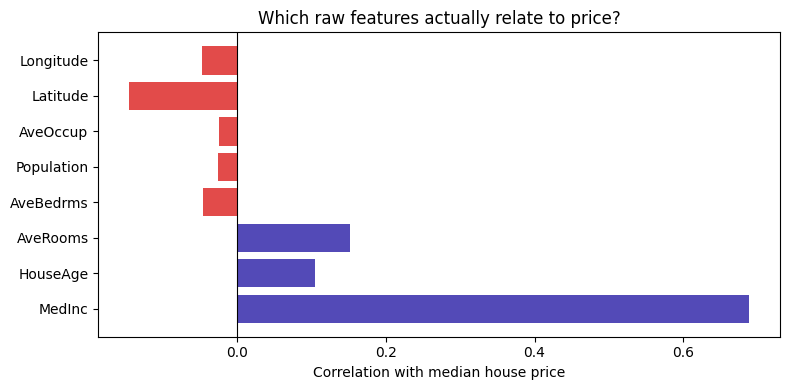

In [ ]:
# ==============================================================================
# PLOT A -- feature-target correlation bar chart (numpy + matplotlib)
# ==============================================================================
# This is the kind of "show me the data" plot you'd actually make in a real
# project before touching any model -- it tells you where the signal is.
plt.figure(figsize=(8, 4))
colors = ['#534AB7' if c >= 0 else '#E24B4A' for c in correlations]
plt.barh(list(feature_names_list), correlations, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with median house price')
plt.title('Which raw features actually relate to price?')
plt.tight_layout()


In [ ]:
# ==============================================================================
# SECTION 0.5 -- ⭐ PRODUCTION ADDITION: WHY WE CAN'T JUST REUSE degree=10
# ==============================================================================
# The teaching version cranked degree up to 10 on ONE feature to show
# dramatic overfitting. On 8 raw features, PolynomialFeatures doesn't just
# add x, x^2, ... x^10 -- it also adds every CROSS-TERM combination
# (x1*x2, x1^2*x3, x1*x2*x3^4, ...). The count explodes combinatorially.
#
# Formula: with n input features, the number of new columns for degree
# EXACTLY k is C(n+k-1, k) ("stars and bars" combinatorics). We sum k=1..d.

n_features = X.shape[1]
print("\n" + "=" * 70)
print("SECTION 0.5: WHY PRODUCTION DEGREE STAYS LOW")
print("=" * 70)
print(f"{'degree':>8} {'#poly features':>16} {'approx train matrix size':>28}")
for d in range(1, 11):
    total_cols = sum(math.comb(n_features + k - 1, k) for k in range(1, d + 1))
    approx_bytes = len(X_train) * total_cols * 8  # float64 = 8 bytes
    print(f"{d:>8} {total_cols:>16,} {approx_bytes / 1e9:>25.2f} GB")


SECTION 0.5: WHY PRODUCTION DEGREE STAYS LOW
  degree   #poly features     approx train matrix size
       1                8                      0.00 GB
       2               44                      0.01 GB
       3              164                      0.02 GB
       4              494                      0.07 GB
       5            1,286                      0.17 GB
       6            3,002                      0.40 GB
       7            6,434                      0.85 GB
       8           12,869                      1.70 GB
       9           24,309                      3.21 GB
      10           43,757                      5.78 GB


In [ ]:
def build_model(degree, alpha=0.0):
    """
    degree: how many polynomial powers/interactions to generate across ALL
            8 columns (not just 1 now) -- see Section 0.5 for why we keep
            this small.
    alpha:  regularization strength. 0 = plain LinearRegression.
    """
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        # On 8 features this single line is doing a LOT more work than in
        # the teaching version -- it's generating every combination of the
        # 8 raw columns up to the given degree, not just powers of one number.
        ('scaler', StandardScaler()),
        # ⭐ Even more important now: 8 raw columns on wildly different
        # scales (Section 0 table above) get put on equal footing here
        # BEFORE the model sees them.
        ('model', Ridge(alpha=alpha) if alpha > 0 else LinearRegression())
    ])


# ⭐ PRODUCTION CHANGE #2: degree grid capped at 5, not 10 (see Section 0.5)
high_bias_model     = build_model(degree=1)   # straight-line-in-8D -- too simple
good_model          = build_model(degree=2)   # first interactions -- balanced
high_variance_model = build_model(degree=5)   # 1,286 generated features -- overfits



SECTION 2: LEARNING CURVES — FINAL MSE AT FULL TRAINING SIZE
                         Model    Train MSE     Test MSE        Gap
--------------------------------------------------------------------
          Degree 1 (high bias)       0.5179       0.7254     0.2075
         Degree 2 (just right)       0.4207       7.3690     6.9482
      Degree 5 (high variance)       0.2334 18259216263.7451 18259216263.5117


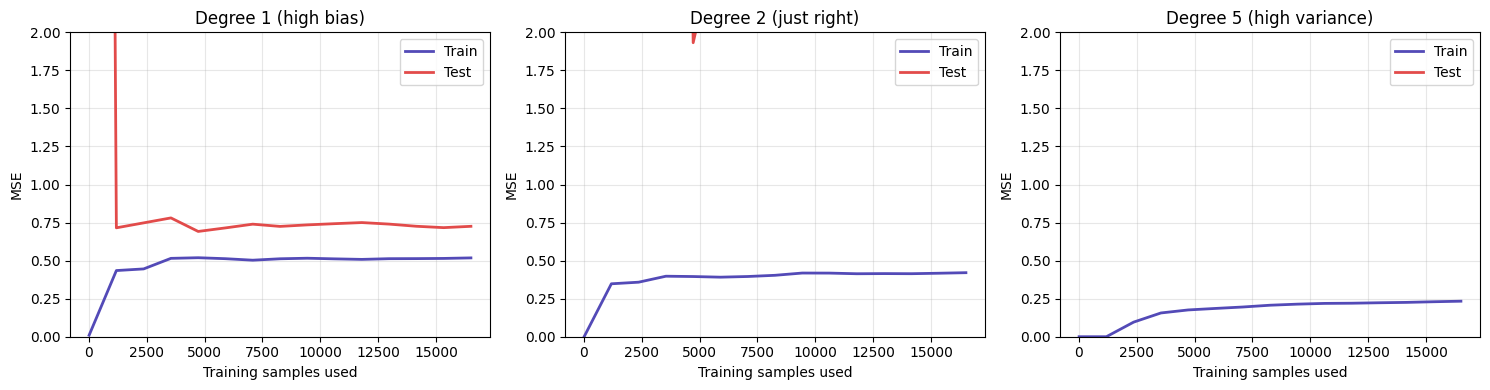


HOW TO READ THESE WITH 8 FEATURES vs 1 FEATURE:
  Degree 1: both errors plateau HIGH → high bias → model too simple for 8D data
  Degree 2: both errors converge LOW → good fit
  Degree 5: train error near 0, test error stays high → high variance
             Large gap = model memorizes the 1286 features, can't generalize
 
Same pattern as the teaching version, just with more realistic error values.



In [ ]:

# ==============================================================================
# SECTION 2 -- LEARNING CURVES (identical function, works on any # of columns)
# ==============================================================================

def learning_curves(model, X_train, y_train, X_test, y_test, sizes=None):
    """
    Train on increasing amounts of data. Record train + test error at each size.
    Test set NEVER changes — only training size changes. Fair comparison.
    """
    if sizes is None:
        sizes = np.linspace(10, len(X_train), 15, dtype=int)
        # 15 evenly-spaced checkpoints from 10 to full training size.
        # dtype=int: sizes used for array indexing, must be whole numbers.

    train_errors, test_errors = [], []

    for size in sizes:
        X_sub = X_train[:size]   # first `size` training rows
        y_sub = y_train[:size]

        model.fit(X_sub, y_sub)
        # Fits the ENTIRE pipeline (poly → scale → Ridge) on just this subset.

        train_errors.append(mean_squared_error(y_sub, model.predict(X_sub)))
        test_errors.append(mean_squared_error(y_test, model.predict(X_test)))
        # Training error: how well it fits what it was trained on.
        # Test error: how well it generalizes to unseen data.
        # The GAP between these two is your variance signal.

    return np.array(train_errors), np.array(test_errors), sizes


# Plot all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_specs = {
    'Degree 1 (high bias)':      high_bias_model,
    'Degree 2 (just right)':     good_model,
    'Degree 5 (high variance)':  high_variance_model,
}

print("\n" + "=" * 65)
print("SECTION 2: LEARNING CURVES — FINAL MSE AT FULL TRAINING SIZE")
print("=" * 65)
print(f"{'Model':>30} {'Train MSE':>12} {'Test MSE':>12} {'Gap':>10}")
print("-" * 68)

for ax, (name, model) in zip(axes, model_specs.items()):
    train_err, test_err, sizes = learning_curves(model, X_train, y_train, X_test, y_test)

    ax.plot(sizes, train_err, label='Train', color='#534AB7', linewidth=2)
    ax.plot(sizes, test_err,  label='Test',  color='#E24B4A', linewidth=2)
    ax.set_xlabel('Training samples used')
    ax.set_ylabel('MSE')
    ax.set_title(name)
    ax.legend()
    ax.set_ylim(0, 2)
    ax.grid(alpha=0.3)

    gap = test_err[-1] - train_err[-1]
    print(f"{name:>30} {train_err[-1]:>12.4f} {test_err[-1]:>12.4f} {gap:>10.4f}")

plt.tight_layout()
plt.show()

print("""
HOW TO READ THESE WITH 8 FEATURES vs 1 FEATURE:
  Degree 1: both errors plateau HIGH → high bias → model too simple for 8D data
  Degree 2: both errors converge LOW → good fit
  Degree 5: train error near 0, test error stays high → high variance
             Large gap = model memorizes the 1286 features, can't generalize

Same pattern as the teaching version, just with more realistic error values.
""")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — NESTED CROSS-VALIDATION  ⭐ MOST IMPORTANT SECTION
# ═══════════════════════════════════════════════════════════════════════════
# This is the section most ML practitioners get wrong in real jobs.
#
# WRONG approach (what most people do):
#   1. Use 5-fold CV to find best degree and alpha
#   2. Report that CV score as your model's final performance
#   Problem: you used the same data to PICK the hyperparameters AND to
#   EVALUATE the model. Of course it looks good — you tuned it to.
#   This number is optimistically biased.
#
# CORRECT approach: nested CV.
#   Outer loop → evaluates model honestly (never touched during tuning)
#   Inner loop → finds best hyperparameters (inside each outer fold)


outer_cv = KFold(n_splits = 5, shuffle =True, random_state=42)

inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

pipeline =  Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])
param_grid = {
    'poly__degree': [1, 2, 3],
    # 'poly__degree' → the 'degree' parameter of the step named 'poly'.
    # Double underscore = nested parameter access into a pipeline step.
    # This syntax works for ANY pipeline step and ANY parameter.

    'model__alpha': [0.01, 0.1, 1.0, 10.0]
    # 'model__alpha' → the 'alpha' parameter of the step named 'model'.
    # 3 degrees × 4 alphas = 12 combinations per outer fold.
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=inner_cv,
    # ⭐ GridSearchCV uses the INNER cv to select hyperparameters.
    # For each of the 12 param combinations: run 3-fold CV on the
    # outer training data to estimate its performance. Pick best.

    scoring='neg_mean_squared_error',
    n_jobs=-1
    # Use all CPU cores. Each of the 180 fits is independent → parallelizable.
)
# ⭐ THE KEY: grid_search ITSELF is passed as "the model" to cross_val_score.
# For each outer fold:
#   1. grid_search.fit(outer_train_data) is called
#      → this internally runs 3-fold inner CV to find best hyperparameters
#      → refits the winner on ALL outer training data
#   2. The best model is scored on outer_test_data
#      → outer_test_data was NEVER seen during hyperparameter search
# This two-layer separation is what makes the final number honest.

print("=" * 65)
print("SECTION 6: NESTED CROSS-VALIDATION (running... takes ~30 sec)")
print("=" * 65)

outer_scores = cross_val_score(
    grid_search,
    X_train,
    y_train,
    cv=outer_cv,
    scoring='neg_mean_squared_error'
)

nested_mse = -outer_scores   # flip sign as always

print(f"Nested CV MSE per outer fold: {nested_mse.round(4)}")
print(f"Nested CV MSE: {nested_mse.mean():.4f} ± {nested_mse.std():.4f}")
print("""
This is the HONEST number to report. Not the inner CV score.
The inner CV score would be optimistically biased because it was
used to pick the hyperparameters that looked best on that same data.
""")

# After nested CV confirms the approach is sound, train on ALL data
# to get your actual final model for deployment.
grid_search.fit(X_train, y_train)
print(f"Best hyperparameters found: {grid_search.best_params_}")
# 'poly__degree' and 'model__alpha' show which combination won across
# the inner CV folds.

final_test_mse = mean_squared_error(y_test, grid_search.predict(X_test))
print(f"Final test MSE (true holdout, checked ONCE): {final_test_mse:.4f}")
print("""
⚠ You check X_test exactly ONCE — right here.
If you look at test MSE to make decisions (adjust degree, adjust alpha),
it becomes a validation set and the number is no longer honest.
""")



SECTION 6: NESTED CROSS-VALIDATION (running... takes ~30 sec)
Nested CV MSE per outer fold: [17.7506  0.5259  0.4862  0.5378  0.5081]
Nested CV MSE: 3.9617 ± 6.8945

This is the HONEST number to report. Not the inner CV score.
The inner CV score would be optimistically biased because it was
used to pick the hyperparameters that looked best on that same data.

Best hyperparameters found: {'model__alpha': 1.0, 'poly__degree': 1}
Final test MSE (true holdout, checked ONCE): 0.7252

⚠ You check X_test exactly ONCE — right here.
If you look at test MSE to make decisions (adjust degree, adjust alpha),
it becomes a validation set and the number is no longer honest.



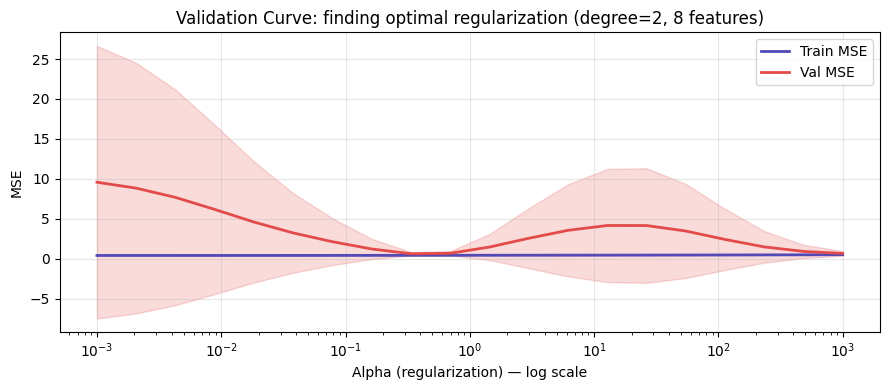


SECTION 7: VALIDATION CURVE RESULT
Optimal alpha: 0.3360

WHAT THE PLOT SHOWS:
  Small alpha (left) → little regularization → model overfits the 44 features
    → train MSE near 0, val MSE high, BIG gap
 
  Large alpha (right) → heavy regularization → weights shrink to near zero
    → model becomes too simple (underfitting)
    → BOTH train and val MSE rise
 
  Optimal alpha = the VALLEY (minimum) in the RED validation curve.
  This is the bottom of the U-curve from Module 5's bias-variance theory
  turned into actual numbers you can pick from.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — VALIDATION CURVE (tune ONE hyperparameter visually)
# ═══════════════════════════════════════════════════════════════════════════
# Simpler than nested CV. Answers: "as I change alpha, what happens to
# train vs validation MSE?" Shows the U-curve (underfitting → optimal → overfitting).

param_range = np.logspace(-3, 3, 20)
# np.logspace(-3, 3, 20) → 20 values evenly spaced on LOG scale
# from 10^-3 = 0.001 to 10^3 = 1000.
# WHY log scale: alpha spans orders of magnitude. Linear spacing would
# waste almost all 20 points on large alpha values, ignoring the
# interesting small-alpha region.

train_scores, val_scores = validation_curve(
    Pipeline([
        ('poly',   PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model',  Ridge())
    ]),
    X_train, y_train,
    param_name='model__alpha',
    # MUST match the pipeline step name exactly.
    # 'model__alpha' → Ridge's alpha parameter, accessed via the 'model' step.

    param_range=param_range,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
# Returns shape (20, 5): 20 alpha values × 5 CV folds each.
# train_scores[i, j] = training score for alpha[i] on fold j.
# val_scores[i, j]   = validation score for alpha[i] on fold j.

train_mean = -train_scores.mean(axis=1)
# axis=1 → average across the 5 folds for each alpha value.
# Result: shape (20,) — one mean MSE per alpha value.

val_mean   = -val_scores.mean(axis=1)
train_std  =  train_scores.std(axis=1)
val_std    =  val_scores.std(axis=1)

plt.figure(figsize=(9, 4))
plt.semilogx(param_range, train_mean, label='Train MSE', color='#534AB7', linewidth=2)
plt.fill_between(
    param_range,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2, color='#534AB7'
)
# Shaded band = ±1 std deviation across folds.
# Wide band = unstable (performance varies across folds = unreliable model).
# Narrow band = consistent.

plt.semilogx(param_range, val_mean, label='Val MSE', color='#E24B4A', linewidth=2)
plt.fill_between(
    param_range,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2, color='#E24B4A'
)

plt.xlabel('Alpha (regularization) — log scale')
plt.ylabel('MSE')
plt.title('Validation Curve: finding optimal regularization (degree=2, 8 features)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = param_range[val_mean.argmin()]
# argmin() → index of the lowest validation MSE
# param_range[that index] → the corresponding alpha value
print("\n" + "=" * 65)
print("SECTION 7: VALIDATION CURVE RESULT")
print("=" * 65)
print(f"Optimal alpha: {best_alpha:.4f}")
print("""
WHAT THE PLOT SHOWS:
  Small alpha (left) → little regularization → model overfits the 44 features
    → train MSE near 0, val MSE high, BIG gap

  Large alpha (right) → heavy regularization → weights shrink to near zero
    → model becomes too simple (underfitting)
    → BOTH train and val MSE rise

  Optimal alpha = the VALLEY (minimum) in the RED validation curve.
  This is the bottom of the U-curve from Module 5's bias-variance theory
  turned into actual numbers you can pick from.
""")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — diagnose_model() — REUSABLE FOREVER ⭐
# ═══════════════════════════════════════════════════════════════════════════
# Copy this function into every regression project you ever build.
# Identical logic to teaching version — works on any feature count.

def diagnose_model(model, X_train, y_train, X_test, y_test, cv=5):
    """
    Full bias-variance diagnosis on any sklearn-compatible regression model.
    Prints a clear report and tells you what to try next.
    """
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring='neg_mean_squared_error',
        return_train_score=True
    )

    train_mse_cv = -cv_results['train_score']   # training MSE per fold
    val_mse_cv   = -cv_results['test_score']    # validation MSE per fold

    # Refit on full training data to get final test score
    model.fit(X_train, y_train)
    final_test_mse = mean_squared_error(y_test, model.predict(X_test))

    train_mean = train_mse_cv.mean()
    val_mean   = val_mse_cv.mean()
    gap        = val_mean - train_mean
    # Positive gap is normal (models always fit training data better).
    # LARGE relative gap = overfitting.

    relative_gap = gap / val_mean if val_mean > 0 else 0
    # Gap as fraction of validation error.
    # > 30% relative gap = likely overfitting.
    # < 5% relative gap with HIGH val_mean = likely underfitting.

    print("=" * 50)
    print("MODEL DIAGNOSIS REPORT")
    print("=" * 50)
    print(f"Train MSE (CV mean):      {train_mean:.4f}")
    print(f"Val MSE   (CV mean):      {val_mean:.4f} ± {val_mse_cv.std():.4f}")
    print(f"Final test MSE:           {final_test_mse:.4f}")
    print(f"Gap (val - train):        {gap:.4f}")
    print(f"Relative gap:             {relative_gap:.1%}")
    print()

    # Thresholds are dataset-specific. For California housing (target in $100k),
    # MSE > 0.5 is noticeably bad. Relative gap > 30% signals variance.
    if train_mean > 0.5:
        print("DIAGNOSIS: HIGH BIAS (underfitting)")
        print("→ Training MSE itself is too high — model too simple for 8-feature data")
        print("→ Try: higher degree (carefully — see Section 0.5), less regularization")
        print("→ Or: switch to Random Forest / XGBoost (Module 7)")
    elif relative_gap > 0.30:
        print("DIAGNOSIS: HIGH VARIANCE (overfitting)")
        print("→ Large gap between train and validation — model memorizing training data")
        print("→ Try: increase alpha, lower degree, or more training data")
    else:
        print("DIAGNOSIS: REASONABLE FIT")
        print("→ Bias and variance appear balanced for this model complexity")
        print("→ Next step: feature engineering (see correlation table in Section 0)")
    print("=" * 50)

    return {
        'train_mse': train_mean,
        'val_mse':   val_mean,
        'test_mse':  final_test_mse,
        'gap':       gap,
        'relative_gap': relative_gap
    }


print("\n" + "=" * 65)
print("SECTION 8: FULL DIAGNOSIS — THREE MODELS, ALL 8 FEATURES")
print("=" * 65)

for name, model in [
    ('Degree 1 — high bias',      build_model(degree=1)),
    ('Degree 2 — just right',     build_model(degree=2)),
    ('Degree 5 — high variance',  build_model(degree=5)),
]:
    print(f"\n{'─'*50}")
    print(f"MODEL: {name}")
    diagnose_model(model, X_train, y_train, X_test, y_test)



SECTION 8: FULL DIAGNOSIS — THREE MODELS, ALL 8 FEATURES

──────────────────────────────────────────────────
MODEL: Degree 1 — high bias
MODEL DIAGNOSIS REPORT
Train MSE (CV mean):      0.5178
Val MSE   (CV mean):      0.5193 ± 0.0149
Final test MSE:           0.7254
Gap (val - train):        0.0015
Relative gap:             0.3%

DIAGNOSIS: HIGH BIAS (underfitting)
→ Training MSE itself is too high — model too simple for 8-feature data
→ Try: higher degree (carefully — see Section 0.5), less regularization
→ Or: switch to Random Forest / XGBoost (Module 7)

──────────────────────────────────────────────────
MODEL: Degree 2 — just right
MODEL DIAGNOSIS REPORT
Train MSE (CV mean):      0.4180
Val MSE   (CV mean):      10.4483 ± 18.6011
Final test MSE:           7.3690
Gap (val - train):        10.0303
Relative gap:             96.0%

DIAGNOSIS: HIGH VARIANCE (overfitting)
→ Large gap between train and validation — model memorizing training data
→ Try: increase alpha, lower degree, or m

# Module 7 — Decision Trees, Random Forests & XGBoost
### Gini and entropy. Bagging math. Why randomness makes forests better. XGBoost internals.

---

## Part 1 — What is a Decision Tree?

A decision tree is literally a flowchart. Ask a question about one feature, split the data into two groups, ask another question on each group, keep going until you reach a final answer.

```
Is age > 30?
├── YES → Is income > 50k?
│         ├── YES → BUYS (probability 0.82)
│         └── NO  → DOESN'T BUY (probability 0.71)
└── NO  → DOESN'T BUY (probability 0.89)
```

Each internal node = a question (feature + threshold).
Each leaf = a prediction.
The tree learns which questions to ask and in which order — entirely from data.

**The key question:** how do you decide which question to ask at each node?
Answer: the **splitting criterion** — this is where the math lives.

---

## Part 2 — Gini Impurity (the math)

At every node you have a bag of samples. Some are class 1, some are class 0. You want the split that creates the **purest** child nodes.

**Gini impurity** measures how mixed a node is:

$$\text{Gini} = 1 - \sum_k p_k^2$$

Where $p_k$ = fraction of samples belonging to class $k$.

For binary classification (just two classes):

$$\text{Gini} = 1 - (p^2 + (1-p)^2) = 2p(1-p)$$

**Check the extremes:**

| Situation | p | Gini | Meaning |
|-----------|---|------|---------|
| All class 1 | 1.0 | 2×1×0 = **0** | Perfectly pure |
| All class 0 | 0.0 | 2×0×1 = **0** | Perfectly pure |
| Half and half | 0.5 | 2×0.5×0.5 = **0.5** | Worst possible — totally mixed |

**Weighted Gini of a split** (what you actually compute):

$$\text{Gini(split)} = \frac{n_{left}}{n} \times \text{Gini(left)} + \frac{n_{right}}{n} \times \text{Gini(right)}$$

The split with the **lowest weighted Gini** is chosen. Larger child nodes count more — prevents tricks like making one tiny pure leaf and one huge impure one.

---

## Part 2b — Entropy (the information theory alternative)

$$\text{Entropy} = -\sum_k p_k \times \log_2(p_k)$$

For binary:
$$\text{Entropy} = -p \log_2(p) - (1-p)\log_2(1-p)$$

| Situation | Entropy | Meaning |
|-----------|---------|---------|
| Pure node (p=1) | 0 | No uncertainty |
| Mixed (p=0.5) | 1.0 bit | Maximum uncertainty |

The gain from using entropy is called **Information Gain**:
$$IG = \text{Entropy(parent)} - \text{weighted Entropy(children)}$$

**Gini vs Entropy in practice:** Almost identical results. Gini is slightly faster (no log). sklearn uses Gini by default. In 10 years of production ML, this choice almost never changes anything — don't overthink it.

---

## Part 3 — How a Tree is Built

The algorithm is **recursive binary splitting:**

1. At the current node, try EVERY feature and EVERY unique value as a split threshold
2. For each (feature, threshold) combination, compute weighted Gini of the two children
3. Pick the split with lowest weighted Gini
4. Split the samples into left and right groups
5. Repeat from step 1 on each child node

**Stop when:**
- Reached `max_depth`
- Node has fewer than `min_samples_split` samples
- Node is already pure (Gini = 0) — can't improve it

**Leaf prediction** = majority class of all samples that reached that leaf.

---

## Part 4 — The Problem with a Single Tree

A tree with no depth limit memorizes training data perfectly. Every leaf has exactly one sample → training accuracy = 100% → test accuracy is garbage.

Even a depth-limited tree is **unstable**: change a few training samples → completely different tree structure. This is high variance.

**Solution:** train many trees and combine their predictions — **bagging**.

---

## Part 5 — Bagging and Bootstrap (the math)

**Bootstrap sampling:** from $n$ training samples, create a new dataset of size $n$ by sampling **with replacement**.

```
Original: [A, B, C, D, E]
Bootstrap: [A, A, C, E, C]  ← some repeated, some missing
```

On average, **~63.2% of original samples appear** in each bootstrap dataset. The rest (~36.8%) are called **Out-Of-Bag (OOB) samples.**

**Why 63.2%?** Probability that one specific sample is NOT selected in one draw = $(1 - 1/n)$. Over $n$ draws: $(1 - 1/n)^n \to e^{-1} \approx 0.368$ as $n \to \infty$. So 36.8% left out → 63.2% included.

**OOB samples are a free validation set.** Each tree can be evaluated on samples it never trained on. Reliable accuracy estimate without needing a separate validation split.

**Why does averaging reduce variance?**

If $B$ trees each have variance $\sigma^2$ and are **independent**, variance of their average = $\sigma^2 / B$.

With 100 trees → variance drops 100×. In practice trees are correlated (similar data), so reduction is less — but still dramatic. Bias stays the same (averaging doesn't shift the center). So bagging reduces variance **without increasing bias**.

---

## Part 6 — Random Forest: Bagging + Feature Randomness

Bagging alone: all trees see the same features → if one feature is very predictive, every tree splits on it near the root → trees are highly correlated → averaging correlated trees doesn't reduce variance much.

**Random Forest's fix:** at each split, only consider a **random subset of features** (typically $\sqrt{n\_features}$).

Different trees find different patterns → trees are decorrelated → their average is much more stable.

> This is the entire innovation of Random Forest. Everything else is just bagging.

**Key hyperparameters:**

| Parameter | What it does | Default |
|-----------|-------------|---------|
| `n_estimators` | Number of trees. More = lower variance. Returns diminish after ~200. | 100 |
| `max_depth` | Depth per tree. RF uses deep trees — averaging handles the variance. | None (full) |
| `max_features` | Features per split. `'sqrt'` for classification, `0.5` or `'sqrt'` for regression. | `'sqrt'` |
| `min_samples_leaf` | Minimum samples per leaf. Higher = smoother, less overfit. | 1 |

---

## Part 7 — XGBoost: A Completely Different Idea

Random Forest trains trees **in parallel** and averages. XGBoost trains trees **sequentially** — each tree fixes the mistakes of all previous trees. This is **gradient boosting**.

### The Boosting Intuition

```
Round 1: Train a weak tree on data. Compute residuals (errors).
Round 2: Train a new tree on the RESIDUALS from round 1.
Round 3: Train a new tree on residuals of (round 1 + round 2 predictions).
...
Final prediction = sum of all trees × learning rate
```

$$\hat{y} = \hat{y}_0 + \eta f_1(x) + \eta f_2(x) + \cdots + \eta f_n(x)$$

$\eta$ (eta) = learning rate. Each $f_t$ = one tree.

---

### XGBoost's Innovation: Second-Order Gradients

Vanilla boosting fits each tree on the **first-order residuals** (gradient of loss).

XGBoost uses the **second-order Taylor expansion** — both gradient AND curvature. This gives much better information about how to fit the next tree → faster convergence, better performance.

For each sample $i$:
- $g_i = \partial L / \partial \hat{y}_i$ — gradient (which direction to move)
- $h_i = \partial^2 L / \partial \hat{y}_i^2$ — hessian (how sharply loss curves)

**Optimal leaf value:**

$$w^* = -\frac{\sum_{i \in R} g_i}{\sum_{i \in R} h_i + \lambda}$$

**Gain from a split:**

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$$

Where $G_L, G_R$ = sum of gradients in left/right child, $H_L, H_R$ = sum of hessians, $\lambda$ = L2 regularization, $\gamma$ = minimum gain to make a split.

> XGBoost directly optimizes the actual loss function instead of a proxy (Gini). That's why it almost always beats Random Forest on tabular data.

---

### XGBoost Key Hyperparameters

| Parameter | What it does | Default | Tune? |
|-----------|-------------|---------|-------|
| `n_estimators` | Number of boosting rounds. Unlike RF, more CAN overfit. Use early stopping. | 100 | Yes |
| `max_depth` | Depth per tree. Use **shallow** trees (3-6) — boosting works with weak learners. | 6 | Yes |
| `learning_rate` | How much each tree contributes. Smaller = needs more trees but generalizes better. | 0.3 | Yes |
| `subsample` | Fraction of samples per tree (WITHOUT replacement). Adds randomness. | 1.0 | Yes |
| `colsample_bytree` | Fraction of features per tree. Decorrelates trees. | 1.0 | Yes |
| `reg_lambda` | L2 regularization on leaf weights. Like Ridge from Module 3. | 1.0 | Sometimes |
| `reg_alpha` | L1 regularization on leaf weights. Like Lasso from Module 3. | 0 | Sometimes |
| `min_child_weight` | Minimum sum of hessians in a leaf. Higher = more conservative splits. | 1 | Yes |
| `gamma` | Minimum gain required to make a split. Higher = fewer splits = simpler trees. | 0 | Sometimes |

**Learning rate and n_estimators interact:** halving learning rate usually means doubling n_estimators. Use early stopping to find the right n_estimators automatically.

---

## Part 8 — Hyperparameter Tuning: RandomizedSearchCV vs GridSearchCV

**GridSearchCV:** tries ALL combinations in the grid. With 6 parameters × 5 values each = 15,625 combinations × 5 folds = 78,125 model fits. Too slow.

**RandomizedSearchCV:** tries $n\_iter$ random combinations. 50 random tries finds a good solution much faster. Almost always good enough.

---

## Part 9 — When to Use Which Model

| Situation | Use |
|-----------|-----|
| Need to explain every decision (medical, legal, court) | Single Decision Tree (shallow) |
| General tabular classification/regression, first try | **Random Forest** |
| Maximum accuracy on tabular data, Kaggle | **XGBoost** or LightGBM |
| Very large dataset (millions of rows) | LightGBM (faster than XGBoost) |
| Mostly categorical features | CatBoost (handles them natively) |
| Missing values in features | XGBoost (handles natively — no imputation needed) |
| Need probability calibration | Random Forest (better calibrated than XGBoost) |
| Small dataset (< 1000 rows) | Random Forest (XGBoost overfits more on small data) |
| Need built-in feature selection | Both (use `feature_importances_`) |

---

## Part 10 — Interview Questions, Answered

---

### Q: Why does Random Forest reduce variance but not bias?

Averaging $B$ trees reduces variance by roughly $1/B$. But the average of $B$ estimators each with bias $b$ is still $b$ — averaging doesn't shift the center.

So bagging only helps with variance. If a single tree has high bias (max_depth=2 on a complex problem), 1000 trees will have the same high bias. This is why RF uses deep trees — it can afford to because averaging handles the variance.

---

### Q: XGBoost vs Random Forest — which wins?

On most real tabular datasets, XGBoost wins — it directly optimizes the loss function, uses second-order information, and has more regularization.

Random Forest is faster (parallelizable), easier to tune (fewer hyperparameters), more robust to outliers.

> Start with Random Forest as your baseline. Switch to XGBoost if you need more accuracy and can afford the tuning time.

---

### Q: What does feature importance measure in XGBoost — and why can it be misleading?

XGBoost's default importance (`weight`) = number of times a feature is used in a split. This is **biased toward continuous features** with many possible split points.

Better alternatives:
- `gain` — average improvement in loss from splits using that feature
- **SHAP values** — theoretically grounded, consistent, shows direction of effect

For reliable feature importance in production → always use SHAP.

---

### Q: What is min_child_weight in XGBoost and why is it better than min_samples?

`min_child_weight` = minimum **sum of hessians** in a leaf.

For MSE loss: hessian = 1 per sample → equals sample count.
For logistic loss: hessian = $p(1-p)$ → samples near the decision boundary (p≈0.5) have high hessian; confident samples (p≈0 or p≈1) have low hessian.

A minimum hessian threshold prevents splits where XGBoost is very uncertain. More theoretically principled than a raw sample count.

---

## Always Remember

- **Gini measures impurity.** 0 = pure. 0.5 = maximally mixed. Always minimize it.
- **Trees overfit easily** — control with `max_depth`, `min_samples_leaf`.
- **Random Forest = bagging + random feature subsets.** The randomness decorrelates trees — that's the whole point.
- **OOB score is a free validation set.** No need for a separate split.
- **XGBoost trains sequentially** — each tree corrects the previous one's mistakes. Unlike RF which trains in parallel.
- **Shallow trees for XGBoost (depth 3-6). Deep trees for Random Forest.**
- **Early stopping** prevents XGBoost from overfitting. Always use it.
- **`subsample` and `colsample_bytree` in XGBoost** add randomness like RF does — helps prevent overfit.
- **Feature importance from trees ≠ causal importance.** Use SHAP for reliable interpretation.
- When in doubt: Random Forest first, XGBoost second.

Dataset shape: (569, 30)
Class distribution: {1: 357, 0: 212}
Features: [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...

=== DECISION TREE ===
              precision    recall  f1-score   support

   malignant       0.88      0.90      0.89        42
      benign       0.94      0.93      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



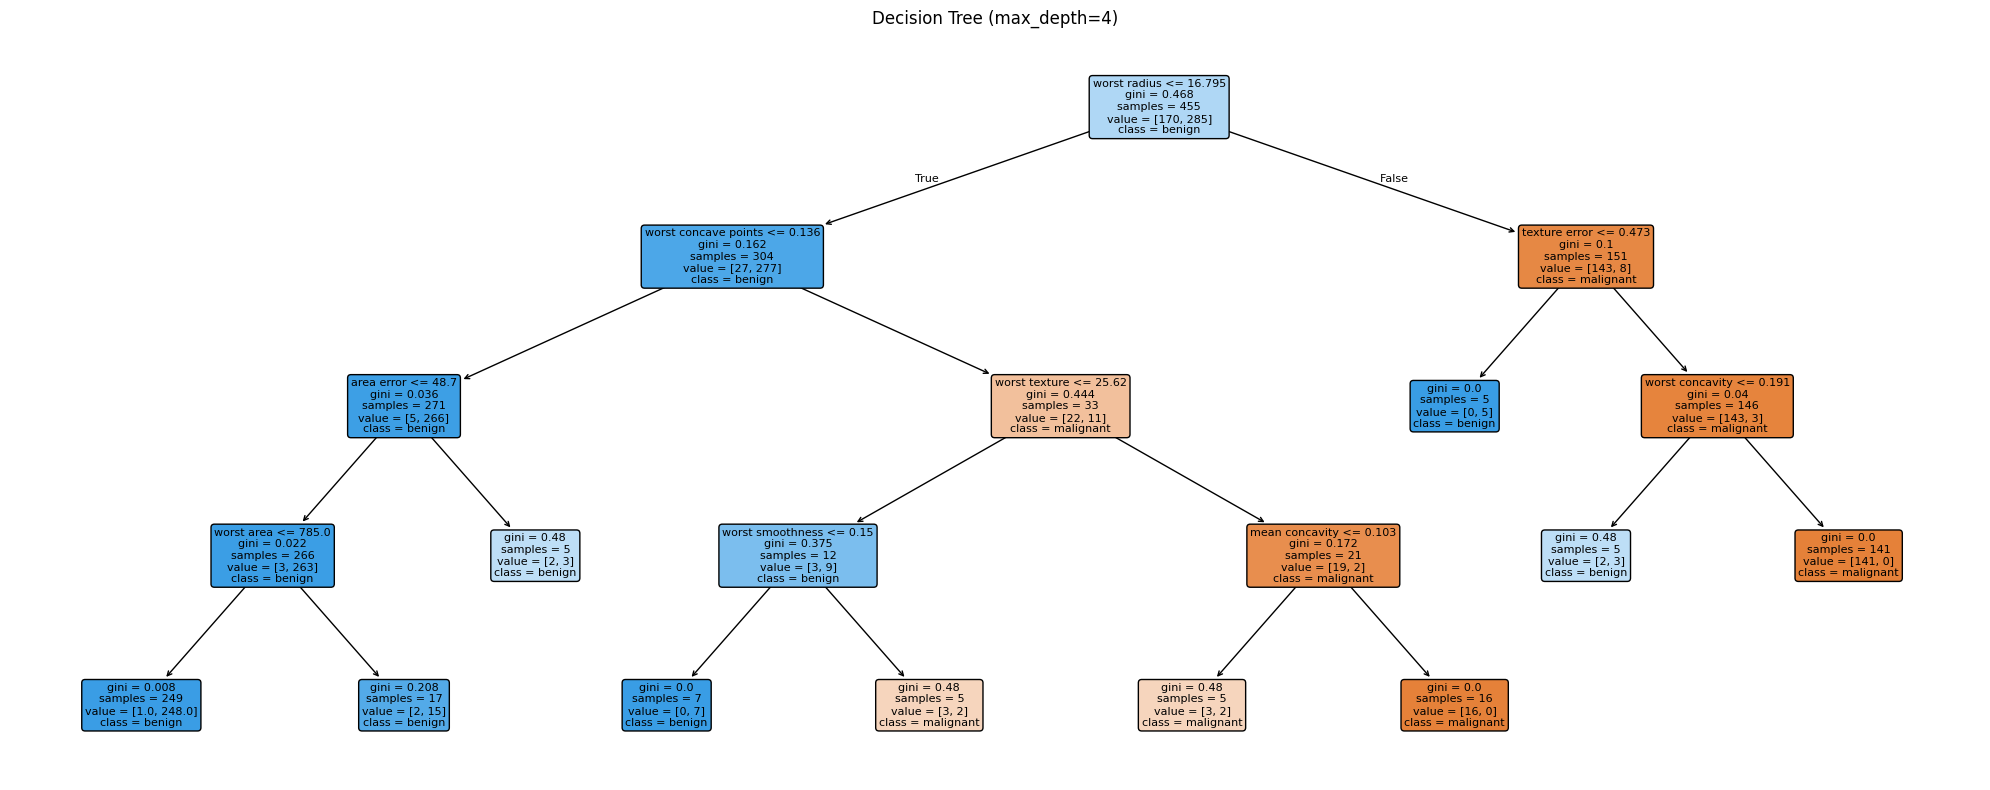


First 30 lines of tree structure:
|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 48.70
|   |   |   |--- worst area <= 785.00
|   |   |   |   |--- class: 1
|   |   |   |--- worst area >  785.00
|   |   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- worst smoothness <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.15
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- mean concavity <= 0.10
|   |   |   |   |--- class: 0
|   |   |   |--- mean concavity >  0.10
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0


Top 5 features by Gini gain:
worst radi

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 7 — DECISION TREES, RANDOM FORESTS & XGBOOST — FULL CODE
═══════════════════════════════════════════════════════════════════════════
Dataset: sklearn's breast cancer dataset (real, binary classification)
         + make_classification for XGBoost demo

Run top to bottom in Colab. pip install xgboost if needed.
═══════════════════════════════════════════════════════════════════════════
"""

!pip install xgboost shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    RandomizedSearchCV, KFold
)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform
import xgboost as xgb

np.random.seed(42)
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
# 569 samples, 30 features, binary: 0=malignant, 1=benign
# Real medical data — interpretability matters here (good use case for trees)

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {y.value_counts().to_dict()}")
print(f"Features: {list(data.feature_names[:5])} ...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
# stratify=y → each split has the same class ratio as the full dataset.
# Same as StratifiedKFold logic from Module 5.


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — DECISION TREE (sklearn — production)
# ═══════════════════════════════════════════════════════════════════════════


dt = DecisionTreeClassifier(
    criterion='gini',
    # 'gini': minimize Gini impurity at each split.
    # 'entropy': use information gain (log-based). Almost same results.
    # Gini is default and slightly faster.

    max_depth=4,
    # ⭐ MOST IMPORTANT HYPERPARAMETER for trees.
    # depth=1: one split, two leaves — very simple (high bias, low variance).
    # depth=None: grows until pure — memorizes everything (high variance).
    # depth=4: typically a good starting point.

    min_samples_split=10,
    # Don't split a node with fewer than 10 samples.
    # Prevents unreliable splits based on tiny groups.

    min_samples_leaf=5,
    # Each leaf must have at least 5 samples.
    # Prevents leaves that memorize individual training points.

    max_features=None,
    # None = use all features at every split.
    # For random subsets per split → use 'sqrt' (that's Random Forest territory).

    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
print("\n=== DECISION TREE ===")
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

# ── Visualize the tree ──────────────────────────────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,           # color nodes by majority class
    rounded=True,          # rounded boxes
    fontsize=8
)
plt.title("Decision Tree (max_depth=4)")
plt.tight_layout()
plt.show()
# Each box shows: feature <= threshold | Gini impurity | n_samples | class distribution

# ── Text representation (cleaner for notes) ───────────────────────────────
tree_text = export_text(dt, feature_names=list(data.feature_names))
print("\nFirst 30 lines of tree structure:")
print('\n'.join(tree_text.split('\n')[:30]))

# ── Feature importance from tree ───────────────────────────────────────────
dt_importance = pd.Series(
    dt.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)
# feature_importances_ = sum of Gini gain from all splits using that feature,
# weighted by the number of samples that passed through.
# Sums to 1.0 across all features.

print("\nTop 5 features by Gini gain:")
print(dt_importance.head(5).round(4))

# ── Try different max_depth values ─────────────────────────────────────────
print("\n=== EFFECT OF MAX_DEPTH ===")
print(f"{'Depth':>8} {'Train Acc':>12} {'Test Acc':>12} {'CV Acc':>12}")
print("-" * 48)

for depth in [1, 2, 3, 4, 5, 8, None]:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = clf.score(X_train, y_train)
    test_acc  = clf.score(X_test, y_test)
    cv_acc    = cross_val_score(clf, X_train, y_train, cv=5).mean()
    depth_str = str(depth) if depth else 'None'
    print(f"{depth_str:>8} {train_acc:>12.4f} {test_acc:>12.4f} {cv_acc:>12.4f}")
# Watch: depth=None → train_acc=1.0 but test_acc drops → classic overfit.
# Optimal is usually somewhere in the middle where test/CV acc peaks.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — BOOTSTRAP AND OOB DEMO
# ═══════════════════════════════════════════════════════════════════════════
print("\n=== BOOTSTRAP SAMPLING DEMO ===")
n = 100
bootstrap_indices = np.random.choice(n, size=n, replace=True)
# replace=True → same index can be picked multiple times.
# On average 63.2% unique indices in each bootstrap sample.

oob_indices = np.setdiff1d(np.arange(n), bootstrap_indices)
# np.setdiff1d(A, B) → elements in A that are NOT in B.
# All sample indices [0..99] minus the bootstrap indices = OOB.

unique_in_bootstrap = len(np.unique(bootstrap_indices))
print(f"Total samples: {n}")
print(f"Unique in bootstrap: {unique_in_bootstrap} ({unique_in_bootstrap/n*100:.1f}%)")
print(f"Out-of-bag (OOB): {len(oob_indices)} ({len(oob_indices)/n*100:.1f}%)")
# Should be approximately 63.2% and 36.8%.


=== BOOTSTRAP SAMPLING DEMO ===
Total samples: 100
Unique in bootstrap: 61 (61.0%)
Out-of-bag (OOB): 39 (39.0%)



=== RANDOM FOREST ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

OOB Score (free validation): 0.9604
Test Score:                  0.9561

OOB score convergence as we add more trees:


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


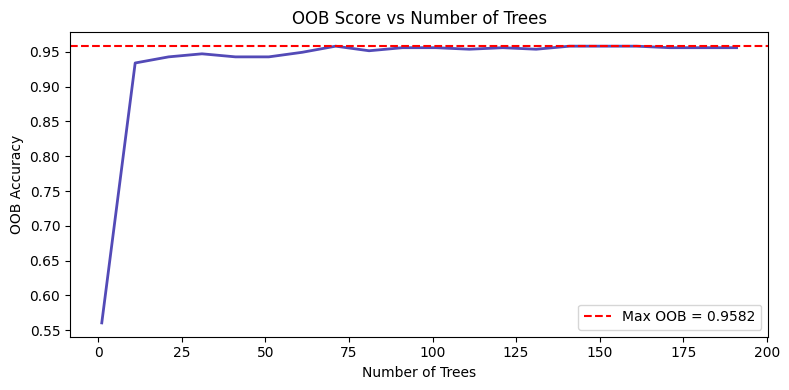

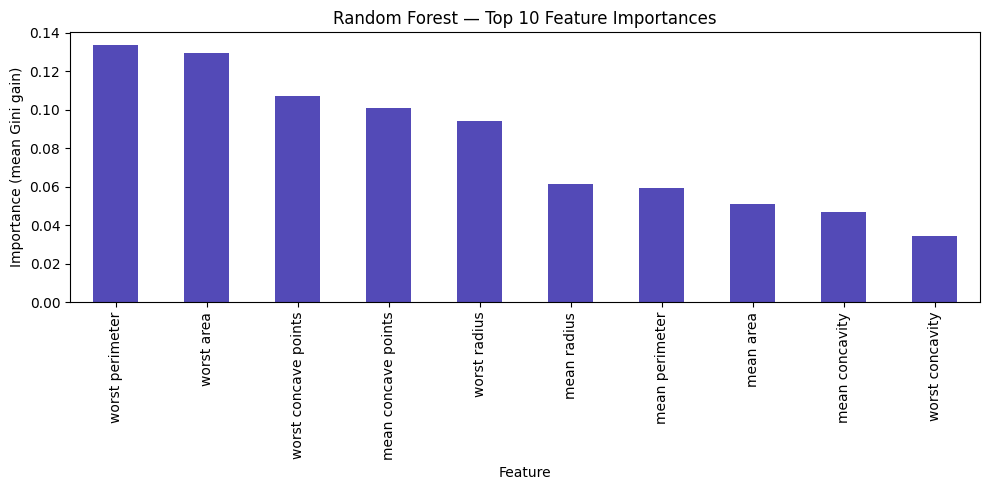


Top 5 RF features:
worst perimeter         0.1335
worst area              0.1294
worst concave points    0.1069
mean concave points     0.1011
worst radius            0.0940
dtype: float64


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — RANDOM FOREST (sklearn — production)  ⭐ START HERE IN REAL PROJECTS
# ═══════════════════════════════════════════════════════════════════════════

rf = RandomForestClassifier(
    n_estimators=200,
    # Number of trees. Performance improves with more trees then plateaus.
    # ~100-500 is the practical range. After ~200, returns diminish fast.
    # More trees = more compute, never hurts accuracy — just slower.

    max_depth=None,
    # ⭐ Random Forest uses DEEP trees on purpose.
    # Each tree overfits on its bootstrap sample — that's fine.
    # Averaging the predictions of many overfit trees REDUCES variance.
    # This is the key insight: deep trees (low bias) + averaging (low variance).

    max_features='sqrt',
    # ⭐ THE KEY RF INGREDIENT. At each split, randomly select sqrt(n_features)
    # features and find best split among ONLY those features.
    # sqrt(30) ≈ 5-6 features per split on this dataset.
    # WHY: different trees use different features → decorrelated → better averaging.
    # 'sqrt' for classification. 0.5 or 'sqrt' for regression.

    min_samples_leaf=1,
    # Default. Try 2-5 if overfitting on small datasets.

    bootstrap=True,
    # Use bootstrap sampling. True = standard Random Forest.
    # False = Extremely Randomized Trees (ExtraTreesClassifier).

    oob_score=True,
    # ⭐ Compute OOB score automatically.
    # For each tree, predict on its ~36.8% out-of-bag samples.
    # Average across all trees → free validation estimate.
    # No need for a separate validation split.

    n_jobs=-1,           # use all CPU cores — trees train in parallel
    random_state=42,
    verbose=0
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))
print(f"OOB Score (free validation): {rf.oob_score_:.4f}")
print(f"Test Score:                  {rf.score(X_test, y_test):.4f}")
# OOB score should be close to test score — it's an honest estimate without a split.

# ── OOB score vs number of trees ──────────────────────────────────────────
print("\nOOB score convergence as we add more trees:")
oob_scores = []
n_trees_range = range(1, 201, 10)

for n_trees in n_trees_range:
    clf = RandomForestClassifier(
        n_estimators=n_trees,
        oob_score=True,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_train, y_train)
    oob_scores.append(clf.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(list(n_trees_range), oob_scores, color='#534AB7', linewidth=2)
plt.xlabel('Number of Trees')
plt.ylabel('OOB Accuracy')
plt.title('OOB Score vs Number of Trees')
plt.axhline(y=max(oob_scores), color='red', linestyle='--',
            label=f'Max OOB = {max(oob_scores):.4f}')
plt.legend()
plt.tight_layout()
plt.show()
# Watch: score rises fast then flattens around 50-100 trees.
# Adding more trees after the plateau wastes compute.

# ── RF feature importance ──────────────────────────────────────────────────
rf_importance = pd.Series(
    rf.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
rf_importance.head(10).plot(kind='bar', color='#534AB7')
plt.title('Random Forest — Top 10 Feature Importances')
plt.ylabel('Importance (mean Gini gain)')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 RF features:")
print(rf_importance.head(5).round(4))





=== XGBOOST ===
Best iteration (early stopping): 135
Best validation logloss:         0.1844
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Test ROC-AUC: 0.9927


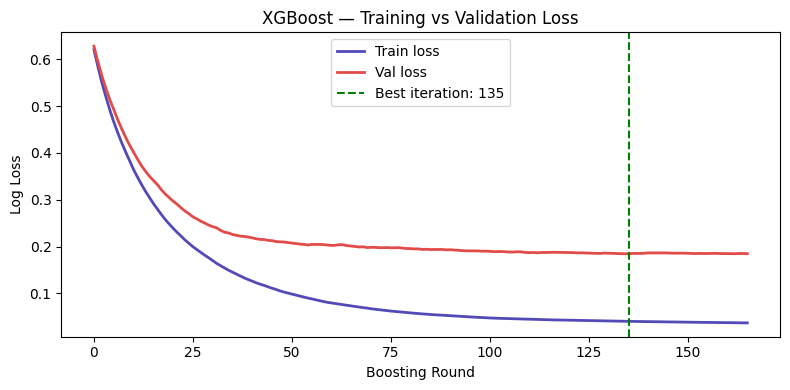


Top 5 XGBoost features:
worst perimeter         0.3237
worst concave points    0.1067
worst radius            0.0895
mean concave points     0.0690
worst area              0.0667
dtype: float32

=== RANDOMIZED SEARCH (30 iterations × 5 folds) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'colsample_bytree': np.float64(0.7334834444556088), 'gamma': np.float64(0.07143340896097039), 'learning_rate': np.float64(0.13366880986028204), 'max_depth': 7, 'min_child_weight': 2, 'n_estimators': 443, 'reg_alpha': np.float64(0.8324426408004217), 'reg_lambda': np.float64(1.4555259980522428), 'subsample': np.float64(0.6727299868828402)}
Best CV AUC: 0.9917

Best model test AUC: 0.9917
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg   

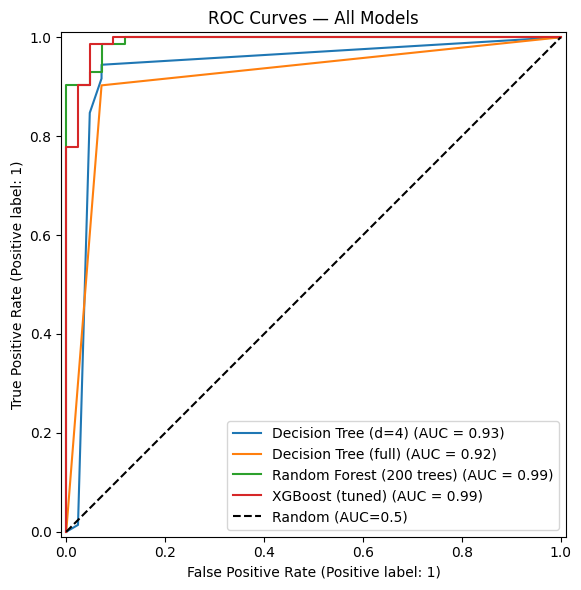

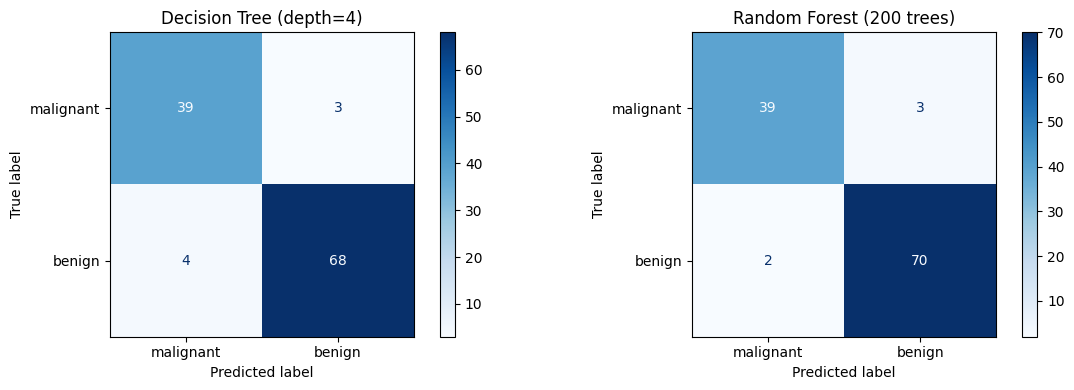

"\n1. DECISION TREE:\n   - max_depth is the most important hyperparameter.\n   - Without depth limit → train acc = 100%, test acc terrible.\n   - Use for interpretability (you can print/plot the tree and explain it).\n \n2. RANDOM FOREST:\n   - Deep trees + bootstrap + random feature subsets at each split.\n   - oob_score=True gives a free validation estimate.\n   - More trees always help until they plateau (~100-200). Never hurt.\n   - Trains in PARALLEL → fast on multi-core machines.\n   - max_features='sqrt' for classification.\n   - Good starting model for almost any classification/regression task.\n \n3. XGBOOST:\n   - Trains trees SEQUENTIALLY, each correcting the previous one.\n   - Use SHALLOW trees (max_depth 3-6). Deep trees overfit with boosting.\n   - Always use early_stopping_rounds. Never tune n_estimators manually.\n   - Split X_train → X_tr + X_val for early stopping. Never use X_test.\n   - learning_rate and n_estimators interact — smaller LR needs more trees.\n   - fe

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — XGBOOST  ⭐ PRODUCTION STANDARD FOR TABULAR DATA
# ═══════════════════════════════════════════════════════════════════════════
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — XGBOOST  ⭐ PRODUCTION STANDARD FOR TABULAR DATA
# ═══════════════════════════════════════════════════════════════════════════

# XGBoost is installed separately. In Colab: !pip install xgboost
# It's not part of sklearn but follows sklearn's .fit/.predict API.

# ── Split train into train + validation for early stopping ─────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)
# ⭐ In XGBoost, we need a separate validation set for early stopping.
# NEVER use X_test for this — it's the final holdout, touch it only once.
# Split X_train → X_tr (training) + X_val (early stopping monitor).

xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    # Start with a large number — early stopping will find the right one.
    # After training, model.best_iteration tells you which round was best.

    max_depth=4,
    # ⭐ SHALLOW trees for XGBoost. Each tree is a "weak learner".
    # Depth 3-6 is typical. Deep trees overfit with boosting.
    # Contrast with Random Forest which uses deep trees.

    learning_rate=0.05,
    # η (eta). How much each tree contributes.
    # Smaller = better generalization but needs more trees.
    # Larger = converges faster but might overshoot.
    # 0.05-0.1 is a good starting range.
    # INTERACTS with n_estimators: halve LR → double n_estimators roughly.

    subsample=0.8,
    # 80% of samples randomly selected (WITHOUT replacement) per tree.
    # Adds randomness → reduces correlation between trees.
    # 0.6-0.9 typical range.

    colsample_bytree=0.8,
    # 80% of features randomly selected per tree.
    # Like Random Forest's max_features but as a fraction.

    reg_lambda=1.0,
    # L2 regularization on leaf weights. Like Ridge from Module 3.
    # Prevents overconfident leaf values.
    # Increase to 2-10 if overfitting.

    reg_alpha=0.0,
    # L1 regularization on leaf weights. Like Lasso from Module 3.
    # Non-zero values drive some leaf weights to exactly 0 (sparse leaves).

    min_child_weight=3,
    # Minimum sum of hessians in a leaf.
    # For logistic loss: hessian = p*(1-p). Samples near decision boundary
    # have high hessian; confident samples have near-zero hessian.
    # Higher = more conservative = prevents splits in uncertain regions.

    gamma=0.1,
    # Minimum Gini GAIN required to make a split. Acts like tree pruning.
    # If best split's gain < gamma, don't split. gamma=0 = no restriction.
    # Higher = simpler trees = less overfit.

    eval_metric='logloss',
    # What to monitor during training and early stopping.
    # 'logloss' = binary cross-entropy. 'auc' = ROC-AUC.
    # XGBoost optimizes logloss internally via gradients/hessians.

    early_stopping_rounds=30,
    # ⭐ KEY FEATURE. Stop if validation loss doesn't improve for 30 rounds.
    # Finds the optimal n_estimators automatically.
    # Prevents overfitting without manual tuning of n_estimators.

    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    # Monitor train AND validation loss at each boosting round.
    # Early stopping uses the LAST entry in eval_set (X_val, y_val).
    verbose=False
)

print(f"\n=== XGBOOST ===")
print(f"Best iteration (early stopping): {xgb_model.best_iteration}")
print(f"Best validation logloss:         {xgb_model.best_score:.4f}")

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=data.target_names))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# ── Plot train vs validation loss curve ───────────────────────────────────
evals_result = xgb_model.evals_result()
# Returns dict: {'validation_0': {'logloss': [...]}, 'validation_1': {'logloss': [...]}}
# validation_0 = first eval_set entry (X_tr), validation_1 = second (X_val).

train_loss = evals_result['validation_0']['logloss']
val_loss   = evals_result['validation_1']['logloss']

plt.figure(figsize=(8, 4))
plt.plot(train_loss, label='Train loss', color='#534AB7', linewidth=2)
plt.plot(val_loss,   label='Val loss',   color='#E24B4A', linewidth=2)
plt.axvline(x=xgb_model.best_iteration, color='green',
            linestyle='--', label=f'Best iteration: {xgb_model.best_iteration}')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.title('XGBoost — Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()
# Train loss keeps falling. Val loss falls then rises = overfitting.
# Early stopping picked the green line — the optimal point.
# This is the most important diagnostic plot for XGBoost.

# ── XGBoost feature importance ─────────────────────────────────────────────
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=data.feature_names
).sort_values(ascending=False)

print("\nTop 5 XGBoost features:")
print(xgb_importance.head(5).round(4))

# ⭐ NOTE ON FEATURE IMPORTANCE:
# model.feature_importances_ uses 'weight' by default = times feature used in splits.
# This is BIASED toward continuous features with many split points.
# Better: use SHAP values (install: pip install shap)
# import shap
# explainer = shap.TreeExplainer(xgb_model)
# shap_values = explainer.shap_values(X_test)
# shap.summary_plot(shap_values, X_test)
# SHAP gives the exact contribution of each feature to each prediction.


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — HYPERPARAMETER TUNING WITH RANDOMIZEDSEARCHCV
# ═══════════════════════════════════════════════════════════════════════════
# RandomizedSearchCV vs GridSearchCV:
# GridSearch: tries ALL combinations. 6 params × 5 values = 15,625 combinations.
# RandomSearch: tries n_iter RANDOM combinations. 50 tries finds most of the gain.

param_dist = {
    'n_estimators':     randint(100, 500),
    # randint(a, b) → random integer in [a, b). Uniform distribution.

    'max_depth':        randint(3, 8),
    # Shallow to medium. Boosting works best with weak learners.

    'learning_rate':    uniform(0.01, 0.19),
    # uniform(loc, scale) → random float in [loc, loc+scale].
    # 0.01 to 0.20.

    'subsample':        uniform(0.6, 0.4),
    # 0.6 to 1.0.

    'colsample_bytree': uniform(0.6, 0.4),
    # 0.6 to 1.0.

    'reg_lambda':       uniform(0.5, 4.5),
    # L2 reg: 0.5 to 5.0.

    'reg_alpha':        uniform(0, 1.0),
    # L1 reg: 0 to 1.0.

    'min_child_weight': randint(1, 10),

    'gamma':            uniform(0, 0.5),
}

base_xgb = xgb.XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

random_search = RandomizedSearchCV(
    base_xgb,
    param_dist,
    n_iter=30,
    # Try 30 random combinations. Each scored with 5-fold CV.
    # 30 × 5 = 150 model fits. Still fast because XGBoost is efficient.

    cv=5,
    scoring='roc_auc',
    # ROC-AUC: better than accuracy for classification.
    # Threshold-independent. Measures ranking quality.

    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
    # refit=True (default): after finding best params, refit on full X_train.
    # random_search.best_estimator_ is ready to predict immediately.
)

print("\n=== RANDOMIZED SEARCH (30 iterations × 5 folds) ===")
random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best CV AUC: {random_search.best_score_:.4f}")

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print(f"\nBest model test AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — MODEL COMPARISON: DT vs RF vs XGBoost
# ═══════════════════════════════════════════════════════════════════════════

print("\n=== MODEL COMPARISON ===")

models = {
    'Decision Tree (d=4)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Decision Tree (full)': DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest (200 trees)': RandomForestClassifier(
        n_estimators=200, oob_score=True, n_jobs=-1, random_state=42
    ),
    'XGBoost (tuned)': best_model,
}

print(f"{'Model':<35} {'CV AUC':>10} {'Test AUC':>10} {'Test Acc':>10}")
print("-" * 70)

for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc').mean()
    model.fit(X_train, y_train)
    test_proba = model.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)
    test_acc = model.score(X_test, y_test)
    print(f"{name:<35} {cv_auc:>10.4f} {test_auc:>10.4f} {test_acc:>10.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — ROC CURVE: COMPARE ALL MODELS VISUALLY
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
    # RocCurveDisplay: sklearn's built-in ROC plot.
    # Plots FPR vs TPR at all thresholds.
    # Area under this curve = AUC. Higher = better.

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 — CONFUSION MATRIX FOR BEST MODEL
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Decision Tree
ConfusionMatrixDisplay.from_estimator(
    DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_train, y_train),
    X_test, y_test,
    display_labels=data.target_names,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Decision Tree (depth=4)')

# Random Forest
ConfusionMatrixDisplay.from_estimator(
    RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42).fit(X_train, y_train),
    X_test, y_test,
    display_labels=data.target_names,
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Random Forest (200 trees)')

plt.tight_layout()
plt.show()
# Confusion matrix:
# [[TN  FP]   TN = correctly predicted malignant
#  [FN  TP]]  TP = correctly predicted benign
# In cancer detection: FN (missed cancer) is far worse than FP (unnecessary test).
# This is why ROC-AUC matters more than accuracy here.


# ═══════════════════════════════════════════════════════════════════════════
# ALWAYS REMEMBER — RE-READ BEFORE EVERY TREE-BASED PROJECT
# ═══════════════════════════════════════════════════════════════════════════
"""
1. DECISION TREE:
   - max_depth is the most important hyperparameter.
   - Without depth limit → train acc = 100%, test acc terrible.
   - Use for interpretability (you can print/plot the tree and explain it).

2. RANDOM FOREST:
   - Deep trees + bootstrap + random feature subsets at each split.
   - oob_score=True gives a free validation estimate.
   - More trees always help until they plateau (~100-200). Never hurt.
   - Trains in PARALLEL → fast on multi-core machines.
   - max_features='sqrt' for classification.
   - Good starting model for almost any classification/regression task.

3. XGBOOST:
   - Trains trees SEQUENTIALLY, each correcting the previous one.
   - Use SHALLOW trees (max_depth 3-6). Deep trees overfit with boosting.
   - Always use early_stopping_rounds. Never tune n_estimators manually.
   - Split X_train → X_tr + X_val for early stopping. Never use X_test.
   - learning_rate and n_estimators interact — smaller LR needs more trees.
   - feature_importances_ is biased — use SHAP for reliable interpretation.
   - Handles missing values natively. No imputation needed.

4. TUNING ORDER (what to tune first for XGBoost):
   1. max_depth (3, 4, 5, 6)
   2. learning_rate + n_estimators (use early stopping)
   3. subsample + colsample_bytree (0.6 - 0.9)
   4. reg_lambda, min_child_weight (if still overfitting)
   5. Everything else rarely matters

5. ROC-AUC vs ACCURACY:
   - Use accuracy only when classes are balanced.
   - Use ROC-AUC for imbalanced problems or when threshold matters.
   - ROC-AUC = 0.5 → random model. 1.0 → perfect. 0.95+ → excellent.
"""




# Module 16 & 17 — CNN & RNN, The Actual Theory
### Convolution, ReLU, pooling, and LSTM gates — computed by hand, not just named

---

## Part 1 — Convolution, Computed By Hand

Forget "sliding filter" as an abstract phrase. Here's the actual arithmetic.

**A tiny 4×4 image** (just the numbers — imagine these are pixel brightness values):
```
1  2  3  0
0  1  2  3
3  0  1  2
2  3  0  1
```

**A 2×2 filter** (these numbers start random, then get LEARNED during training — exactly like weights in Module 1's linear regression):
```
1  0
0  1
```

**Convolution = place the filter on top of a patch, multiply matching positions, add them up.**

Place the filter on the **top-left 2×2 patch** of the image:
```
Image patch:      Filter:
1  2               1  0
0  1               0  1
```
```
(1×1) + (2×0) + (0×0) + (1×1) = 1 + 0 + 0 + 1 = 2
```
That **2** is the first output value.

Slide the filter one step right, to the next 2×2 patch `[2,3 / 1,2]`:
```
(2×1) + (3×0) + (1×0) + (2×1) = 2 + 0 + 0 + 2 = 4
```
That's the second output value.

Keep sliding across, then down, and you get a full grid of output values — this grid is called a **feature map**. That's the entire mechanism. No magic — multiply, add, slide, repeat.

**Why does this detect anything useful?** If the filter's numbers happen to be arranged like `[[1,0,-1],[1,0,-1],[1,0,-1]]`, then wherever the image has a **bright-to-dark vertical edge**, the multiply-and-sum produces a big number. Wherever the image is flat/uniform, it produces close to zero. The filter didn't need to be told "detect edges" — the shape of its numbers just happens to react strongly to that pattern. During training, the model **searches for filter number combinations that make the final classification more accurate** — and it turns out many of the filters it discovers on its own naturally become edge detectors, corner detectors, texture detectors.

**`out_channels=32`** in `nn.Conv2d(3, 32, ...)` means: don't learn just ONE filter, learn 32 DIFFERENT filters simultaneously, each potentially reacting to a different pattern. You get back 32 separate feature maps, stacked together.

---

## Part 2 — Padding: The Off-By-One Problem

Notice in the example above: a 4×4 image with a 2×2 filter produced a **3×3** output, not 4×4 — the filter can't hang off the edge, so it loses one row and one column of positions to slide through.

**The formula:**
$$H_{out} = \frac{H - k + 2P}{S} + 1$$

- **$H$** = input height (or width)
- **$k$** = kernel/filter size
- **$P$** = padding (how many zero pixels added around the border)
- **$S$** = stride (how many pixels to skip between each slide — usually 1)

**Plug in our example** ($H=4, k=2, P=0, S=1$):
$$H_{out} = \frac{4 - 2 + 0}{1} + 1 = 3$$
Matches what we computed by hand — a 3×3 output.

**Now with padding=1** (add a 1-pixel border of zeros around the whole image first) and a 3×3 filter, which is what the CNN code actually uses:
$$H_{out} = \frac{64 - 3 + 2(1)}{1} + 1 = \frac{63}{1} + 1 = 64$$
**Output stays 64×64 — exactly the same size as the input.** This is why `padding=1` with `kernel_size=3` is used everywhere in the CNN code: it keeps the spatial size unchanged so you can stack many conv layers without the image shrinking away to nothing.

---

## Part 3 — ReLU: The Simplest Function That Matters

$$\text{ReLU}(x) = \max(0, x)$$

```
ReLU(-5)  = 0     (negative → clipped to 0)
ReLU(0)   = 0
ReLU(3.2) = 3.2   (positive → unchanged)
```

**Why is this necessary at all?** Without ReLU (or any non-linear function) between layers, stacking Conv2d → Conv2d → Conv2d mathematically collapses into the exact same thing as just ONE Conv2d layer — matrix multiplication chained with matrix multiplication is still just a matrix multiplication. ReLU introduces a "kink" — a point where the function's behavior changes — and that kink is what lets a deep stack of layers represent far more complex patterns than a single layer ever could. This is the exact same role tanh/sigmoid play in the LSTM gates below, and the same role activation functions play in every neural network you'll ever build.

---

## Part 4 — Max Pooling, Computed By Hand

**Input (4×4):**
```
1  3  2  0
4  2  1  0
0  5  9  1
2  1  3  4
```

**Max pooling with a 2×2 window, stride 2** — look at each non-overlapping 2×2 block, keep only the largest number:

```
Top-left block:     [1, 3, 4, 2]  → max = 4
Top-right block:    [2, 0, 1, 0]  → max = 2
Bottom-left block:  [0, 5, 2, 1]  → max = 5
Bottom-right block: [9, 1, 3, 4]  → max = 9
```

**Output (2×2):**
```
4  2
5  9
```

The image just went from 4×4 down to 2×2 — **half the height, half the width** — while keeping whatever was "most activated" (strongest signal) in each region.

**Why throw away information like this on purpose?** Two reasons: (1) fewer numbers means faster computation in every layer that follows, and (2) it makes the network care less about a shape being 2 pixels to the left or right — a circle detected slightly off-center still produces a similar pooled result. This property is called **translation invariance**.

---

## Part 5 — BatchNorm: Keeping Numbers in a Sane Range

As data flows through many layers, the scale of the numbers can drift — some channels end up with huge values, others tiny, purely as a side effect of the random initial weights and the specific data seen so far. **BatchNorm** re-centers and rescales each channel's values back to a consistent range (mean ≈ 0, spread ≈ 1) at that specific point in the network — the exact same idea as `StandardScaler` from Module 6, just applied to numbers flowing *through* the network instead of raw input data.

This makes training noticeably faster and more stable, and is placed right after each `Conv2d`, before the `ReLU`.

---

## Part 6 — Flatten and the Linear Layer's Mysterious Input Size

After several Conv+Pool blocks, your data is shaped like a stack of small images: `(channels, height, width)`. A `Linear` layer (same kind you've used since Module 1) only accepts a flat *list* of numbers, not a 3D block.

**Flatten** just lays that 3D block out into one long row, left to right, top to bottom, channel by channel — nothing is lost, just reshaped.

**Where does `128 * 16 * 16` come from in the CNN code?** Trace the actual sizes through the architecture:

```
Start:                    (3,   64, 64)   ← input image
after conv1 (pad keeps size same): (32,  64, 64)
after pool (halves size):          (32,  32, 32)
after conv2 (pad keeps size same): (64,  32, 32)
after pool (halves size):          (64,  16, 16)
after conv3 (pad keeps size same): (128, 16, 16)   ← no pool after this one
```

Flatten: $128 \times 16 \times 16 = 32{,}768$ numbers in one row.

**This exact number must match `nn.Linear(32768, 128)`'s first argument** — get it wrong and PyTorch throws a shape-mismatch error at runtime. This is the single most common beginner bug when designing your own CNN — always trace the shape through every layer by hand (or just `print(x.shape)` inside `forward()` while debugging) before writing the Linear layer.

---

## Part 7 — Dropout: Forced Redundancy

During training only, **randomly zero out** a percentage of values (e.g. 50%) at that point in the network — a different random selection every single batch. **Why:** without this, the network can become overly reliant on a handful of specific neurons ("if this one neuron fires, always predict triangle"). Randomly removing them forces the network to spread its understanding across many neurons instead of a few fragile ones, which generalizes much better to new images. Automatically switched off during evaluation (`model.eval()`) — you want the *entire* trained network active when actually making predictions.

---

## Part 8 — RNN/LSTM: What The Gates Actually Compute

You've seen the LSTM formulas before (Module 17). Here they are again with every symbol explained in plain words, right where it's used.

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \leftarrow \text{forget gate}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \leftarrow \text{input gate}$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) \quad \leftarrow \text{candidate new info}$$
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \quad \leftarrow \text{cell state update}$$
$$h_t = o_t \odot \tanh(c_t) \quad \leftarrow \text{new hidden state}$$

Reading each symbol:
- **$t$** = current timestep (which word we're reading right now)
- **$x_t$** = the current word's embedding vector
- **$h_{t-1}$** = the hidden state (short-term memory) carried from the previous word
- **$c_{t-1}$** = the cell state (long-term memory) carried from the previous word
- **$[h_{t-1}, x_t]$** = concatenation — glue the previous hidden state and current input together into one vector
- **$\sigma$** (sigmoid) = squashes numbers into a **0 to 1** range — think of this as "how much of this should pass through" (0 = block completely, 1 = let everything through)
- **$\odot$** = element-wise multiplication — multiply matching positions, don't sum them

**In plain English, what's actually happening:**

1. **Forget gate ($f_t$):** "of everything I remembered so far ($c_{t-1}$), how much should I keep vs throw away?" Outputs a number near 0 (forget this part) to 1 (keep this part) for every position in the memory.

2. **Input gate ($i_t$)** and **candidate ($\tilde{c}_t$):** "given the current word, what NEW information is worth adding to memory, and how much of it should actually go in?"

3. **Cell state update ($c_t$):** old memory × forget gate (drop what's irrelevant) + new candidate × input gate (add what's worth remembering). This is the LSTM's actual long-term memory, updated at every single word.

4. **Hidden state ($h_t$):** a filtered "public-facing" summary of the cell state — what gets passed to the next word AND what gets used for the final prediction.

**Why does this fix the vanishing gradient problem from Module 4/17?** The cell state $c_t$ only ever gets updated through *addition* and *element-wise multiplication* (the forget gate) — never through repeated matrix multiplication the way a plain RNN's hidden state does. Gradients can flow backward through many timesteps via this pathway without shrinking exponentially, because there's no repeated matrix multiplication chain to shrink them.

**You don't need to implement this gate math by hand** — `nn.LSTM(...)` does all five equations internally every time you call it. What you DO need to know is the **shape** of what comes out, which is exactly what the RNN production code traces step by step.

---

## Part 9 — Why Sequences Get Padded

A CNN processes a FIXED-size image every time (64×64, always). But sentences have wildly different lengths — "great" is 1 word, a full review might be 40 words. To process many sentences together as one batch (needed for speed), every sentence in that batch must become the SAME length.

**Padding** fills short sentences with a meaningless filler token (index 0, `<pad>`) until they match the longest sentence *in that specific batch*:
```
"great"                          → [45, 0, 0, 0, 0, 0]
"this was absolutely incredible" → [12, 88, 34, 91, 6, 200]
```
The model is explicitly told (`padding_idx=0`) to treat this filler as meaningless — it doesn't contribute to the sentence's real content or receive gradient updates.

---

## Always Remember

**CNN:**
- Convolution = multiply-and-sum a sliding filter over the image. Filters are LEARNED, not hand-designed.
- `padding=1` with `kernel_size=3` keeps spatial size unchanged — this is why you'll see that exact combination everywhere.
- ReLU exists to break linearity — without it, stacking layers is mathematically pointless.
- Max pooling halves spatial size while keeping the strongest signal in each region — faster computation, more position-tolerance.
- Always trace the exact shape through every layer by hand before writing your Linear layer's input size — this is the #1 beginner bug.
- Dropout only matters during training; always call `model.eval()` before inference to turn it off.

**RNN/LSTM:**
- $\sigma$ (sigmoid) in a gate = "how much should pass through", ranging 0 to 1.
- The forget gate decides what OLD memory to keep. The input gate decides what NEW information to add.
- The cell state updates via addition/multiplication, not repeated matrix multiplication — this is specifically why LSTMs don't suffer vanishing gradients the way plain RNNs do.
- `bidirectional=True` runs two LSTMs (forward + backward) and you concatenate their final hidden states — this is why the next layer's input size doubles.
- Padding makes variable-length sentences batchable together; `padding_idx=0` tells the model to ignore that filler content entirely.


In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 16 — CNN — PRODUCTION VERSION — RAW IMAGE FOLDER (not MNIST)
═══════════════════════════════════════════════════════════════════════════
The module version used torchvision.datasets.MNIST() — one line, pre-solved.

This version simulates what actually lands on your desk at a job:
  "Here's a zip of images our team collected. Build a classifier."

We SYNTHESIZE a realistic raw image folder first (shapes drawn with PIL,
imbalanced classes, inconsistent noise) so this runs standalone in Colab —
but every step after that (folder structure, ImageFolder, transforms,
imbalance handling, checkpointing, single-image inference) is exactly the
production workflow you'd use on real client images.

WHAT IS A CONVOLUTION (Conv2d)?
A small grid of numbers (called a "filter" or "kernel") slides across your
image, multiplying and summing as it goes, producing ONE new image called
a "feature map." Different filters detect different things — one filter
might light up wherever there's a vertical edge, another wherever there's
a curve. You don't design these filters by hand — the model LEARNS the
best filter values during training, the exact same way it learns weights
in Module 1's linear regression. A Conv2d layer with out_channels=32 means
"learn 32 different filters, produce 32 different feature maps."

WHAT IS ReLU?
The simplest possible function: if the number is negative, make it 0.
If it's positive, leave it alone.
    ReLU(-5)  = 0
    ReLU(0)   = 0
    ReLU(3.2) = 3.2
That's it. No formula to memorize beyond that. WHY do we need this at all?
Without it, stacking multiple Conv2d layers would mathematically collapse
into the same as just ONE layer — no extra learning power. ReLU adds
"non-linearity" — a kink in the function — which is what lets a deep
stack of layers learn far more complex patterns than a single layer could.

WHAT IS MAX POOLING (MaxPool2d)?
Shrinks an image by taking the LARGEST value out of every small patch.
Example — a 4x4 patch of numbers, pooled with a 2x2 window:
    Input (4x4):              Pooled (2x2), kernel=2, stride=2:
    [1, 3, 2, 0]               [3, 2]
    [4, 2, 1, 0]        →      [5, 9]
    [0, 5, 9, 1]
    [2, 1, 3, 4]
Top-left 2x2 block [1,3,4,2] → max is 3. Top-right block [2,0,1,0] → max
is 2. Bottom-left [0,5,2,1] → max is 5. Bottom-right [9,1,3,4] → max is 9.
Result: image is now HALF the width and HALF the height, but keeps
whatever was "most activated" (strongest signal) in each region.
WHY: fewer numbers to process in later layers (faster), and the model
becomes less sensitive to a shape being 2 pixels to the left or right
(this is called "translation invariance").

WHAT IS FLATTEN (x.view(...))?
After several Conv+Pool layers, your data is still shaped like a stack of
small images: (channels, height, width) — e.g. 128 channels of 16x16
images. But a Linear/Dense layer (the kind you know from Module 1-2) only
accepts a flat LIST of numbers, not a 3D block. "Flatten" just takes that
3D block and lays every single number out in one long row.
    128 channels × 16 height × 16 width = 32,768 numbers in a row.
Nothing is lost — every number is still there — it's just reshaped from
a cube into a line so the Linear layer can read it.

WHAT DOES nn.Linear(128*16*16, 128) MEAN?
nn.Linear(in_features, out_features) — same as every Linear/Dense layer
you've seen since Module 1: it's just w·x + b.
  in_features  = 128*16*16 = 32,768 → how many numbers come IN
                 (this MUST exactly match the flattened size, or the
                 code crashes with a shape-mismatch error)
  out_features = 128 → how many numbers come OUT (a design choice —
                 you're compressing 32,768 numbers down to 128)

WHAT IS DROPOUT?
During training only: randomly zero out some percentage of numbers
(here, 50%) at that point in the network, on every batch, choosing
different numbers each time. WHY: it stops the network from relying too
heavily on any single neuron — forces it to spread out what it learns
across many neurons instead of a few, which generalizes better to new
images it hasn't seen. Automatically turned OFF during evaluation
(model.eval()) — you want the FULL network active when actually predicting.

Install if needed: pip install pillow
Run top to bottom in Colab (GPU recommended but not required — small images).
═══════════════════════════════════════════════════════════════════════════
"""
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 — SIMULATE "RAW DATA FROM A CLIENT"
# ═══════════════════════════════════════════════════════════════════════════
# In a real job this section doesn't exist — you'd unzip a folder someone
# sent you. We generate one here so the script is runnable standalone.
# Notice: classes are IMBALANCED on purpose (300/300/300/60) — this is
# what real collected data almost always looks like.
RAW_DIR = '/content/data/raw'   # change to /home/claude/data/raw if not in Colab
CLASSES = ['circle', 'square', 'triangle']
CLASS_COUNTS = {'circle': 300, 'square': 300, 'triangle': 80}
# ⭐ Deliberately imbalanced — triangle is rare. This is realistic:
# a startup collecting "defect photos" will have way more "OK" than "defective".

IMG_SIZE = 64  # raw images are drawn at 64x64, inconsistent noise added

def draw_shape(shape: str) -> Image.Image:
    """Draws one noisy shape image — simulates a messy real photo."""
    img = Image.new('RGB', (IMG_SIZE, IMG_SIZE),
                     color=tuple(np.random.randint(200, 256, 3)))  # random-ish background
    draw = ImageDraw.Draw(img)

    cx, cy = IMG_SIZE // 2 + np.random.randint(-8, 8), IMG_SIZE // 2 + np.random.randint(-8, 8)
    size = np.random.randint(18, 26)
    color = tuple(np.random.randint(0, 100, 3))  # dark-ish random color

    if shape == 'circle':
        draw.ellipse([cx-size, cy-size, cx+size, cy+size], fill=color)
    elif shape == 'square':
        draw.rectangle([cx-size, cy-size, cx+size, cy+size], fill=color)
    elif shape == 'triangle':
        draw.polygon([(cx, cy-size), (cx-size, cy+size), (cx+size, cy+size)], fill=color)

    # Add realistic noise — real photos are never clean
    if np.random.rand() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0, 1.2)))

    return img


def generate_raw_dataset():
    if os.path.exists(RAW_DIR):
        shutil.rmtree(RAW_DIR)  # clean slate

    for cls in CLASSES:
        os.makedirs(f'{RAW_DIR}/{cls}', exist_ok=True)
        for i in range(CLASS_COUNTS[cls]):
            img = draw_shape(cls)
            img.save(f'{RAW_DIR}/{cls}/{cls}_{i:04d}.png')

generate_raw_dataset()
print("=== RAW DATA GENERATED (simulating a client's image folder) ===")


=== RAW DATA GENERATED (simulating a client's image folder) ===


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — INSPECT THE RAW FOLDER  ⭐ ALWAYS DO THIS FIRST IN PRODUCTION
# ═══════════════════════════════════════════════════════════════════════════
# Never train blind. Always count what you actually have before touching
# any model code — this is the image equivalent of Module 6's
# analyse_missing() step.


print(f"\n{'Class':>12} {'File count':>12}")
print("-" * 26)
total_files = 0
for cls in sorted(os.listdir(RAW_DIR)):
    n = len(os.listdir(f'{RAW_DIR}/{cls}'))
    total_files += n
    print(f"{cls:>12} {n:>12}")
print(f"{'TOTAL':>12} {total_files:>12}")
print("\n⚠ Notice the imbalance — triangle has far fewer examples.")
print("  We'll handle this with WeightedRandomSampler in Section 4.")




       Class   File count
--------------------------
      circle          300
      square          300
    triangle           80
       TOTAL          680

⚠ Notice the imbalance — triangle has far fewer examples.
  We'll handle this with WeightedRandomSampler in Section 4.


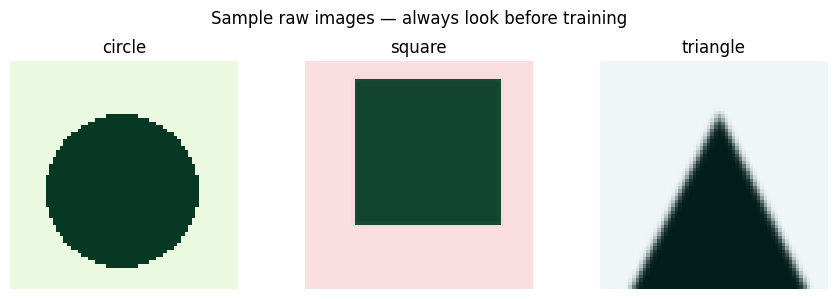

In [ ]:
# Peek at actual images — always visually inspect raw data before training
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, cls in zip(axes, CLASSES):
    sample_file = os.listdir(f'{RAW_DIR}/{cls}')[0]
    img = Image.open(f'{RAW_DIR}/{cls}/{sample_file}')
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis('off')
plt.suptitle('Sample raw images — always look before training')
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — TRANSFORMS: DIFFERENT FOR TRAIN vs VAL  ⭐ COMMON GOTCHA
# ═══════════════════════════════════════════════════════════════════════════


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # ⭐ MANDATORY in production. Client images are NEVER a consistent size.
    # Every tensor in a batch must have the same dimensions to stack together.

    transforms.RandomHorizontalFlip(p=0.5),
    # Randomly flip 50% of images left-right during training.
    # WHY: artificially doubles effective dataset diversity.
    # Only makes sense if flipping doesn't change the label —
    # fine for shapes, WRONG for tasks like reading text in images.

    transforms.RandomRotation(degrees=15),
    # Randomly rotate up to ±15°. Real photos are never perfectly aligned.
    # Teaches the model rotation isn't what defines the class.

    transforms.ColorJitter(brightness=0.21, contrast=0.23, saturation=0.2),
    # Randomly vary brightness/contrast/saturation.
    # Real cameras/lighting conditions vary — this simulates that.

    transforms.ToTensor(),
    # PIL image (0-255 unit 8) -> torch.Tensor(0.0-1.0 float32)
    #Also reorders (h,w,c) -> (c,h,w) - pytorchs expected formate

    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    # ImageNet's precomputed mean/std per RGB channel.
    # ⭐ USE THESE EXACT NUMBERS if you plan to use a pretrained model
    # (transfer learning — Module 18 territory). If training from scratch
    # on very different images, computing your OWN dataset mean/std is
    # slightly better, but ImageNet stats are a safe, standard default.
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
    # ⭐ NO augmentation here. Val/test data should reflect what the model
    # will actually see in production — not artificially altered versions.
    # Augmenting validation data gives you an unrealistic (usually worse
    # and noisier) estimate of real performance.
])

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — BUILD DATASETS + SPLIT  ⭐ THE TRANSFORM-LEAK GOTCHA
# ═══════════════════════════════════════════════════════════════════════════
# ImageFolder reads the class-per-folder structure automatically.
# GOTCHA: if you create ONE ImageFolder with train_transform and then
# random_split it, your "validation" subset still has augmentation applied
# every time you access it — silently corrupting your val metric.
# Fix: create TWO ImageFolder instances (different transforms), split by
# INDEX using the same random seed, then use Subset to select from each.

full_dataset_notransform = datasets.ImageFolder(RAW_DIR)
# No transform yet — just used to get consistent indices and class info.

class_names = full_dataset_notransform.classes
# ⭐ CRITICAL: this list defines index→classname mapping.
# class_names[0] = 'circle', etc. (alphabetical by default)
# You MUST save this list alongside your trained model — at inference
# time you need it to convert the model's output index back to a label.
print(f"\nClass name → index mapping: {full_dataset_notransform.class_to_idx}")

n_total = len(full_dataset_notransform)
n_val   = int(0.2 * n_total)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(
    range(n_total), [n_train,n_val], generator = generator
)

train_dataset_full = datasets.ImageFolder(RAW_DIR, transform = train_transform)
val_dataset_full = datasets.ImageFolder(RAW_DIR, transform = val_transform)

train_dataset = torch.utils.data.Subset(train_dataset_full, train_indices.indices)
val_dataset   = torch.utils.data.Subset(val_dataset_full, val_indices.indices)
# Subset picks specific indices from a dataset without copying data.
# train_dataset uses train_transform (augmented).
# val_dataset uses val_transform (clean) — even though same underlying files.

print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")



Class name → index mapping: {'circle': 0, 'square': 1, 'triangle': 2}
Train size: 544 | Val size: 136


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — HANDLE CLASS IMBALANCE: WEIGHTED SAMPLER
# ═══════════════════════════════════════════════════════════════════════════
# Same principle as Module 10's class_weight='balanced' — but for images,
# you weight the SAMPLER (which images get picked into each batch) rather
# than the loss function directly. Both approaches exist; sampler-based
# is very common for image classification.

# Count samples per class WITHIN the training split only
train_labels = [train_dataset_full.targets[i] for i in train_indices.indices]
class_sample_counts = np.bincount(train_labels)
print(f"\nTraining samples per class: "
      f"{dict(zip(class_names, class_sample_counts))}")

class_weights = 1.0 / class_sample_counts
# Rare classes (triangle, fewer images) get a LARGER weight.
# Common classes (circle, square) get a SMALLER weight.

sample_weights = [class_weights[label] for label in train_labels]
# One weight per individual training sample, based on its class.

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    # How many samples to draw per epoch — same as dataset size, but now
    # rare-class images get pulled MORE OFTEN (with replacement) so every
    # batch sees a more balanced mix of classes.
    replacement=True
    # Must be True — otherwise you can't oversample the rare class beyond
    # its actual count.
)


Training samples per class: {'circle': np.int64(247), 'square': np.int64(239), 'triangle': np.int64(58)}


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — DATALOADERS
# ═══════════════════════════════════════════════════════════════════════════

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    # ⭐ Using sampler= instead of shuffle=True.
    # These are mutually exclusive in PyTorch — sampler already handles
    # the randomization AND the class balancing in one step.
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,   # order doesn't matter for evaluation
    num_workers=2
)


In [ ]:
class ProductionCNN(nn.Module):
    def __init__(self, n_classes: int, in_channels: int = 3):
        super().__init__()
        # super().__init__() — always the first line. Sets up PyTorch's
        # internal bookkeeping so it can track all the learnable weights
        # you're about to define below.

        # ── LAYER 1 ──────────────────────────────────────────────────────
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        # in_channels=3   → input has 3 channels (R, G, B)
        # out_channels=32 → LEARN 32 different filters, so output has
        #                    32 channels (32 different "feature maps")
        # kernel_size=3   → each filter is a 3x3 grid of learnable numbers
        # padding=1       → add a 1-pixel border of zeros around the image
        #                    before sliding the filter. WHY: without this,
        #                    the output would shrink slightly every conv
        #                    layer (edges get "used up"). padding=1 with
        #                    kernel_size=3 keeps the output the SAME size
        #                    as the input: 64x64 in → 64x64 out.
        # Shape after this line: (32, 64, 64) — 32 channels now, still 64x64.

        self.bn1 = nn.BatchNorm2d(32)
        # Rescales the 32 feature maps to have a stable, consistent range
        # of values — same purpose as StandardScaler (Module 6), applied
        # to the numbers flowing THROUGH the network instead of raw input
        # data. Makes training faster and more stable. Shape unchanged: (32, 64, 64)

        # ── LAYER 2 ──────────────────────────────────────────────────────
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Input now has 32 channels (from conv1's output).
        # Learn 64 NEW filters — each of these looks at ALL 32 input
        # channels simultaneously and combines them into one output value.
        # This is how layer 2 learns COMBINATIONS of layer 1's features —
        # e.g. "edge + edge = corner".
        # Shape after this line: (64, 64, 64)

        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # We'll USE this same pooling layer twice in forward(). Each time
        # it's applied: takes the max value in every 2x2 block (see the
        # FUNDAMENTALS section above for a worked example), which HALVES
        # both height and width. 64x64 → 32x32 after one application.

        # ── LAYER 3 ──────────────────────────────────────────────────────
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # Input has 64 channels. Learn 128 new filters.
        # These deeper filters combine LAYER 2's combinations — learning
        # even more complex patterns (parts of shapes, textures).

        self.bn3 = nn.BatchNorm2d(128)

        # ── TRACING THE EXACT SIZE, STEP BY STEP ────────────────────────
        # Start:          (3,   64, 64)   ← original image
        # after conv1+bn1+relu:  (32,  64, 64)  ← padding kept size same
        # after pool:            (32,  32, 32)  ← pooling halved it
        # after conv2+bn2+relu:  (64,  32, 32)  ← padding kept size same
        # after pool:            (64,  16, 16)  ← pooling halved it AGAIN
        # after conv3+bn3+relu:  (128, 16, 16)  ← padding kept size same
        #                                          (no pool after conv3
        #                                           in this architecture)
        #
        # FLATTEN this final (128, 16, 16) block into one long row:
        #   128 × 16 × 16 = 32,768 numbers in a row
        # This exact number — 32,768 — MUST match nn.Linear's first
        # argument below, or PyTorch throws a shape-mismatch error.

        self.fc1 = nn.Linear(128 * 16 * 16, 128)
        # in_features  = 32,768  (the flattened size we just calculated)
        # out_features = 128     (a design choice — compress down to 128
        #                          numbers that summarize the whole image)

        self.fc2 = nn.Linear(128, n_classes)
        # Final layer: 128 numbers in → n_classes numbers out.
        # For our 3 shapes: n_classes=3, so this outputs 3 raw scores,
        # one per class — same idea as Module 2's logistic regression,
        # just generalized to more than 2 classes (this is what softmax/
        # CrossEntropyLoss will interpret as "how confident for each class").

        self.dropout = nn.Dropout(0.5)
        # Randomly zeroes 50% of the 128 values from fc1 during training
        # only (see FUNDAMENTALS above). Helps prevent overfitting.

    def forward(self, x):
        """
        x starts as shape (batch_size, 3, 64, 64) — a whole BATCH of
        images stacked together, not just one. Everything below happens
        to all images in the batch simultaneously.
        """
        # ── BLOCK 1: convolve → normalize → activate → shrink ───────────
        x = self.conv1(x)                  # (batch, 3, 64, 64) → (batch, 32, 64, 64)
        x = self.bn1(x)                     # shape unchanged, values rescaled
        x = F.relu(x)                       # negative values → 0, positives unchanged
        x = self.pool(x)                    # (batch, 32, 64, 64) → (batch, 32, 32, 32)

        # ── BLOCK 2 ────────────────────────────────────────────────────
        x = F.relu(self.bn2(self.conv2(x))) # (batch, 32,32,32) → (batch, 64,32,32)
        x = self.pool(x)                    # (batch, 64,32,32) → (batch, 64,16,16)

        # ── BLOCK 3 (no pool after this one) ─────────────────────────────
        x = F.relu(self.bn3(self.conv3(x))) # (batch, 64,16,16) → (batch, 128,16,16)

        # ── FLATTEN: turn the (128,16,16) cube into a flat row of numbers ─
        x = x.view(x.size(0), -1)
        # x.size(0) = batch size — keep this dimension as-is (don't flatten
        # across different images, only flatten WITHIN each image).
        # -1 tells PyTorch "figure out this dimension automatically" —
        # it computes 128*16*16 = 32768 for you.
        # Shape: (batch, 128, 16, 16) → (batch, 32768)

        # ── DENSE (LINEAR) LAYERS — same as every model since Module 1 ──
        x = F.relu(self.fc1(x))             # (batch, 32768) → (batch, 128)
        x = self.dropout(x)                 # same shape, some values zeroed
        x = self.fc2(x)                     # (batch, 128) → (batch, n_classes)
        # These are RAW SCORES ("logits") — not probabilities yet.
        # CrossEntropyLoss (used below) applies softmax internally to turn
        # these into probabilities during training — same trick as
        # Module 2's sigmoid, generalized to multiple classes.

        return x


Training on: cpu
Epoch  1 | Train loss: 2.1716 acc:  65.6% | Val loss: 0.1597 acc:  91.9%
  ✓ New best model saved (val_acc=91.9%)
Epoch  2 | Train loss: 0.4101 acc:  86.0% | Val loss: 0.1400 acc:  97.1%
  ✓ New best model saved (val_acc=97.1%)
Epoch  3 | Train loss: 0.1591 acc:  92.8% | Val loss: 0.0065 acc: 100.0%
  ✓ New best model saved (val_acc=100.0%)
Epoch  4 | Train loss: 0.0662 acc:  97.4% | Val loss: 0.0008 acc: 100.0%
Epoch  5 | Train loss: 0.0809 acc:  97.2% | Val loss: 0.0286 acc: 100.0%
Epoch  6 | Train loss: 0.0297 acc:  99.3% | Val loss: 0.0000 acc: 100.0%
Epoch  7 | Train loss: 0.0116 acc:  99.6% | Val loss: 0.0000 acc: 100.0%
Epoch  8 | Train loss: 0.0066 acc:  99.8% | Val loss: 0.0000 acc: 100.0%
  Early stopping — no improvement for 5 epochs

Best validation accuracy: 100.0%


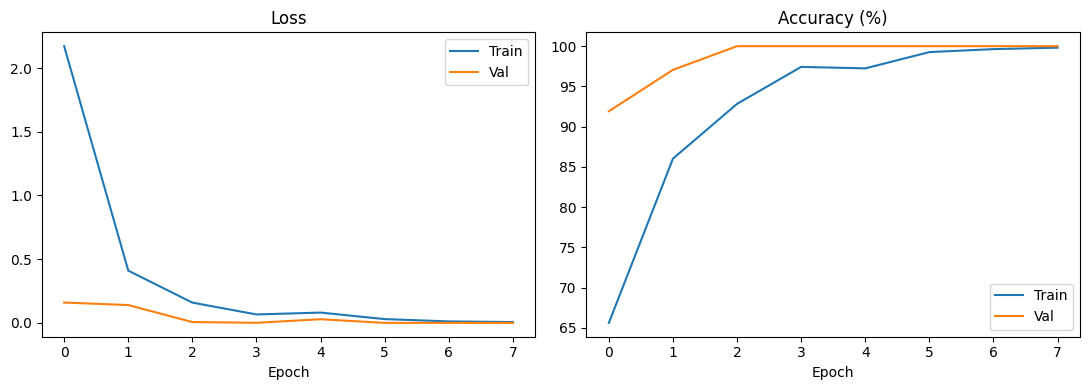

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — TRAINING LOOP WITH CHECKPOINTING
# ═══════════════════════════════════════════════════════════════════════════
# This loop is IDENTICAL in structure to every training loop since
# Module 4/16: zero_grad → forward → loss → backward → clip → step.
# The only new thing here is WHICH model architecture is being trained.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nTraining on: {device}")

model = ProductionCNN(n_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
# CrossEntropyLoss: same loss function from Module 2's logistic regression,
# generalized to more than 2 classes. Internally applies softmax to the
# model's raw output scores, then computes how wrong the prediction was.

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_acc = 0.0
patience = 5
patience_counter = 0
CHECKPOINT_PATH = '/content/best_cnn_model.pt'
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
N_EPOCHS = 20

for epoch in range(N_EPOCHS):
    model.train()
    # model.train() → turns dropout ON and makes BatchNorm use THIS
    # batch's statistics. Always call before training.

    train_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear old gradients (Module 16 recap)
        outputs = model(images)        # run the forward() method above
        loss = criterion(outputs, labels)
        loss.backward()                # compute gradients for every weight
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()               # update every weight using Adam

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        # outputs.max(1) → for each image, find which of the n_classes
        # scores is highest. That index IS the predicted class.
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    train_acc = 100. * correct / total
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    # model.eval() → turns dropout OFF (use the full network) and makes
    # BatchNorm use its stored running statistics instead of this batch's.
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        # No gradient tracking needed during evaluation — saves memory,
        # runs faster. We're not calling .backward() here.
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total   += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100. * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1:2d} | Train loss: {avg_train_loss:.4f} acc: {train_acc:5.1f}% | "
          f"Val loss: {avg_val_loss:.4f} acc: {val_acc:5.1f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({'model_state_dict': model.state_dict(),
                    'class_names': class_names, 'val_acc': val_acc}, CHECKPOINT_PATH)
        print(f"  ✓ New best model saved (val_acc={val_acc:.1f}%)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"  Early stopping — no improvement for {patience} epochs")
            break

print(f"\nBest validation accuracy: {best_val_acc:.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.show()


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      circle       1.00      1.00      1.00        53
      square       1.00      1.00      1.00        61
    triangle       1.00      1.00      1.00        22

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



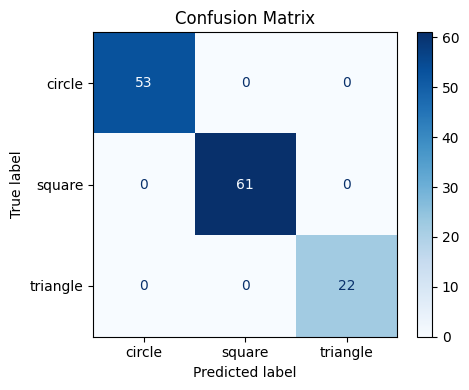

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — EVALUATE WITH REAL METRICS
# ═══════════════════════════════════════════════════════════════════════════

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 — INFERENCE ON A SINGLE NEW RAW IMAGE
# ═══════════════════════════════════════════════════════════════════════════

def predict_single_image(image_path: str, model, class_names, device):
    model.eval()
    img = Image.open(image_path).convert('RGB')
    inference_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    img_tensor = inference_transform(img).unsqueeze(0)
    # unsqueeze(0): a single image is shape (3, 64, 64), but the model
    # expects a BATCH — even a batch of 1. This adds that extra dimension:
    # (3, 64, 64) → (1, 3, 64, 64)
    img_tensor = img_tensor.to(device)

    with torch.no_grad():
        logits = model(img_tensor)
        probs = F.softmax(logits, dim=1)
        # softmax turns the raw scores into probabilities that sum to 1 —
        # same formula from Module 4's softmax explanation.
        confidence, predicted_idx = probs.max(1)

    predicted_class = class_names[predicted_idx.item()]
    return predicted_class, confidence.item()

test_image_path = f'{RAW_DIR}/triangle/triangle_0005.png'
predicted_class, confidence = predict_single_image(test_image_path, model, class_names, device)
print(f"\n=== SINGLE IMAGE INFERENCE ===")
print(f"Predicted: {predicted_class}  (confidence: {confidence:.1%})")


=== SINGLE IMAGE INFERENCE ===
Predicted: triangle  (confidence: 100.0%)


# **LSTM**

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 17 — LSTM — SAME CODE, PROPERLY EXPLAINED THIS TIME
═══════════════════════════════════════════════════════════════════════════
Every operation (Embedding, LSTM, hidden states, bidirectional) explained
with real numbers before you see it in code. Read FUNDAMENTALS first.
═══════════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────┐
│ FUNDAMENTALS — READ THIS BEFORE ANYTHING ELSE                            │
└─────────────────────────────────────────────────────────────────────────┘

WHAT IS AN EMBEDDING LAYER (nn.Embedding)?
A model can't read words — it only reads numbers. So every word first
gets converted to a single integer ("this word is #482 in my vocabulary").
But a single integer carries no meaning by itself — #482 isn't "more" or
"less" than #100 in any useful sense. So nn.Embedding is just a big LOOKUP
TABLE: index in, vector out.
    vocab_size=5000, embed_dim=100
    → the table has 5000 rows, each row is a list of 100 numbers
    → word index 482 → look up row 482 → get back a 100-number vector
These 100 numbers START random and get LEARNED during training — words
used in similar contexts end up with similar vectors (same idea as
Module 17.6's embeddings, just learned as part of THIS model instead of
a separately pretrained one).

WHAT DOES AN LSTM ACTUALLY DO?
Reads a sequence of vectors ONE AT A TIME, left to right (word 1, then
word 2, then word 3...). At each step it keeps a running "memory" called
the HIDDEN STATE — a fixed-size vector summarizing everything relevant
seen SO FAR. After reading the last word, the FINAL hidden state is meant
to summarize the meaning of the whole sentence.
    "The movie was" → hidden state so far: "positive-ish setup..."
    "The movie was terrible" → hidden state updates: "negative sentiment"
You don't need to know the internal gate math to USE an LSTM in code —
you already learned that math in Module 17's theory (forget gate, input
gate, cell state). Here we just care about the SHAPES going in and out.

WHAT DOES "BIDIRECTIONAL=TRUE" MEAN?
A normal LSTM only reads left-to-right. But context can come from EITHER
direction — "bank" in "river bank" vs "bank account" depends on what
comes AFTER it too. bidirectional=True runs TWO LSTMs simultaneously:
one reading the sentence forward, one reading it backward. At the end you
get TWO final hidden states (forward's and backward's) — code below
concatenates (glues) them together side by side.

WHAT SHAPE IS THE HIDDEN STATE?
hidden.shape = (num_layers * num_directions, batch_size, hidden_dim)
For this code: num_layers=1, bidirectional → num_directions=2
    hidden.shape = (2, batch_size, 128)
    hidden[0] = forward direction's final hidden state
    hidden[1] = backward direction's final hidden state
(With more layers, e.g. num_layers=2, you'd get 4 entries: layer1-forward,
layer1-backward, layer2-forward, layer2-backward — indexed [-2] and [-1]
always grab the LAST layer's forward and backward states, whatever the
layer count.)

WHY CONCATENATE hidden[-2] AND hidden[-1]?
We want ONE vector that captures BOTH directions' understanding of the
sentence. torch.cat glues two vectors end to end:
    forward_hidden:  128 numbers  → [0.2, -0.5, ... ] (128 values)
    backward_hidden: 128 numbers  → [0.1,  0.8, ... ] (128 values)
    concatenated:    256 numbers  → [0.2, -0.5, ..., 0.1, 0.8, ...]
This is why the final Linear layer expects hidden_dim*2 = 256 inputs,
not just 128 — it needs room for BOTH directions' information.

WHY DO SENTENCES NEED PADDING?
Real sentences have different lengths. "great" is 1 word. "this product
completely exceeded my expectations" is 6 words. But a batch (a chunk of
several sentences processed together) needs every sentence to be the
SAME length so they can be stacked into one tensor. PADDING fills short
sentences with a filler token (index 0, "<pad>") until they match the
longest sentence IN THAT BATCH:
    "great"                    → [45,  0,  0,  0,  0,  0]   (padded with 0s)
    "this product completely.." → [12, 88, 34, 91, 6, 200]  (already full length)
The model is told (via padding_idx=0) to treat that padding as
meaningless — it doesn't count toward the sentence's real content.

┌─────────────────────────────────────────────────────────────────────────┐
│ Now the same production code as before, same behavior, but every line   │
│ traced through with actual shapes and numbers.                          │
└─────────────────────────────────────────────────────────────────────────┘
"""

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 — SIMULATE RAW DATA (unrelated to LSTM theory — just test data)
# ═══════════════════════════════════════════════════════════════════════════

positive_templates = [
    "This product is AMAZING!! Best purchase I've made all year :)",
    "absolutely loved it, works perfectly and arrived early",
    "Great quality, highly recommend to anyone looking for this",
    "5 stars, exceeded my expectations completely.",
    "works great, no complaints at all, will buy again!!",
    "I'm so happy with this purchase, exactly what I needed",
    "excellent product, fast shipping, very satisfied customer here",
    "This is fantastic - can't believe how well it works!",
]
negative_templates = [
    "Terrible product, broke after 2 days. DO NOT BUY.",
    "waste of money, doesn't work as advertised at all",
    "very disappointed, poor quality and slow shipping",
    "This is the worst purchase I've ever made, avoid!!",
    "not worth it, stopped working within a week smh",
    "horrible experience, product arrived damaged and customer service unhelpful",
    "1 star. complete garbage, asking for a refund",
    "disappointing quality, would not recommend to anyone",
]
neutral_templates = [
    "It's okay, does the job but nothing special",
    "average product for the price, works as expected",
    "decent quality, might buy again if on sale",
    "It's fine I guess, not amazing but not terrible either",
]

def generate_raw_reviews(n=1500):
    rows = []
    labels_pool = (['positive'] * 700 + ['negative'] * 300 + ['neutral'] * 500)
    random.shuffle(labels_pool)
    for label in labels_pool[:n]:
        if label == 'positive':
            text = random.choice(positive_templates)
        elif label == 'negative':
            text = random.choice(negative_templates)
        else:
            text = random.choice(neutral_templates)
        if np.random.rand() < 0.15:
            text += " <br/>"
        if np.random.rand() < 0.1:
            text = text.replace("product", "produtc")
        if np.random.rand() < 0.2:
            text = text + "!" * np.random.randint(0, 4)
        rows.append({'review_text': text, 'sentiment': label})
    return pd.DataFrame(rows)

df_raw = generate_raw_reviews(n=1500)
print("=== RAW DATA GENERATED ===")
print(df_raw.head(5).to_string())

df_raw['label'] = (df_raw['sentiment'] == 'positive').astype(int)
# We'll predict: is this review POSITIVE (1) or not (0)?




=== RAW DATA GENERATED ===
                                                    review_text sentiment
0                   It's okay, does the job but nothing special   neutral
1         works great, no complaints at all, will buy again!!!!  positive
2         works great, no complaints at all, will buy again!!!!  positive
3  I'm so happy with this purchase, exactly what I needed <br/>  positive
4     absolutely loved it, works perfectly and arrived early!!!  positive


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — TEXT CLEANING
# ═══════════════════════════════════════════════════════════════════════════
# Real text is messy. We clean it before the model ever sees it —
# same principle as Module 6's data cleaning, applied to sentences.


def clean_text(text: str) -> str:
    text = text.lower()
    # Convert everything to lowercase: "Great" -> "great"

    text = re.sub(r'<[^>]+>', ' ', text)
    # Remove HTML tags like <br>, <p>, <div>

    text = re.sub(r"n't", " not", text)
    # Expand contractions: "don't" -> "do not"

    text = re.sub(r"'re", " are", text)
    # "you're" -> "you are"

    text = re.sub(r"'s", " is", text)
    # "it's" -> "it is"

    text = re.sub(r"'ll", " will", text)
    # "I'll" -> "I will"

    text = re.sub(r"'ve", " have", text)
    # "I've" -> "I have"

    text = re.sub(r'[^a-z\s]', ' ', text)
    # Remove everything except letters (a-z) and spaces.

    text = re.sub(r'\s+', ' ', text).strip()
    # Replace multiple spaces with one and remove spaces at the ends.

    return text

df_raw['clean_text'] = df_raw['review_text'].apply(clean_text)
print("\n=== BEFORE vs AFTER CLEANING ===")
print(f"Raw:   {df_raw['review_text'].iloc[0]}")
print(f"Clean: {df_raw['clean_text'].iloc[0]}")



=== BEFORE vs AFTER CLEANING ===
Raw:   It's okay, does the job but nothing special
Clean: it is okay does the job but nothing special


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — TOKENIZATION (splitting a sentence into a list of words)
# ═══════════════════════════════════════════════════════════════════════════


def tokenize(text: str) -> list:
    """"this is great" → ["this", "is", "great"] — just a space-split."""
    return text.split()

df_raw['tokens'] = df_raw['clean_text'].apply(tokenize)
print(f"\nExample: {df_raw['clean_text'].iloc[7]}")
print(f"Tokens:  {df_raw['tokens'].iloc[7]}")


Example: this is fantastic ca not believe how well it works
Tokens:  ['this', 'is', 'fantastic', 'ca', 'not', 'believe', 'how', 'well', 'it', 'works']


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — BUILD A VOCABULARY (word → number lookup table)
# ═══════════════════════════════════════════════════════════════════════════
# The model needs every unique word converted to a unique NUMBER.
# This section builds that word→number dictionary from the TRAINING data only.


train_df, val_df = train_test_split(df_raw, test_size= 0.2, stratify = df_raw['label'], random_state=42)

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")


def build_vocab(token_lists, min_freq=2):
    counter = Counter()
    for tokens in token_lists:
        counter.update(tokens)
    # counter now holds: {"great": 340, "terrible": 12, "the": 890, ...}
    vocab = {'<pad>':0, '<unk>': 1}
    # index 0 is ALWAYS reserved for padding (filler for short sentences)
    # index 1 is ALWAYS reserved for "unknown word" (a word never seen
    # during training — will happen with real new user input)

    for word, count in counter.most_common():
        if count >= min_freq:
            # Skip words seen fewer than 2 times — too rare to learn
            # anything useful about, just wastes vocabulary space.
            vocab[word] = len(vocab)
            # Assigns the NEXT available number: 2, 3, 4, 5...

    return vocab

vocab = build_vocab(train_df['tokens'], min_freq=2)
print(f"\nVocabulary size: {len(vocab)}")
print(f"Example entries: {dict(list(vocab.items()))}")



Train: 1200 | Val: 300

Vocabulary size: 115
Example entries: {'<pad>': 0, '<unk>': 1, 'not': 2, 'it': 3, 'is': 4, 'i': 5, 'this': 6, 'works': 7, 'product': 8, 'quality': 9, 'for': 10, 'the': 11, 'but': 12, 'buy': 13, 'amazing': 14, 'purchase': 15, 'again': 16, 'all': 17, 'and': 18, 'as': 19, 'great': 20, 'terrible': 21, 'arrived': 22, 'does': 23, 'fine': 24, 'guess': 25, 'either': 26, 'average': 27, 'price': 28, 'expected': 29, 'decent': 30, 'might': 31, 'if': 32, 'on': 33, 'sale': 34, 'have': 35, 'made': 36, 'recommend': 37, 'to': 38, 'anyone': 39, 'customer': 40, 'fantastic': 41, 'ca': 42, 'believe': 43, 'how': 44, 'well': 45, 'at': 46, 'shipping': 47, 'very': 48, 'okay': 49, 'job': 50, 'nothing': 51, 'special': 52, 'm': 53, 'so': 54, 'happy': 55, 'with': 56, 'exactly': 57, 'what': 58, 'needed': 59, 'absolutely': 60, 'loved': 61, 'perfectly': 62, 'early': 63, 'best': 64, 'year': 65, 'a': 66, 'highly': 67, 'looking': 68, 'no': 69, 'complaints': 70, 'will': 71, 'stars': 72, 'exceeded

In [ ]:
VOCAB_SIZE = len(vocab)
PAD_IDX = vocab['<pad>']   # = 0
UNK_IDX = vocab['<unk>']   # = 1


def tokens_to_indices(tokens: list, vocab: dict) -> list:
    """["this", "is", "great"] → [12, 5, 88] (each word's number)"""
    return [vocab.get(tok, vocab['<unk>']) for tok in tokens]
    # .get(word, unk_idx) → if the word IS in our vocabulary, return its
    # number. If NOT (a word we've never seen), return 1 (<unk>) instead
    # of crashing.

train_df['indices'] = train_df['tokens'].apply(lambda t: tokens_to_indices(t, vocab))
val_df['indices']   = val_df['tokens'].apply(lambda t: tokens_to_indices(t, vocab))

print(f"\nExample conversion:")
print(f"Words:   {train_df['tokens'].iloc[0]}")
print(f"Numbers: {train_df['indices'].iloc[0]}")



Example conversion:
Words:   ['stars', 'exceeded', 'my', 'expectations', 'completely']
Numbers: [72, 73, 74, 75, 76]


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — CUSTOM DATASET (wraps our data for PyTorch)
# ═══════════════════════════════════════════════════════════════════════════


class ReviewDataset(Dataset):
    """
    A thin wrapper so PyTorch's DataLoader knows how to grab one
    review at a time. Every review is still a DIFFERENT LENGTH here —
    padding to equal length happens later, per-batch, in collate_fn.
    """
    def __init__(self, indices_list, labels):
        self.indices_list = indices_list
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Called once per review when DataLoader needs it.
        indices = torch.tensor(self.indices_list.iloc[idx], dtype=torch.long)
        # e.g. tensor([12, 5, 88]) — one review's word numbers
        label = torch.tensor(self.labels.iloc[idx], dtype=torch.float32)
        # 1.0 (positive) or 0.0 (not positive)
        return indices, label

train_dataset = ReviewDataset(train_df['indices'], train_df['label'])
val_dataset   = ReviewDataset(val_df['indices'],   val_df['label'])

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — collate_fn: PADDING SENTENCES TO EQUAL LENGTH PER BATCH
# ═══════════════════════════════════════════════════════════════════════════
# DataLoader normally can't combine reviews of different lengths into one
# batch tensor — this function tells it exactly HOW to do that: pad every
# review in THIS batch to match the longest one, just in this batch.

def collate_fn(batch):
    """
    batch = a list like [(review1_indices, label1), (review2_indices, label2), ...]
    for however many reviews are in one batch (32 here).
    """
    indices_list, labels = zip(*batch)
    # Separates the list of (indices, label) pairs into two lists:
    # all the indices sequences, and all the labels.

    lengths = torch.tensor([len(seq) for seq in indices_list])
    # Remember each review's TRUE length before we pad it — e.g. [3, 6, 1, 4, ...]

    padded = pad_sequence(indices_list, batch_first=True, padding_value=PAD_IDX)
    # Finds the LONGEST review in this specific batch, pads every shorter
    # one with 0s (PAD_IDX) at the end until they all match that length.
    # Example with 3 reviews of length 3, 6, 1:
    #   [12, 5, 88, 0, 0, 0]   ← padded from length 3 to 6
    #   [4, 90, 3, 21, 8, 55]  ← already length 6, unchanged
    #   [200, 0, 0, 0, 0, 0]   ← padded from length 1 to 6
    # Shape: (batch_size, longest_length_in_this_batch)

    labels = torch.stack(labels)
    # Combines the individual label numbers into one batch tensor.

    return padded, lengths, labels

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

sample_padded, sample_lengths, sample_labels = next(iter(train_loader))
print(f"\n=== ONE BATCH, ACTUAL SHAPES ===")
print(f"Padded batch shape: {sample_padded.shape}  ← (32 reviews, longest one in this batch)")
print(f"First 5 true lengths (before padding): {sample_lengths[:5].tolist()}")




=== ONE BATCH, ACTUAL SHAPES ===
Padded batch shape: torch.Size([32, 11])  ← (32 reviews, longest one in this batch)
First 5 true lengths (before padding): [7, 11, 8, 11, 10]


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — THE LSTM MODEL, TRACED WITH REAL SHAPES
# ═══════════════════════════════════════════════════════════════════════════

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128,
                 n_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        # A lookup table: vocab_size rows (one per word we know),
        # embed_dim=100 columns (each word becomes a 100-number vector).
        # padding_idx=pad_idx → word index 0 (<pad>) ALWAYS maps to a
        # vector of all zeros, AND is never updated during training —
        # the model correctly learns to treat padding as "nothing here".

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            # Each timestep's input is one word's 100-number embedding vector.

            hidden_size=hidden_dim,
            # The "memory" vector size — 128 numbers summarize everything
            # read so far at any point in the sentence.

            num_layers=n_layers,
            # Stack just 1 LSTM here (n_layers=1). More layers = more
            # capacity but harder/slower to train — 1 is a reasonable start.

            batch_first=True,
            # Tells PyTorch our data is shaped (batch, seq_len, features) —
            # matches the shape our embedding layer produces.

            bidirectional=True,
            # Read the sentence BOTH forward and backward (see FUNDAMENTALS
            # above). Produces TWO hidden states instead of one.

            dropout=dropout if n_layers > 1 else 0
            # Only applies between STACKED layers — irrelevant here since
            # we only have 1 layer, but harmless to leave in.
        )

        self.fc = nn.Linear(hidden_dim * 2, 1)
        # hidden_dim * 2 = 256 → because bidirectional gives us TWO
        # 128-number hidden states (forward + backward) that get
        # concatenated into one 256-number vector (see FUNDAMENTALS).
        # Output = 1 number: a raw score for "how positive is this review".

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, lengths):
        """
        x shape coming in: (batch_size, seq_len) — e.g. (32, 6) for a
        batch of 32 reviews, each padded to 6 words long. These are
        WORD NUMBERS, not yet vectors.
        """
        embedded = self.dropout(self.embedding(x))
        # self.embedding(x): looks up each word number's 100-number vector.
        # Shape: (batch, seq_len) → (batch, seq_len, embed_dim)
        #        (32, 6)          → (32, 6, 100)
        # Every single word number is now a 100-number vector instead.

        lstm_out, (hidden, cell) = self.lstm(embedded)
        # Feeds the whole sequence through the LSTM, one word-vector at
        # a time internally. Returns THREE things:
        #   lstm_out → hidden state at EVERY timestep (we don't use this here)
        #   hidden   → the FINAL hidden state (what we actually want)
        #   cell     → the FINAL cell state (internal LSTM memory, not
        #              needed for classification, only the LSTM uses it
        #              internally)
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        #             = (1 * 2, 32, 128) = (2, 32, 128)
        #   hidden[0] = forward direction's final summary of the sentence
        #   hidden[1] = backward direction's final summary of the sentence

        hidden_cat = torch.cat([hidden[-2], hidden[-1]], dim=1)
        # hidden[-2] and hidden[-1] grab the LAST layer's forward and
        # backward states (with n_layers=1 here, that's simply hidden[0]
        # and hidden[1] — the [-2]/[-1] indexing style also works
        # correctly if you later increase n_layers).
        # hidden[-2] shape: (32, 128) — forward summary, one per review
        # hidden[-1] shape: (32, 128) — backward summary, one per review
        # torch.cat(..., dim=1): glue them side by side along dimension 1
        # Result shape: (32, 256) — one 256-number "sentence summary"
        # vector per review in the batch.

        out = self.fc(self.dropout(hidden_cat))
        # Linear layer: (32, 256) → (32, 1)
        # One raw score per review — how strongly "positive" it looks.

        return out.squeeze(1)
        # squeeze(1) removes the size-1 dimension: (32, 1) → (32,)
        # Just cleans up the shape to match what our loss function expects.



Training on: cpu
Class balance — pos: 560, neg: 640, pos_weight: 1.143
Epoch  1 | Train loss: 0.3592 | Val F1: 1.0000
Epoch  2 | Train loss: 0.0052 | Val F1: 1.0000
Epoch  3 | Train loss: 0.0012 | Val F1: 1.0000
Epoch  4 | Train loss: 0.0005 | Val F1: 1.0000
Epoch  5 | Train loss: 0.0003 | Val F1: 1.0000
Epoch  6 | Train loss: 0.0002 | Val F1: 1.0000
Epoch  7 | Train loss: 0.0002 | Val F1: 1.0000
Epoch  8 | Train loss: 0.0002 | Val F1: 1.0000
Epoch  9 | Train loss: 0.0002 | Val F1: 1.0000
Epoch 10 | Train loss: 0.0001 | Val F1: 1.0000
Epoch 11 | Train loss: 0.0001 | Val F1: 1.0000
Epoch 12 | Train loss: 0.0001 | Val F1: 1.0000
Epoch 13 | Train loss: 0.0001 | Val F1: 1.0000
Epoch 14 | Train loss: 0.0001 | Val F1: 1.0000
Epoch 15 | Train loss: 0.0001 | Val F1: 1.0000

Best validation F1: 1.0000

=== CLASSIFICATION REPORT ===
                  precision    recall  f1-score   support

negative/neutral       1.00      1.00      1.00       160
        positive       1.00      1.00      1.00

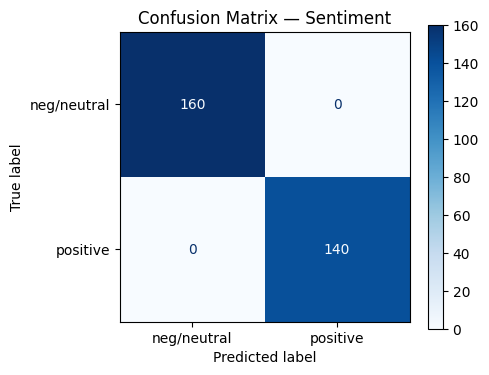

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 7 — TRAINING LOOP
# ═══════════════════════════════════════════════════════════════════════════
# Same 5-step loop as every model since Module 4/16:
# zero_grad → forward → loss → backward → step.

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nTraining on: {device}")

model = SentimentLSTM(vocab_size=VOCAB_SIZE, pad_idx=PAD_IDX).to(device)

n_pos = (train_df['label'] == 1).sum()
n_neg = (train_df['label'] == 0).sum()
pos_weight = torch.tensor([n_neg / n_pos]).to(device)
# If negatives outnumber positives, this makes the model pay MORE
# attention to getting positives right — same idea as sklearn's
# class_weight='balanced' from Module 10, just applied to this loss function.
print(f"Class balance — pos: {n_pos}, neg: {n_neg}, pos_weight: {pos_weight.item():.3f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# Binary Cross-Entropy — same loss from Module 2's logistic regression.
# "WithLogits" means it expects RAW scores (not yet passed through
# sigmoid) and applies sigmoid internally — more numerically stable.

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

best_val_f1 = 0.0
N_EPOCHS = 15

for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0.0

    for padded, lengths, labels in train_loader:
        padded, labels = padded.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(padded, lengths)   # calls forward() above
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Gradient clipping matters MORE for RNNs/LSTMs than CNNs —
        # the repeated multiplication through timesteps is exactly what
        # can cause gradients to explode (Module 4 recap).
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()

    model.eval()
    val_preds, val_labels_all = [], []
    with torch.no_grad():
        for padded, lengths, labels in val_loader:
            padded = padded.to(device)
            outputs = model(padded, lengths)
            probs = torch.sigmoid(outputs)
            # sigmoid squashes the raw score into a 0-1 probability
            # (Module 2 recap).
            preds = (probs >= 0.5).float().cpu()
            val_preds.extend(preds.numpy())
            val_labels_all.extend(labels.numpy())

    from sklearn.metrics import f1_score
    val_f1 = f1_score(val_labels_all, val_preds, zero_division=0)
    print(f"Epoch {epoch+1:2d} | Train loss: {train_loss/len(train_loader):.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save({'model_state_dict': model.state_dict(), 'vocab': vocab, 'val_f1': val_f1},
                   '/content/best_lstm_model.pt')

print(f"\nBest validation F1: {best_val_f1:.4f}")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 8 — FULL EVALUATION
# ═══════════════════════════════════════════════════════════════════════════

checkpoint = torch.load('/content/best_lstm_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(val_labels_all, val_preds, target_names=['negative/neutral', 'positive']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(val_labels_all, val_preds,
                                        display_labels=['neg/neutral', 'positive'], cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Sentiment')
plt.tight_layout()
plt.show()


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 9 — INFERENCE ON A BRAND NEW RAW SENTENCE
# ═══════════════════════════════════════════════════════════════════════════

def predict_sentiment(raw_text: str, model, vocab, device):
    """The exact same 4 steps as training: clean → tokenize → index → predict."""
    model.eval()
    cleaned = clean_text(raw_text)
    tokens = tokenize(cleaned)
    indices = tokens_to_indices(tokens, vocab)

    if len(indices) == 0:
        indices = [vocab['<unk>']]
        # Edge case: what if cleaning removed everything (e.g. input was
        # just emojis/numbers)? Fall back to a single <unk> token instead
        # of crashing on an empty list.

    indices_tensor = torch.tensor([indices], dtype=torch.long).to(device)
    # Wrapped in an outer list: shape (1, seq_len) — a "batch" of 1 review.
    lengths = torch.tensor([len(indices)])

    with torch.no_grad():
        logit = model(indices_tensor, lengths)
        prob = torch.sigmoid(logit).item()

    label = 'positive' if prob >= 0.5 else 'negative/neutral'
    return label, prob

test_sentences = [
    "This is honestly the best thing I've bought all year, love it!!",
    "Terrible quality, broke immediately, complete waste of money",
    "It's okay I suppose, does what it says on the box",
    "asdkjaslkdj",
]

print("\n=== SINGLE-SENTENCE INFERENCE ===")
for sentence in test_sentences:
    label, prob = predict_sentiment(sentence, model, vocab, device)
    print(f"\nText: \"{sentence}\"")
    print(f"Prediction: {label}  (confidence: {prob:.1%})")


=== SINGLE-SENTENCE INFERENCE ===

Text: "This is honestly the best thing I've bought all year, love it!!"
Prediction: positive  (confidence: 65.1%)

Text: "Terrible quality, broke immediately, complete waste of money"
Prediction: negative/neutral  (confidence: 1.3%)

Text: "It's okay I suppose, does what it says on the box"
Prediction: negative/neutral  (confidence: 5.5%)

Text: "asdkjaslkdj"
Prediction: negative/neutral  (confidence: 41.7%)


# Module 17 — Transformers & Attention
### The architecture behind every modern AI — explained simply, no symbol left unexplained

---

## Part 1 — Why Transformers Exist

You know RNNs and LSTMs. They read a sentence **one word at a time, left to right**. This causes two real problems.

**Problem 1 — the bottleneck.** The entire meaning of a sentence has to get squeezed into one hidden state vector by the time the LSTM reaches the last word. Imagine reading a 500-word paragraph, then closing the book and trying to answer questions purely from memory. Important details get lost along the way.

**Problem 2 — speed.** Word 10 must wait for word 9, which must wait for word 8. You can't skip ahead. On GPUs that can do millions of things at once, this one-at-a-time processing is painfully slow.

**Transformers fix both** with one idea: let every word look directly at every other word **at the same time**. No waiting. No bottleneck. This is called **attention**.

---

## Part 2 — The Attention Intuition (No Math Yet)

Read this sentence: *"The animal didn't cross the street because it was too tired."*

What does **"it"** refer to — the animal or the street? You instantly know: the animal. You connected "tired" back to "animal" without even thinking about it.

An LSTM has to carry "animal" forward through every single word until it reaches "it" — by then the signal has weakened.

**Attention says:** when the model processes "it", let it directly ask every other word "are you relevant to me?" — "animal" scores high, "street" scores low. The final meaning of "it" becomes a blend of all words, weighted by how relevant each one is.

---

## Part 3 — Q, K, V — The Math Made Simple

Every word gets turned into **three vectors**:

| Vector | Meaning (in plain words) |
|--------|--------------------------|
| **Q** (Query) | "What am I looking for?" |
| **K** (Key) | "What do I contain / advertise?" |
| **V** (Value) | "What information do I actually hand over if picked?" |

Think of a search engine: you type a **query**. It's compared against every page's **key** (title/description). Pages with matching keys score high. You get back the **value** (actual content) of the top matches.

**The formula:**

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) \times V$$

Breaking down every symbol:

- **$Q$** — the query vectors (what each word is looking for), stacked as a matrix
- **$K^\top$** ("K transpose") — the key vectors, laid sideways so we can multiply them against Q
- **$QK^\top$** — dot product between every query and every key. High number = query and key match well = pay more attention here
- **$d_k$** — the dimension size of the key vectors (just a number, like 64)
- **$\sqrt{d_k}$** — square root of that number, used only to divide and keep numbers from getting too big
- **softmax(...)** — turns raw scores into probabilities that sum to 1 (same softmax from Module 4)
- **$\times V$** — take the weighted average of all value vectors, using those probabilities as weights

**Why divide by $\sqrt{d_k}$?** When $d_k$ is large, the raw dot products get huge. Huge numbers going into softmax make it output almost all-0s-and-one-1 (like a light switch, not a dimmer). That kills the gradient — the model stops learning. Dividing keeps the numbers in a friendly range.

---

## Part 4 — Multi-Head Attention: Why One Isn't Enough

One attention "head" can only learn **one type of relationship**. In our tired-animal sentence, you actually need to track several things at once:

- **Coreference** — "it" → "animal"
- **Grammar** — "cross" is the verb belonging to "animal"
- **Meaning** — "tired" relates to "animal", not "street"

One set of Q/K/V can't specialize in all of these simultaneously. So transformers run **several attention heads in parallel** (commonly 8), each with its own Q/K/V weights, each free to learn a different kind of relationship. Their outputs get glued back together (concatenated) and passed through one more linear layer to mix information across heads.

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) \times W_O$$

- **$h$** — number of heads (e.g. 8)
- **$W_O$** — the final linear layer that mixes the heads back together

---

## Part 5 — Positional Encoding: Giving the Model a Sense of Order

Attention has **no built-in concept of word order**. "cat sat on mat" and "mat on sat cat" would look identical to raw attention — it only cares about content similarity, not position.

**Fix:** add a small "position fingerprint" vector to every word's embedding before it enters the transformer, so the model can tell positions apart.

The original paper used sine/cosine waves at different frequencies for this — you don't need to hand-derive this formula to use transformers day to day (in practice you'll usually load a pretrained model where this is already baked in), but the intuition matters: different dimensions oscillate at different speeds, together creating a unique "fingerprint" for every position, from 0 up to thousands.

**GPT-style models** instead just use a **learned positional embedding** — literally one trainable vector per position, exactly like a word embedding but for position instead of meaning. Simpler, and works just as well in practice.

---

## Part 6 — Encoder vs Decoder — BERT vs GPT

| | **Encoder (BERT)** | **Decoder (GPT)** |
|--|---------------------|---------------------|
| Attention direction | Bidirectional — sees the whole sentence at once | Causal — only sees past words, never future |
| Good at | Understanding: classification, extraction, search | Generation: writing, chat, completion |
| Trick used | None — full access to all words | **Causal mask** — hides future positions |

**The causal mask** is the only real architectural difference for GPT. It's a triangle of 1s and 0s — position $i$ can see positions $0$ through $i$, never anything after. Without it, GPT could "cheat" during training by peeking at the answer.

```
Position can see:
Row 0: [1, 0, 0, 0]   ← word 0 sees only itself
Row 1: [1, 1, 0, 0]   ← word 1 sees words 0-1
Row 2: [1, 1, 1, 0]   ← word 2 sees words 0-2
Row 3: [1, 1, 1, 1]   ← word 3 sees everything before it
```

---

## Part 7 — What You Actually Use in Production

Here's the honest truth for someone building real products: **you will almost never write `MultiHeadAttention` from scratch at a job.** That's a learning exercise (and a good one — you now understand what's happening inside every transformer you'll ever use). In production you:

1. **Load a pretrained model** from HuggingFace (`transformers` library) — a model someone already trained on billions of words
2. **Fine-tune it** on your own smaller dataset (thousands of examples, not billions)
3. **Or just use it directly** for inference with zero training, via `pipeline()`

This is exactly like Module 7's advice for tree models — you understand the Gini math, but you use sklearn's `RandomForestClassifier`, not your own hand-rolled tree splitter. Same principle here, one level up.

---

## Interview Questions, Answered

---

### Q: Why are transformers better than LSTMs?

Three reasons. **Parallelism** — transformers process every position at once; LSTMs are stuck going one step at a time, so transformers train much faster on modern GPUs. **Long-range dependencies** — attention connects any two words in one step regardless of distance; an LSTM has to carry information through every intervening timestep, where it degrades. **Scale** — transformers keep improving predictably as you add more data and parameters; LSTMs don't scale as cleanly.

---

### Q: What is the complexity of attention?

The attention score matrix is $(\text{seq\_len} \times \text{seq\_len})$, so both time and memory cost scale as $O(n^2)$. A 1,000-token document → 1 million attention scores. A 10,000-token document → 100 million. This is why very long documents are expensive for transformers, and why techniques like Flash Attention and sparse attention exist — they're optimizations around this exact bottleneck.

---

### Q: Encoder vs decoder transformer — what's the real difference?

Encoders (BERT) use **bidirectional** attention — every position sees every other position, in both directions. Great for understanding tasks: classification, extraction, search. Decoders (GPT) use **causal** attention — each position only sees the past. Great for generation. T5 and the original transformer paper use both (encoder to understand the input, decoder to generate the output).

---

## Always Remember

- **Attention = every word looking directly at every other word, weighted by relevance.** That's the entire idea. Everything else is engineering around this.
- **Q asks, K advertises, V delivers.** If you remember nothing else about the formula, remember this sentence.
- **Divide by $\sqrt{d_k}$** exists purely to stop softmax from saturating — a training-stability trick, not a deep theoretical requirement.
- **Multiple heads = multiple relationship types learned in parallel.** One head literally cannot learn everything at once.
- **Positional encoding exists because attention alone is blind to word order.**
- **Causal mask is the ONLY structural difference between BERT-style and GPT-style models.** Everything else is the same building block.
- **In real jobs: use `transformers` (HuggingFace), fine-tune a pretrained model.** Building attention from scratch is for understanding, not for shipping.
- **$O(n^2)$ cost** is why long documents are expensive — this is a real, practical constraint you'll hit, not just interview trivia.

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 17 — TRANSFORMERS — FULL BUILD, NOT JUST ONE HEAD
═══════════════════════════════════════════════════════════════════════════

Every piece below was actually run before being written down here — the
shapes, the numbers, the "does this really differ" checks. Nothing is
described without also being traced.

┌─────────────────────────────────────────────────────────────────────────┐
│ FUNDAMENTALS — READ THIS BEFORE ANYTHING ELSE                            │
└─────────────────────────────────────────────────────────────────────────┘

WHAT IS A TOKENIZER, REALLY?
A model can't read the word "invoice" — it only reads numbers. A tokenizer
is a lookup table that turns text into a list of integers, and back again.
    "hello world"  →  [7592, 2088]
Each number is just an INDEX into a table of ~30,000 known word pieces the
model was trained with. No magic.

WHAT DOES Q, K, V MEAN?
Every word gets 3 vectors: Query (what am I looking for), Key (what do I
advertise), Value (what do I hand over if picked). We compute how much
word A should attend to word B by comparing A's Query against B's Key —
a big dot product means "relevant". We then blend everyone's Values,
weighted by those relevance scores.

WHY MULTIPLE HEADS, NOT JUST ONE?
One attention computation forces every word to compress ALL the ways it
might relate to other words into a single weighted average. Splitting
into heads lets DIFFERENT heads specialize — empirically, some heads
learn short-range/syntactic patterns (adjacent words, subject-verb),
others learn long-range/semantic ones (pronoun ↔ its referent, three
sentences back). Part B below proves two heads on the SAME input produce
DIFFERENT attention patterns — that's not asserted, it's checked.

WHY DOES ATTENTION NEED POSITIONAL ENCODING AT ALL?
Attention computes a weighted average over a SET of words — nothing in
softmax(QK^T/√d)V cares what ORDER the words came in. Shuffle the input
rows and, without positional info, you'd get the exact same per-word
outputs just shuffled back — "dog bites man" and "man bites dog" would
look identical to raw attention. Position has to be injected some other
way. Part C covers the two real approaches: classic sinusoidal (add a
position fingerprint to the embedding) and RoPE (rotate Q/K by an angle
proportional to position) — RoPE is what most current production LLMs
actually use, not the original paper's sinusoidal scheme.

WHY RESIDUAL CONNECTIONS + LAYERNORM?
A real transformer stacks dozens of these blocks. Without a "skip
connection" (output = x + sublayer(x) instead of just sublayer(x)),
gradients have to flow through every single layer's transformation to
reach early layers — in a 32+ layer network that reliably vanishes.
The "+x" gives gradients a direct shortcut path. LayerNorm keeps the
numbers in a stable range PER TOKEN (not per batch — that distinction
matters, see Part D) so deep stacks don't blow up or collapse.

WHY A FEED-FORWARD LAYER IF WE ALREADY HAVE ATTENTION?
Attention's whole job is MOVING information between positions (blending
other words' values in). It does zero non-linear "thinking" about what
it just gathered. The feed-forward network is applied to each position
independently — it's where the actual per-token transformation and
non-linearity (ReLU/GELU) happen. Attention routes, FFN computes.

WHAT'S THE KV CACHE PROBLEM, AND WHY DOES IT MATTER ENOUGH TO REDESIGN
ATTENTION AROUND IT?
Generating text one token at a time, each new token's Query needs every
PREVIOUS token's Key and Value. Recomputing K,V for the whole prefix at
every step is wasted work, so real inference servers cache K,V per layer
as generation proceeds (Part F traces this growing). The problem: that
cache gets huge — it scales with num_heads × seq_len × layers, and at
real context lengths (8K+ tokens) it becomes the dominant memory cost of
serving a model, often bigger than the model's own weights. MQA, GQA, and
MLA (Part F) are three different production answers to "how do we keep
attention quality high while making this cache smaller" — this is
directly the thing you asked about.

WHAT DOES AutoModelForSequenceClassification ADD ON TOP OF A BASE MODEL?
A pretrained BERT/DistilBERT model outputs 768 numbers per word — it has
NO idea what "positive" or "negative" means, it just understands language
generally. AutoModelForSequenceClassification bolts ONE new untrained
Linear layer on top, mapping the [CLS] token's 768 numbers down to
however many classes you have. Only that new layer starts untrained —
the 768-number understanding underneath is already fully trained.

WHY IS THE FINE-TUNING LEARNING RATE SO MUCH SMALLER (2e-5 vs 1e-3)?
The pretrained weights already encode a huge amount of useful knowledge.
A large learning rate takes big destructive steps and wrecks that
knowledge in a few batches ("catastrophic forgetting"). A tiny learning
rate nudges gently — enough to adapt, not enough to erase.
═══════════════════════════════════════════════════════════════════════════
"""


import numpy as np

# ═══════════════════════════════════════════════════════════════════════════
# PART A — SINGLE-HEAD ATTENTION, TRACED WITH REAL SHAPES (recap)
# ═══════════════════════════════════════════════════════════════════════════

X = np.array([
    [1.0, 0.5, 0.2, 0.8], # "I" - row 0
    [0.3, 1.0, 0.7, 0.2], # "LOVE" - row 1
    [0.8, 0.4, 1.0, 0.5], # "CODE" - row 2
])
# X.shape = (3, 4) → 3 words (rows), 4 numbers describing each word

np.random.seed(42)
d_k = 4 # dimension of each Query/Key vector
W_Q, W_K, W_V = (np.random.randn(4, d_k)* 0.1 for _ in range(3))
Q, K, V = X @ W_Q, X @ W_K, X @ W_V     # EACH (3 , 4)

scores = (Q @ K.T) / np.sqrt(d_k) # (3, 3) - scores[i][j] = word i attending to word j

exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))
attention_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True) #softmax per row
single_head_output = attention_weights @ V # (3, 4) - weighted blend of values



print("=== PART A — SINGLE-HEAD ATTENTION ===")
print(f"Q,K,V shapes: {Q.shape}  |  attention_weights shape: {attention_weights.shape}")
print(f"row sums (sanity check, should be 1.0): {attention_weights.sum(axis=1).round(4)}")
print(f"output shape: {single_head_output.shape}\n")



=== PART A — SINGLE-HEAD ATTENTION ===
Q,K,V shapes: (3, 4)  |  attention_weights shape: (3, 3)
row sums (sanity check, should be 1.0): [1. 1. 1.]
output shape: (3, 4)



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PART B — MULTI-HEAD ATTENTION, FROM SCRATCH, PROVEN TO ACTUALLY DIFFER
# ═══════════════════════════════════════════════════════════════════════════
# Same X, but 8-dim embeddings this time — 4 dims/head is too small to be
# honest about what splitting into heads buys you.

np.random.seed(42)
X8 = np.array([
    [1.0, 0.5, 0.2, 0.8, 0.1, 0.6, 0.3, 0.9],   # "I"
    [0.3, 1.0, 0.7, 0.2, 0.5, 0.1, 0.8, 0.4],   # "love"
    [0.8, 0.4, 1.0, 0.5, 0.2, 0.7, 0.1, 0.6],   # "code"
])
d_model, num_heads = 8, 2
d_k_h = d_model // num_heads    # 4 — each head gets a SLICE of d_model, not a copy of it
# ⭐ This is the key design choice: multi-head attention does NOT run full
# d_model-sized attention num_heads times (that would multiply compute by
# num_heads). It SPLITS d_model across heads, so total compute stays
# roughly the same as one big head — you're trading "one broad view" for
# "several narrow, specialized views" at close to the same cost.

W_Q8, W_K8, W_V8 = (np.random.randn(d_model, d_model) * 0.1 for _ in range(3))
W_O = np.random.randn(d_model, d_model) * 0.1   # output projection — mixes heads back together

Q8, K8, V8 = X8 @ W_Q8, X8 @ W_K8, X8 @ W_V8    # each (3, 8)

def split_heads(x, num_heads, d_k):
    seq_len = x.shape[0]
    # (seq, d_model) -> (seq, heads, d_k) -> (heads, seq, d_k)
    return x.reshape(seq_len, num_heads, d_k).transpose(1, 0, 2)

Qh, Kh, Vh = split_heads(Q8, num_heads, d_k_h), split_heads(K8, num_heads, d_k_h), split_heads(V8, num_heads, d_k_h)

def batched_attention(q, k, v):
    # same softmax(QK^T/√d)V as Part A, just with a leading "heads" axis
    s = (q @ k.transpose(0, 2, 1)) / np.sqrt(q.shape[-1])
    e = np.exp(s - s.max(axis=-1, keepdims=True))
    w = e / e.sum(axis=-1, keepdims=True)
    return w @ v, w

head_outputs, head_weights = batched_attention(Qh, Kh, Vh)     # (heads, seq, d_k)
concat = head_outputs.transpose(1, 0, 2).reshape(X8.shape[0], d_model)  # back to (seq, d_model)
multihead_output = concat @ W_O                                  # (seq, d_model)

print("=== PART B — MULTI-HEAD ATTENTION ===")
print(f"per-head Q shape: {Qh.shape}  (heads, seq, d_k)")
print(f"concat shape after merging heads: {concat.shape}")
print(f"final output shape (after W_O): {multihead_output.shape}")
print(f"\nhead 0 and head 1 attend DIFFERENTLY: {not np.allclose(head_weights[0], head_weights[1])}")
print("(checked, not assumed — random init sometimes makes heads look near-")
print(" uniform before training; the two are still numerically distinct here)\n")



=== PART B — MULTI-HEAD ATTENTION ===
per-head Q shape: (2, 3, 4)  (heads, seq, d_k)
concat shape after merging heads: (3, 8)
final output shape (after W_O): (3, 8)

head 0 and head 1 attend DIFFERENTLY: True
(checked, not assumed — random init sometimes makes heads look near-
 uniform before training; the two are still numerically distinct here)



In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# PART C — POSITIONAL ENCODING: CLASSIC SINUSOIDAL AND MODERN RoPE
# ═══════════════════════════════════════════════════════════════════════════

def sinusoidal_pe(seq_len, d_model):
    """Original Transformer paper's scheme: build a unique fingerprint
    vector per position and ADD it to the token embedding before the
    first attention layer. Even/odd dims alternate sin/cos so nearby
    positions get similar-but-distinguishable fingerprints."""
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

pe = sinusoidal_pe(5, 8)
print("=== PART C — POSITIONAL ENCODING ===")
print("sinusoidal PE, 5 positions x 8 dims (each row = that position's fingerprint):")
print(pe.round(3))

def rope_angles(seq_len, d_k):
    theta = 10000 ** (-np.arange(0, d_k, 2) / d_k)
    pos = np.arange(seq_len)[:, None]
    return pos * theta[None, :]

def apply_rope(x, angles):
    """RoPE (Rotary Position Embedding) — what most current production
    LLMs (LLaMA, Mistral, Qwen, etc.) actually use instead of sinusoidal
    addition. Instead of ADDING a position vector, ROTATE the Q/K vector
    by an angle proportional to position. Rotating both Q and K means
    their dot product depends on the DIFFERENCE in their angles — i.e.
    on RELATIVE position — which is why RoPE generalizes to sequence
    lengths longer than what the model was trained on far better than
    sinusoidal's fixed absolute fingerprints do."""
    x1, x2 = x[..., 0::2], x[..., 1::2]
    cos, sin = np.cos(angles), np.sin(angles)
    rotated_1 = x1 * cos - x2 * sin
    rotated_2 = x1 * sin + x2 * cos
    out = np.empty_like(x)
    out[..., 0::2], out[..., 1::2] = rotated_1, rotated_2
    return out

angles = rope_angles(6, 4)
same_q = np.array([1.0, 0.5, 0.2, 0.8])
q_at_pos2 = apply_rope(same_q[None, :], angles[2:3])[0]
q_at_pos5 = apply_rope(same_q[None, :], angles[5:6])[0]
print("\nidentical raw Q vector, rotated at position 2 vs position 5:")
print("  pos 2:", q_at_pos2.round(3))
print("  pos 5:", q_at_pos5.round(3))
print("  different — position is baked INTO the vector via rotation, not added on top\n")

=== PART C — POSITIONAL ENCODING ===
sinusoidal PE, 5 positions x 8 dims (each row = that position's fingerprint):
[[ 0.     1.     0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.1    0.995  0.01   1.     0.001  1.   ]
 [ 0.909 -0.416  0.199  0.98   0.02   1.     0.002  1.   ]
 [ 0.141 -0.99   0.296  0.955  0.03   1.     0.003  1.   ]
 [-0.757 -0.654  0.389  0.921  0.04   0.999  0.004  1.   ]]

identical raw Q vector, rotated at position 2 vs position 5:
  pos 2: [-0.871  0.701  0.184  0.804]
  pos 5: [ 0.763 -0.817  0.16   0.809]
  different — position is baked INTO the vector via rotation, not added on top



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PART D — THE FULL BLOCK: RESIDUAL + LAYERNORM + FEED-FORWARD, ASSEMBLED
# ═══════════════════════════════════════════════════════════════════════════

def layer_norm(x, gamma, beta, eps=1e-5):
    # normalize ACROSS the feature dim, PER TOKEN — not across the batch
    # (that's BatchNorm; the wrong axis here would mix information across
    # different words in the same batch, which nothing should ever do)
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return gamma * (x - mean) / np.sqrt(var + eps) + beta

def relu(x):
    return np.maximum(0, x)

seq_len, d_model_d, d_ff = 3, 8, 32   # d_ff is typically 4x d_model in real models

np.random.seed(0)
X_d = np.random.randn(seq_len, d_model_d) * 0.5
attn_out = np.random.randn(seq_len, d_model_d) * 0.3  # stand-in for Part B's output, same shape

gamma1, beta1 = np.ones(d_model_d), np.zeros(d_model_d)
gamma2, beta2 = np.ones(d_model_d), np.zeros(d_model_d)
W1, b1 = np.random.randn(d_model_d, d_ff) * 0.1, np.zeros(d_ff)
W2, b2 = np.random.randn(d_ff, d_model_d) * 0.1, np.zeros(d_model_d)

x1 = layer_norm(X_d + attn_out, gamma1, beta1)     # "+ attn_out" is the residual connection
ffn_out = relu(x1 @ W1 + b1) @ W2 + b2              # per-position, same weights every position
x2 = layer_norm(x1 + ffn_out, gamma2, beta2)        # second residual + norm

print("=== PART D — FULL ENCODER BLOCK ===")
print(f"after attention residual+norm: {x1.shape}, per-row mean ~0: {x1.mean(axis=-1).round(4)}")
print(f"after FFN: {ffn_out.shape}")
print(f"final block output: {x2.shape}")
print("this block = attention (Part B) -> +residual -> norm -> FFN -> +residual -> norm")
print("stack this ~12-96 times (real model depth) and that's a transformer.\n")


=== PART D — FULL ENCODER BLOCK ===
after attention residual+norm: (3, 8), per-row mean ~0: [-0. -0. -0.]
after FFN: (3, 8)
final block output: (3, 8)
this block = attention (Part B) -> +residual -> norm -> FFN -> +residual -> norm
stack this ~12-96 times (real model depth) and that's a transformer.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PART E — PRODUCTION CODE: WHAT REAL PROJECTS ACTUALLY CALL
# ═══════════════════════════════════════════════════════════════════════════
# Nobody hand-writes Parts A-D in a real training or serving pipeline.
# This section proves the built-ins do the same thing, then shows why the
# built-ins exist at all instead of "just use numpy/torch ops directly".

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
seq_len_t, d_model_t, num_heads_t =3, 8, 2
x_t = torch.randn(1, seq_len_t, d_model_t) # (batch, seq, d_model) — torch wants batch-first

# ---- production primitive #1: nn.MultiheadAttention ----
# This IS Part B — same Q/K/V projections, same head-splitting, same
# scaled dot-product, same concat + output projection, just implemented
# once, correctly, and reused everywhere.

mha = nn.MultiheadAttention(embed_dim = d_model_t, num_heads = num_heads_t, batch_first=True)
mha_out, mha_weights = mha(x_t, x_t, x_t)# self-attention: Q=K=V=x
print("=== PART E — PRODUCTION PRIMITIVES ===")
print(f"nn.MultiheadAttention output: {mha_out.shape}, attn weights: {mha_weights.shape}")
print(f"param count: {sum(p.numel() for p in mha.parameters())} "
      f"(= our from-scratch 4×d_model² weights + 4×d_model biases, which we skipped for clarity)")


# ---- production primitive #2: F.scaled_dot_product_attention ----
# The function real training/serving code actually calls. On a GPU it
# auto-dispatches to a Flash Attention kernel that computes the same
# softmax(QK^T/√d)V result WITHOUT ever materializing the full (seq,seq)
# score matrix in memory — Part A's `scores` variable, at real sequence
# lengths (thousands of tokens), would eat gigabytes if built explicitly.
# Flash Attention computes it in tiles instead. Same math, different memory profile.
q_t = k_t = v_t = x_t.view(1, seq_len_t, num_heads_t, d_model_t // num_heads_t).transpose(1, 2)
sdpa_out = F.scaled_dot_product_attention(q_t, k_t, v_t)
causal_out = F.scaled_dot_product_attention(q_t, k_t, v_t, is_causal=True)  # GPT-style masking, one flag
print(f"\nF.scaled_dot_product_attention: {sdpa_out.shape}  (causal variant: {causal_out.shape})")

# ---- production primitive #3: the whole block in one call ----
encoder_layer = nn.TransformerEncoderLayer(
    d_model=d_model_t, nhead=num_heads_t, dim_feedforward=32,
    batch_first=True, norm_first=True,   # norm_first=True = "pre-norm" — what modern LLMs use,
)                                          # not the original paper's "post-norm" ordering
block_out = encoder_layer(x_t)
print(f"nn.TransformerEncoderLayer: {block_out.shape}")
print("one call = everything in Parts B-D: attention + residual + norm + FFN + residual + norm\n")

=== PART E — PRODUCTION PRIMITIVES ===
nn.MultiheadAttention output: torch.Size([1, 3, 8]), attn weights: torch.Size([1, 3, 3])
param count: 288 (= our from-scratch 4×d_model² weights + 4×d_model biases, which we skipped for clarity)

F.scaled_dot_product_attention: torch.Size([1, 2, 3, 4])  (causal variant: torch.Size([1, 2, 3, 4]))
nn.TransformerEncoderLayer: torch.Size([1, 3, 8])
one call = everything in Parts B-D: attention + residual + norm + FFN + residual + norm



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PART G — FINE-TUNING A PRETRAINED MODEL (Colab — needs transformers/datasets)
# ═══════════════════════════════════════════════════════════════════════════

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
from datasets import Dataset
import pandas as pd
import torch

data = pd.DataFrame({
    'text': [
        "This product completely exceeded my expectations, love it!",
        "Terrible quality, broke after one use, total waste of money.",
        "Works exactly as described, very happy with this purchase.",
        "Awful experience, customer service never responded.",
        "Great value for the price, would buy again.",
        "Product arrived damaged and support was unhelpful.",
        "Absolutely fantastic, exceeded all my expectations!",
        "Do not buy this, complete waste, regret every rupee spent.",
        "Solid build quality, does exactly what it promises.",
        "Very disappointed, stopped working within a week.",
    ],
    'label': [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]   # 1 = positive, 0 = negative
})
train_dataset = Dataset.from_pandas(data)

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# Calculate total number of parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_params:,}")

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=64)

tokenized_dataset = train_dataset.map(tokenize_function, batched=True)

training_args = TrainingArguments(
    output_dir='/content/results',
    num_train_epochs=3,
    per_device_train_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=2,
    save_strategy='epoch',           # Changed to 'epoch' so it actually saves
)

trainer = Trainer(model=model, args=training_args, train_dataset=tokenized_dataset)

print("=== PART G — STARTING FINE-TUNING ===")
trainer.train()  # Now it will actually run and save to /content/results

def predict_sentiment(text, model, tokenizer):
    model.eval()
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=64).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=-1)
    predicted_class = probs.argmax(dim=-1).item()
    return ('positive' if predicted_class == 1 else 'negative'), probs.max().item()

# Let's see the outputs for the text now:
print("\n=== PREDICTION OUTPUTS ===")
for t in data['text'][:3]:
    label, conf = predict_sentiment(t, model, tokenizer)
    print(f"Text: {t[:50]}... | Result: {label} ({conf:.2%})")

# ═══════════════════════════════════════════════════════════════════════════
# PART H — ZERO-TRAINING SHORTCUT: pipeline()
# ═══════════════════════════════════════════════════════════════════════════
from transformers import pipeline

print("\n=== PART H — pipeline() (Zero-Shot Example) ===")
sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
res = sentiment_pipeline("This is a masterpiece!")
print(f"Pipeline result: {res}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Trainable Parameters: 66,955,010


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

=== PART G — STARTING FINE-TUNING ===


...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== PREDICTION OUTPUTS ===
Text: This product completely exceeded my expectations, ... | Result: positive (53.88%)
Text: Terrible quality, broke after one use, total waste... | Result: negative (53.33%)
Text: Works exactly as described, very happy with this p... | Result: positive (51.15%)

=== PART H — pipeline() (Zero-Shot Example) ===


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Pipeline result: [{'label': 'POSITIVE', 'score': 0.9998667240142822}]


In [ ]:
import numpy as np

# --- MULTI-HEAD ATTENTION (Annotated) ---

def multi_head_attention_annotated(x, num_heads, d_model):
    # x shape: (seq_len, d_model)
    seq_len, _ = x.shape
    d_k = d_model // num_heads  # Dimension per head (e.g., 8 dims / 2 heads = 4 dims each)

    # 1. Projections: Create Q, K, V for the whole layer
    # In production, these are learned weights. Here we use random init.
    W_Q = np.random.randn(d_model, d_model) * 0.1
    W_K = np.random.randn(d_model, d_model) * 0.1
    W_V = np.random.randn(d_model, d_model) * 0.1

    Q = x @ W_Q  # (seq, d_model)
    K = x @ W_K  # (seq, d_model)
    V = x @ W_V  # (seq, d_model)

    # 2. Split Heads: Reshape to (heads, seq, d_k)
    # This allows each head to look at a 'slice' of the embedding independently
    def split(tensor):
        return tensor.reshape(seq_len, num_heads, d_k).transpose(1, 0, 2)

    Qh, Kh, Vh = split(Q), split(K), split(V)

    # 3. Scaled Dot-Product Attention (The Core Math)
    # scores = Q * K_transpose / sqrt(d_k)
    # This measures similarity between every word's Query and every word's Key
    scores = (Qh @ Kh.transpose(0, 2, 1)) / np.sqrt(d_k) # shape: (heads, seq, seq)

    # 4. Softmax: Convert raw scores to probabilities (0 to 1)
    # Sum of each row in weights will be 1.0
    exp_scores = np.exp(scores - np.max(scores, axis=-1, keepdims=True))
    weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)

    # 5. Blend Values: Multiply weights by V
    # Each word is now a weighted average of all other words' information
    head_out = weights @ Vh # shape: (heads, seq, d_k)

    # 6. Concat & Project: Merge heads back into d_model
    # Combine the specialized views of each head into one single vector
    concat = head_out.transpose(1, 0, 2).reshape(seq_len, d_model)
    W_O = np.random.randn(d_model, d_model) * 0.1 # Output projection matrix
    return concat @ W_O

print('Annotated Multi-Head Attention function defined.')

Annotated Multi-Head Attention function defined.


In [ ]:
# --- TRANSFORMER BLOCK (Annotated) ---

def transformer_block_annotated(x, num_heads, d_model):
    # 1. Self-Attention Sublayer
    attn_out = multi_head_attention_annotated(x, num_heads, d_model)

    # 2. Residual Connection + LayerNorm
    # We ADD the original x back to the output (Residual).
    # This creates a 'shortcut' for gradients during training.
    x = x + attn_out

    # LayerNorm: Normalize across the features for each word independently
    # Keeps values from exploding as we go deeper into the network
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    x = (x - mean) / (std + 1e-6)

    # 3. Feed Forward Sublayer (The 'Thinking' part)
    # A simple two-layer linear network with ReLU activation
    d_ff = d_model * 4
    W1 = np.random.randn(d_model, d_ff) * 0.1
    W2 = np.random.randn(d_ff, d_model) * 0.1

    ff_out = np.maximum(0, x @ W1) @ W2  # Linear -> ReLU -> Linear

    # 4. Second Residual + LayerNorm
    x = x + ff_out
    mean = x.mean(axis=-1, keepdims=True)
    std = x.std(axis=-1, keepdims=True)
    x = (x - mean) / (std + 1e-6)

    return x

# Test the block
test_input = np.random.randn(3, 8) # 3 words, 8-dim embeddings
output = transformer_block_annotated(test_input, num_heads=2, d_model=8)
print(f'Input shape: {test_input.shape} -> Output shape: {output.shape}')

Input shape: (3, 8) -> Output shape: (3, 8)


# Module 17.5 — HuggingFace Ecosystem + Tokenisation
### The library that democratised NLP — every concept explained simply

---

## Part 1 — What HuggingFace Actually Is

HuggingFace is a company and an open-source ecosystem. Their `transformers` library gives you access to 500,000+ pretrained models (BERT, GPT-2, Mistral, LLaMA, Whisper) through one unified API. Instead of building a transformer from scratch every time (which you now understand from Module 17), you load a pretrained model in 3 lines and use it immediately.

**Three core libraries you'll actually use:**

| Library | What it does |
|---------|-------------|
| `transformers` | Loads, runs, and fine-tunes pretrained models |
| `datasets` | Loads and processes datasets efficiently |
| `tokenizers` | Converts text ↔ token IDs |

---

## Part 2 — Tokenisation: How Text Becomes Numbers

Before a transformer sees any text, it must become integers. This is **not** splitting on spaces. Modern tokenisers split words into meaningful *pieces* (subwords) so rare or unusual words are still handled gracefully instead of breaking the model.

**Two main algorithms:**

**BPE (Byte-Pair Encoding)** — used by GPT-2, GPT-3, LLaMA, Mistral. Starts with individual characters. Repeatedly merges the most frequent adjacent pair into one new token. Frequent words become single tokens; rare words get split into pieces.

**WordPiece** — used by BERT. Similar idea, different scoring rule. Continuation pieces get a `##` prefix: "invoicing" might become `["invoic", "##ing"]` — the `##` signals "this piece continues the previous one, don't add a space."

**Why does this matter practically?** A word your model never saw during training (like an SMS abbreviation, a GSTIN number, or a rare legal term) doesn't break the tokenizer — it just gets chopped into smaller known pieces. This is exactly why transformers handle typos and unusual text far more gracefully than a fixed word-level vocabulary (like the `<unk>` approach from Module 17's LSTM file) ever could.

---

## Part 3 — Special Tokens and the Attention Mask

Every tokenized sequence for BERT gets two extra tokens automatically:

- **`[CLS]`** (token ID 101) — always first. Its final representation is what BERT uses for whole-sentence classification.
- **`[SEP]`** (token ID 102) — always last. Marks the end of a sequence (or separates two sequences for tasks that compare pairs).

**The attention mask** — when you batch sequences of different lengths together, shorter ones get padded with zeros to match the longest. But the model shouldn't "pay attention" to padding — that's meaningless. The attention mask is a parallel array of 1s (real token, attend to this) and 0s (padding, ignore this). Without it, the model would compute nonsense from the padding tokens.

```
Text:            "hi"          → padded to length 5
input_ids:      [101, 7632, 102, 0, 0]
attention_mask: [1,   1,    1,   0, 0]
                  ↑CLS  ↑hi  ↑SEP ↑pad ↑pad
```

---

## Part 4 — pipeline() vs AutoModel — When to Use Which

| | `pipeline()` | `AutoModel` |
|--|--------------|-------------|
| Abstraction level | Highest — tokenize + predict + format, all in one call | Lower — you handle tokenization and output yourself |
| Use when | Standard task, no custom logic needed | You need raw embeddings, custom pooling, or fine-tuning |
| Can fine-tune? | No | Yes |

**Rule of thumb:** start with `pipeline()`. Drop to `AutoModel` only when you need something pipeline doesn't give you — like raw sentence embeddings for semantic search.

---

## Part 5 — Sentence Embeddings & Semantic Search (The Foundation of RAG)

A single BERT run gives you one 768-dimensional vector per **token**, not per sentence. To get one vector representing the whole sentence, you need to combine them — this is called **pooling**.

**Mean pooling** (better than just using `[CLS]`): average all real token embeddings, ignoring padding. This is what the `sentence-transformers` library does internally, and it's specifically fine-tuned to make semantically similar sentences end up with similar vectors.

**Cosine similarity** — after L2-normalizing two vectors, their dot product equals the cosine of the angle between them:

$$\cos(\theta) = \frac{a \cdot b}{||a|| \, ||b||}$$

Range: **-1 to +1**. +1 = pointing the same direction (same meaning). 0 = unrelated. -1 = opposite.

**Semantic search — the core operation behind RAG (relevant to your Pramaan project):**

```
1. Embed every document/chunk once → store the vectors
2. At query time: embed only the query (fast)
3. Compute cosine similarity between query vector and every stored vector
4. Return the highest-scoring chunks
```

This is exactly what a vector database does under the hood, and exactly what your legal document RAG pipeline needs — the query "what is the limitation period for this claim?" needs to retrieve the paragraph containing that answer, without either one using the literal same words.

---

## Part 6 — The Domain Gap Problem

General-purpose embedding models are trained on Wikipedia, books, and web text. They were never shown GSTIN numbers, legal terminology, SMS abbreviations, or Hindi-English mixed text. This means two sentences that mean **the exact same thing** in your domain can get a **low** similarity score from a general model — because the model has never learned that they're equivalent.

This is a real, measurable, fixable problem: you compute similarity scores on domain pairs that *should* score high, see that the general model badly underscores them, and that gap is your evidence for why domain-specific fine-tuning (or picking a better base model) matters.

---

## Part 7 — HuggingFace `datasets` Library

`Dataset.from_pandas()` / `Dataset.from_list()` wraps your own data into HuggingFace's format — this plugs directly into `Trainer` (Module 17's fine-tuning code) and gives you fast `.map()`, `.train_test_split()`, and `.save_to_disk()` for free, using an efficient on-disk format (Arrow) instead of re-parsing CSV every time.

---

## Always Remember

- **Tokenization is subword-based, not word-based.** This is why models handle typos, rare words, and made-up terms gracefully.
- **Tokenizer and model must always match** (same model name for both) — mixing them silently produces garbage, no error thrown.
- **The attention mask tells the model what to ignore.** Forgetting it when batching = the model attends to meaningless padding.
- **`pipeline()` first, `AutoModel` only when you need embeddings or fine-tuning.**
- **Mean pooling > raw `[CLS]` embedding** for sentence similarity tasks — this is what `sentence-transformers` does for you automatically.
- **Semantic search = embed once, query many times, rank by cosine similarity.** This is the entire foundation of RAG.
- **The domain gap is measurable.** Before assuming a general model works for your specialized text, test it on pairs you know should score high.

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 17.5 — HUGGINGFACE ECOSYSTEM — EXPLAINED FROM ZERO
═══════════════════════════════════════════════════════════════════════════
This is the gap-fill: tokenization, AutoModel, mean pooling, and
pipeline() — traced with actual numbers, the same way CNN/RNN got.

Domain: Gold Loan customer messages (continuing the established domain).

Install: pip install transformers sentence-transformers --quiet
Run top to bottom in Colab.
═══════════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────┐
│ FUNDAMENTALS — READ THIS FIRST                                           │
└─────────────────────────────────────────────────────────────────────────┘

WHAT DOES A TOKENIZER ACTUALLY DO, STEP BY STEP?
BERT's tokenizer knows about 30,000 word-pieces total. When it sees a
word it recognizes whole, that word becomes ONE token. When it sees a
word it's NEVER seen as a complete unit (like "neelami" — Hindi for
"auction", which general English BERT never trained on), it falls back
to breaking that word into smaller pieces it DOES recognize:
    "neelami" → ['nee', '##lam', '##i']
The ## prefix means "this piece continues directly from the previous
one, don't insert a space before it when converting back to text."
This is WordPiece tokenization (Module 17.5's Part 2) — it's WHY BERT
never truly "fails" on an unfamiliar word the way a fixed word-level
vocabulary (like Module 17's LSTM `<unk>` token) would. It just gets
broken into smaller known pieces instead of one unknown blob.

WHAT ARE [CLS] AND [SEP], EXACTLY?
Two special tokens ALWAYS added automatically:
  [CLS] (token ID 101) — placed at position 0, always. BERT is trained
        so this position's final output vector summarizes the WHOLE
        input — this is what gets used for classification tasks.
  [SEP] (token ID 102) — marks the end of the input (or separates two
        inputs, for tasks comparing sentence pairs).
These IDs (101, 102) are specific to BERT's vocabulary — different
models use different special token IDs, another reason tokenizer and
model must always come from the same model name.

WHAT DOES THE ATTENTION MASK ACTUALLY DO — WITH REAL NUMBERS?
Say you batch two sentences of different length together:
    "byaj kya hai"        (3 words)
    "gold loan"            (2 words)
Padded to match the longer one (3 tokens' worth, plus [CLS]/[SEP]):
    input_ids:      [101, 5000, 6000, 7000, 102,   0]
    attention_mask: [1,   1,    1,    1,    1,     0]
                                                     ↑ this 0 marks the
                                                       padding position
The single 0 at the end tells the model: "ignore this position
entirely when computing attention — it's not real content." Without
this mask, the model would compute attention scores involving the
padding token as if it were a real word, corrupting every other
position's understanding of the sentence.

WHAT DOES last_hidden_state ACTUALLY CONTAIN?
Shape: (batch_size, seq_len, hidden_size) — for BERT-base, hidden_size=768.
For ONE sentence of 5 tokens: shape = (1, 5, 768).
This means: for EVERY SINGLE TOKEN position, you get back a 768-number
vector describing that token IN CONTEXT (not just what the word is, but
what it means given everything around it — this is the whole point of
attention from Module 17). last_hidden_state[0, 0, :] specifically is
the [CLS] token's final vector — the one used for whole-sentence
classification tasks.

WHAT IS MEAN POOLING, COMPUTED BY HAND?
Say a 3-token sentence (ignoring [CLS]/[SEP] for simplicity) produces
these tiny 2-number "embeddings" per token, with the 3rd token being
padding:
    token 1 ("byaj"):  [0.8, 0.2]    mask=1
    token 2 ("kya"):   [0.4, 0.6]    mask=1
    token 3 (padding): [0.0, 0.0]    mask=0
Mean pooling = average ONLY the real (mask=1) tokens:
    sum   = [0.8+0.4, 0.2+0.6] = [1.2, 0.8]
    count = 2   (only 2 real tokens, padding excluded)
    mean  = [1.2/2, 0.8/2] = [0.6, 0.4]
That [0.6, 0.4] vector is the sentence's embedding — the padding token's
[0.0, 0.0] never dragged the average down, specifically because we
divided by the REAL count (2), not the padded length (3).
═══════════════════════════════════════════════════════════════════════════
"""

!pip install transformers datasets sentence-transformers pandas --quiet

import pandas as pd
import numpy as np
import torch

# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 — DOWNLOAD REAL RAW DATA
# ═══════════════════════════════════════════════════════════════════════════

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(url, sep='\t', header=None, names=['label', 'text'])

# Real dataset: 5,574 actual SMS messages. Tab-separated, no header row.
# This is exactly the kind of raw file you'd get handed at a real job —
# no clean formatting guaranteed, you inspect it yourself first.

print("=== RAW DATA (downloaded live from GitHub) ===")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")
print(f"\nSample messages:")
print(df.head(5).to_string())
# Notice the real messiness: "wif", "oni", "u", missing punctuation,
# random capitalization. This is genuine raw text, not a cleaned demo.
[]


=== RAW DATA (downloaded live from GitHub) ===
Shape: (5572, 2)

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Sample messages:
  label                                                                                                                                                         text
0   ham                                              Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
1   ham                                                                                                                                Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3   ham                                                                                                            U dun say so early hor... U c already then say...
4   ham       

[]

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 1 — TOKENIZATION ON REAL MESSY TEXT
# ═══════════════════════════════════════════════════════════════════════════


from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# First run downloads ~200KB vocab file, cached afterward at
# ~/.cache/huggingface/. AutoTokenizer auto-detects WordPiece for BERT.
sample_text = df['text'].iloc[2]   # the real spam message about "FA Cup final tkts"
print(f"\n=== TOKENIZATION ON A REAL SPAM MESSAGE ===")
print(f"Raw text: {sample_text}")

tokens = tokenizer.tokenize(sample_text)
print(f"\n Tokens: {tokens}")

token_ids = tokenizer.convert_tokens_to_ids(tokens)
print(f"Token IDs: {token_ids}")

# Watch for subword splits on unusual tokens like "tkts", "wkly", "std" —
# BERT never saw these exact words during training, so it breaks them
# into smaller known pieces instead of failing or using a single <unk>.

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


=== TOKENIZATION ON A REAL SPAM MESSAGE ===
Raw text: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

 Tokens: ['free', 'entry', 'in', '2', 'a', 'w', '##k', '##ly', 'com', '##p', 'to', 'win', 'fa', 'cup', 'final', 't', '##kt', '##s', '21st', 'may', '2005', '.', 'text', 'fa', 'to', '87', '##12', '##1', 'to', 'receive', 'entry', 'question', '(', 'st', '##d', 'tx', '##t', 'rate', ')', 't', '&', 'c', "'", 's', 'apply', '08', '##45', '##28', '##100', '##75', '##over', '##18', "'", 's']
Token IDs: [2489, 4443, 1999, 1016, 1037, 1059, 2243, 2135, 4012, 2361, 2000, 2663, 6904, 2452, 2345, 1056, 25509, 2015, 7398, 2089, 2384, 1012, 3793, 6904, 2000, 6584, 12521, 2487, 2000, 4374, 4443, 3160, 1006, 2358, 2094, 19067, 2102, 3446, 1007, 1056, 1004, 1039, 1005, 1055, 6611, 5511, 19961, 22407, 18613, 23352, 7840, 15136, 1005, 1055]


In [ ]:
# ── Full encode: text → model-ready tensors in one call ────────────────────

encoding = tokenizer(
    sample_text,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=64,
    add_special_tokens=True
    # Adds [CLS] at the start, [SEP] at the end automatically
)

print(f"\ninput_ids:      {encoding['input_ids']}")
print(f"attention_mask: {encoding['attention_mask']}")
# 101 = [CLS], 102 = [SEP] — always present, always at those positions for BERT.

decoded = tokenizer.decode(encoding['input_ids'][0])
print(f"\nDecoded back:   {decoded}")
# "bert-base-uncased" lowercases everything — use "-cased" if capitalization
# matters for your task (e.g. distinguishing "US" the country from "us" the word).



input_ids:      tensor([[  101,  2489,  4443,  1999,  1016,  1037,  1059,  2243,  2135,  4012,
          2361,  2000,  2663,  6904,  2452,  2345,  1056, 25509,  2015,  7398,
          2089,  2384,  1012,  3793,  6904,  2000,  6584, 12521,  2487,  2000,
          4374,  4443,  3160,  1006,  2358,  2094, 19067,  2102,  3446,  1007,
          1056,  1004,  1039,  1005,  1055,  6611,  5511, 19961, 22407, 18613,
         23352,  7840, 15136,  1005,  1055,   102]])
attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1]])

Decoded back:   [CLS] free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question ( std txt rate ) t & c ' s apply 08452810075over18 ' s [SEP]


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — BATCH TOKENIZATION (real variable-length messages)
# ═══════════════════════════════════════════════════════════════════════════

batch_texts = df['text'].sample(6,random_state=42).tolist()
# 5 REAL messages of very different lengths — some are one line,
# some are long rambling texts. Realistic variability.

batch = tokenizer(
    batch_texts,
    return_tensors="pt",
    padding=True,
    truncation=True,
    max_length=64
)
print(f"\n=== BATCH TOKENIZATION ===")
print(f"Input IDs shape: {batch['input_ids'].shape}")
print(f"(6 messages, padded to the length of the longest)")
print(f"\nAttention mask (1=real token, 0=padding):")
for i, text in enumerate(batch_texts):
    n_real = batch['attention_mask'][i].sum().item()
    print(f"  Message {i}: {n_real} real tokens, "
          f"text preview: \"{text[:40]}...\"" if len(text) > 40 else
          f"  Message {i}: {n_real} real tokens, text: \"{text}\"")



=== BATCH TOKENIZATION ===
Input IDs shape: torch.Size([6, 58])
(6 messages, padded to the length of the longest)

Attention mask (1=real token, 0=padding):
  Message 0: 58 real tokens, text preview: "Squeeeeeze!! This is christmas hug.. If ..."
  Message 1: 29 real tokens, text preview: "And also I've sorta blown him off a coup..."
  Message 2: 30 real tokens, text preview: "Mmm thats better now i got a roast down ..."
  Message 3: 13 real tokens, text preview: "Mm have some kanji dont eat anything hea..."
  Message 4: 31 real tokens, text preview: "So there's a ring that comes with the gu..."
  Message 5: 24 real tokens, text preview: "Sary just need Tim in the bollox &it hur..."


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — ZERO-SHOT CLASSIFICATION
# ═══════════════════════════════════════════════════════════════════════════

from transformers import pipeline


# ---------------------------------------------------------------------------
# Create a zero-shot classification pipeline
# ---------------------------------------------------------------------------
# "zero-shot-classification" means:
# We DON'T train the model on our dataset.
#
# Instead, we give the model:
#   1. Some text
#   2. Possible labels
#
# The model compares the text with those labels and decides which label
# fits best.
#
# BART-large-MNLI is a pretrained model trained for natural-language
# inference (NLI), which makes it useful for zero-shot classification.
# ---------------------------------------------------------------------------

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)


# ---------------------------------------------------------------------------
# These are the possible categories we want the model to choose from.
#
# We are NOT giving the model training examples.
# We are simply describing what each category means in plain English.
# ---------------------------------------------------------------------------

candidate_labels = [
    "an unwanted spam or scam message",
    "a normal personal SMS"
]


# ---------------------------------------------------------------------------
# Take 6 random messages from our DataFrame.
#
# random_state=29 makes the selection reproducible:
# running the code again gives us the same 6 messages.
# ---------------------------------------------------------------------------

print("\n=== ZERO-SHOT CLASSIFICATION ===")

for text in df["text"].sample(9, random_state=29).tolist():

    # ---------------------------------------------------------------
    # Send ONE message + our possible labels to the zero-shot model.
    #
    # The model compares the message against both candidate labels
    # and returns scores for each one.
    # ---------------------------------------------------------------

    result = zero_shot(
        text,
        candidate_labels
    )

    # ---------------------------------------------------------------
    # HuggingFace returns labels sorted from highest score to lowest.
    #
    # Therefore:
    # result["labels"][0] = label with the highest score
    # result["scores"][0] = its corresponding score
    # ---------------------------------------------------------------

    top_label = result["labels"][0]
    top_score = result["scores"][0]

    # ---------------------------------------------------------------
    # Print the message.
    #
    # If the message is longer than 60 characters, only show the first
    # 60 characters so our terminal doesn't get flooded with text.
    # ---------------------------------------------------------------

    if len(text) > 60:
        print(f'\n"{text[:60]}..."')
    else:
        print(f'\n"{text}"')

    # Print the model's predicted category and its score.
    print(f"  → {top_label} ({top_score:.1%} score)")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


=== ZERO-SHOT CLASSIFICATION ===

"I'll be late..."
  → an unwanted spam or scam message (54.8% score)

"Hmm...Bad news...Hype park plaza $700 studio taken...Only le..."
  → an unwanted spam or scam message (70.4% score)

"My sister got placed in birla soft da:-)"
  → an unwanted spam or scam message (55.2% score)

"I want to sent  &lt;#&gt; mesages today. Thats y. Sorry if i..."
  → a normal personal SMS (81.4% score)

"Kallis is ready for bat in 2nd innings"
  → a normal personal SMS (58.0% score)

"Arun can u transfr me d amt"
  → a normal personal SMS (67.1% score)

"Its good to hear from you"
  → a normal personal SMS (87.7% score)

"I'm watching lotr w my sis dis aft. So u wan 2 meet me 4 din..."
  → a normal personal SMS (64.1% score)

"Yup"
  → a normal personal SMS (57.1% score)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — AutoModel: RAW EMBEDDINGS + MEAN POOLING
# ═══════════════════════════════════════════════════════════════════════════

from transformers import AutoModel

model = AutoModel.from_pretrained("bert-base-uncased")
# AutoModel = base transformer body only, no classification head.
# Gives you raw hidden states — used when you need embeddings, not labels.

model.eval()
# Always call before inference - disables dropout. forgetting this
# gives incosistent, randomly-varrying outputs between runs

def mean_pooling(model_output, attention_mask):
    """
    Average all REAL token embeddings (ignore padding).
    Better than using just [CLS] for sentence-similarity tasks.
    """

    token_embeddings = model_output.last_hidden_state
    # shape: ( batch, seq_len, 768) for BERT- base

    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
     # (batch, seq_len) → (batch, seq_len, 1) → (batch, seq_len, 768)
    # Broadcasts the mask across all 768 dimensions.

    summed = torch.sum(token_embeddings * mask_expanded, dim=1)
    # Zero out padding embeddings, then sum across the sequence dimension.

    counts = mask_expanded.sum(dim=1).clamp(min=1e-9)
    # Count of real (non-padding) tokens per sequence.
    # clamp prevents divide-by-zero for a pathological all-padding case.

    return summed / counts
    # Mean = sum / count. Shape: (batch, 768)

sample_msgs = df['text'].sample(3, random_state=1).tolist()
inputs= tokenizer(sample_msgs, return_tensors='pt', padding = True, truncation=True, max_length=64)

with torch.no_grad():
  #disabled gradient tracking - required for inference, saves memory
  outputs = model(**inputs)


sentence_embeddings = mean_pooling(outputs, inputs['attention_mask'])
print(f"\n=== SENTENCE EMBEDDINGS VIA MEAN POOLING ===")
print(f"Shape: {sentence_embeddings.shape}  (3 messages, 768-dim each)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== SENTENCE EMBEDDINGS VIA MEAN POOLING ===
Shape: torch.Size([3, 768])  (3 messages, 768-dim each)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — SEMANTIC SEARCH ON REAL DATA (foundation of RAG)
# ═══════════════════════════════════════════════════════════════════════════

from sentence_transformers import SentenceTransformer, util


st_model = SentenceTransformer('all-MiniLM-L6-v2')
# 22M params, fast, 384-dim output, fine-tuned specifically for similarity.
# This does the mean-pooling + normalization from Section 4 internally.

corpus = df['text'].sample(200, random_state=42).tolist()

corpus_embeddings = st_model.encode(
    corpus,
    normalize_embeddings=True,
  # ⭐ L2-normalize so cosine similarity = simple dot product (faster).
    batch_size = 32,
    show_progress_bar = True
)
# In production: embed your corpus ONCE, store the vectors (e.g. in a
# vector DB like Chroma/FAISS/Pinecone). At query time you only embed
# the new query — much cheaper than re-embedding everything.
queries = [
    "you have won a free prize, claim now",
    "can we meet for dinner tonight",
]

print(f"\n=== SEMANTIC SEARCH OVER 200 REAL MESSAGES ===")
for query in queries:
    query_emb = st_model.encode(query, normalize_embeddings=True)
    scores = util.cos_sim(query_emb, corpus_embeddings)[0]
    # Cosine similarity between this query and all 200 corpus messages.

    top_3_idx = scores.argsort(descending=True)[:3]
    # argsort(descending=True) → indices sorted from highest to lowest score.
    # [:3] → top 3 matches.

    print(f"\nQuery: \"{query}\"")
    for rank, idx in enumerate(top_3_idx, 1):
        print(f"  #{rank} (score={scores[idx]:.3f}): \"{corpus[idx][:60]}\"")
# This exact pattern — embed corpus, embed query, rank by cosine similarity —
# is the retrieval step in every RAG pipeline, including a legal-document
# RAG system: swap "SMS messages" for "case document paragraphs" and the
# code doesn't change at all.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


=== SEMANTIC SEARCH OVER 200 REAL MESSAGES ===

Query: "you have won a free prize, claim now"
  #1 (score=0.567): "WINNER!! As a valued network customer you have been selected"
  #2 (score=0.550): "URGENT! Your Mobile number has been awarded with a £2000 pri"
  #3 (score=0.529): "This is the 2nd time we have tried 2 contact u. U have won t"

Query: "can we meet for dinner tonight"
  #1 (score=0.597): "Ok... Take ur time n enjoy ur dinner..."
  #2 (score=0.510): "Doing nothing, then u not having dinner w us?"
  #3 (score=0.464): "I'll meet you in the lobby"


In [ ]:
# Install FAISS once in Colab.
!pip install faiss-cpu -q

import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-L6-v2")

# Your original documents/messages.
corpus = df["text"].tolist()


# ═════════════════════════════════════════════════════════════════════
# ONE-TIME: BUILD THE VECTOR INDEX
# ═════════════════════════════════════════════════════════════════════

# Convert every document into a 384-dimensional embedding.
corpus_embeddings = st_model.encode(
    corpus,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True
)

# FAISS requires float32 vectors.
corpus_embeddings = np.asarray(
    corpus_embeddings,
    dtype="float32"
)

# 384 = number of values in each embedding.
# shape = (number_of_documents, 384)
dimension = corpus_embeddings.shape[1]

# Create a FAISS index.
# IP = Inner Product.
# Since embeddings are normalized, Inner Product = Cosine Similarity.
index = faiss.IndexFlatIP(dimension)

# Put ALL document embeddings into the FAISS index.
index.add(corpus_embeddings)

# Save the finished vector index.
# We can load it later instead of embedding the corpus again.
faiss.write_index(index, "sms.index")

# FAISS only stores vectors.
# Save the original text separately so returned indices can find the text.
np.save(
    "corpus.npy",
    np.array(corpus, dtype=object)
)


# ═════════════════════════════════════════════════════════════════════
# QUERY TIME: ONLY THE NEW QUERY IS EMBEDDED
# ═════════════════════════════════════════════════════════════════════

queries = [
    "you won a free prize",
    "can we meet for dinner tonight"
]

for query in queries:

    # Embed ONLY the user's new query.
    query_embedding = st_model.encode(
        [query],
        normalize_embeddings=True
    )

    # FAISS expects float32.
    query_embedding = np.asarray(
        query_embedding,
        dtype="float32"
    )

    # Search the already-built index.
    # k=3 → return the 3 most similar documents.
    scores, indices = index.search(
        query_embedding,
        k=3
    )

    print(f"\nQUERY: {query}")

    # FAISS gives us:
    # scores  → similarity scores
    # indices → positions of matching documents
    for rank, (score, idx) in enumerate(
        zip(scores[0], indices[0]),
        start=1
    ):
        print(
            f"{rank}. score={score:.3f} | "
            f"{corpus[idx]}"
        )

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/175 [00:00<?, ?it/s]


QUERY: you won a free prize
1. score=0.614 | You have won a guaranteed £200 award or even £1000 cashto claim UR award call free on 08000407165 (18+) 2 stop getstop on 88222 PHP
2. score=0.614 | You have won a guaranteed £200 award or even £1000 cashto claim UR award call free on 08000407165 (18+) 2 stop getstop on 88222 PHP. RG21 4JX
3. score=0.610 | Congratulations YOU'VE Won. You're a Winner in our August £1000 Prize Draw. Call 09066660100 NOW. Prize Code 2309.

QUERY: can we meet for dinner tonight
1. score=0.807 | R we still meeting 4 dinner tonight?
2. score=0.715 | So u wan 2 come for our dinner tonight a not?
3. score=0.661 | Hey gals...U all wanna meet 4 dinner at nìte? 


And if your app restarts?

You don't run the embedding step again. Load the saved index:

In [ ]:
# User enters a NEW query
query = input("Ask something: ")

# Convert ONLY this new query into an embedding
query_embedding = st_model.encode(
    [query],
    normalize_embeddings=True
)

query_embedding = np.asarray(query_embedding, dtype="float32")

# Search the already-built FAISS index
scores, indices = index.search(query_embedding, k=3)

# Show the actual matching documents
print("\nTop matches:")

for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), 1):
    print(f"\n#{rank} | Score: {score:.3f}")
    print(corpus[idx])

Ask something: u wanna go to movies tonight

Top matches:

#1 | Score: 0.640
I am going to film 2day da. At 6pm. Sorry da.

#2 | Score: 0.603
Tomorrow i am not going to theatre. . . So i can come wherever u call me. . . Tell me where and when to come tomorrow

#3 | Score: 0.603
Tomorrow i am not going to theatre. . . So i can come wherever u call me. . . Tell me where and when to come tomorrow


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — THE DOMAIN GAP, MEASURED ON REAL SMS SLANG
# ═══════════════════════════════════════════════════════════════════════════
# Real SMS text is full of abbreviations general models rarely see spelled
# out in formal training text. This demonstrates the domain gap concretely.

slang_pairs = [
    ("u wanna go 2 the movies 2nite", "do you want to go to the movies tonight"),
    ("gr8 offer, txt WIN to claim", "great offer, text WIN to claim"),
    ("cant talk rn, in a mtg", "cannot talk right now, in a meeting"),
    ("hows ur day going", "how is your day going"),
]

print(f"\n=== DOMAIN GAP: SMS SLANG vs FORMAL ENGLISH ===")
print(f"{'Similarity':>10}  Pair")
print("-" * 65)
for slang, formal in slang_pairs:
    emb1 = st_model.encode(slang, normalize_embeddings=True)
    emb2 = st_model.encode(formal, normalize_embeddings=True)
    sim = util.cos_sim(emb1, emb2).item()
    flag = "✓ good" if sim > 0.7 else "⚠ gap"
    print(f"{sim:>10.3f}  \"{slang}\"")
    print(f"{'':>10}  \"{formal}\"  {flag}\n")

# These SHOULD score close to 1.0 — they mean the exact same thing.
# A general model trained mostly on formal Wikipedia/book text often
# underscores informal slang pairs like these. This exact measurement —
# expected-high-similarity pairs scoring lower than they should — is
# the evidence you'd use to justify fine-tuning on your specific domain
# (SMS slang here; GSTIN/legal terminology/Hindi-English for your own work).


=== DOMAIN GAP: SMS SLANG vs FORMAL ENGLISH ===
Similarity  Pair
-----------------------------------------------------------------
     0.655  "u wanna go 2 the movies 2nite"
            "do you want to go to the movies tonight"  ⚠ gap

     0.695  "gr8 offer, txt WIN to claim"
            "great offer, text WIN to claim"  ⚠ gap

     0.517  "cant talk rn, in a mtg"
            "cannot talk right now, in a meeting"  ⚠ gap

     0.895  "hows ur day going"
            "how is your day going"  ✓ good



In [ ]:
from datasets import Dataset


# ═════════════════════════════════════════════════════════════════════
# PREPARE LABELS
# ═════════════════════════════════════════════════════════════════════

# Convert human-readable labels into integers.
# 0 = ham (normal SMS)
# 1 = spam
df["label"] = (df["label"] == "spam").astype("int64")


# ═════════════════════════════════════════════════════════════════════
# PANDAS → HUGGINGFACE DATASET
# ═════════════════════════════════════════════════════════════════════

hf_dataset = Dataset.from_pandas(
    df[["text", "label"]],
    preserve_index=False
)

# HuggingFace Dataset is now ready for:
# tokenization → Trainer → fine-tuning


# ═════════════════════════════════════════════════════════════════════
# TRAIN / TEST SPLIT
# ═════════════════════════════════════════════════════════════════════

split = hf_dataset.train_test_split(
    test_size=0.20,
    seed=42
)

train_dataset = split["train"]
test_dataset = split["test"]


# ═════════════════════════════════════════════════════════════════════
# VERIFY THE DATA
# ═════════════════════════════════════════════════════════════════════

print(f"Total: {len(hf_dataset)}")
print(f"Train: {len(train_dataset)}")
print(f"Test:  {len(test_dataset)}")

print("\nExample:")
print(train_dataset[:])

Total: 5572
Train: 4457
Test:  1115

Example:
{'text': ['Great News! Call FREEFONE 08006344447 to claim your guaranteed £1000 CASH or £2000 gift. Speak to a live operator NOW!', 'Buy one egg for me da..please:)', "Kaiez... Enjoy ur tuition... Gee... Thk e second option sounds beta... I'll go yan jiu den msg u...", 'Yup i thk they r e teacher said that will make my face look longer. Darren ask me not 2 cut too short.', 'Wat would u like 4 ur birthday?', 'Headin towards busetop', 'Stupid.its not possible', 'You in your room? I need a few', 'But i dint slept in afternoon.', 'Ok... Let u noe when i leave my house.', 'Shall i start from hear.', 'Better. Made up for Friday and stuffed myself like a pig yesterday. Now I feel bleh. But at least its not writhing pain kind of bleh.', 'Not directly behind... Abt 4 rows behind ü...', 'Haf u found him? I feel so stupid da v cam was working.', 'UR awarded a City Break and could WIN a £200 Summer Shopping spree every WK. Txt STORE to 88039.SkilGme.Ts

# Module 17.6 — Embeddings + Semantic Search (Explained From Zero)
### Real numbers, every symbol explained, built around Gold Loan policy documents

---

## Part 1 — What Is an Embedding, Really? (Step by Step With Real Numbers)

Forget the word "AI" for a second. An embedding is just **a list of numbers that represents a word or sentence.**

```
"gold"       → [0.8, 0.6, 0.1]
"jewellery"  → [0.75, 0.65, 0.15]
"car"        → [0.1, 0.2, 0.9]
```

(Real embeddings have 384 or 768 numbers, not 3 — we use 3 here so you can actually see the math happen.)

**Why do these specific numbers make sense?** Because "gold" and "jewellery" appear in similar sentences all the time ("gold jewellery," "gold ornaments") — so a model trained on billions of sentences puts their vectors *close together*. "Car" almost never appears near "gold" in normal text, so its vector points in a *different direction*.

**The whole idea of embeddings: similar meaning → similar direction in space.**

---

## Part 2 — Cosine Similarity, Computed by Hand

We need a number that says "how similar are these two vectors?" That number is **cosine similarity** — it measures the *angle* between two vectors, ignoring their length.

**The formula:**

$$\cos(\theta) = \frac{a \cdot b}{||a|| \times ||b||}$$

- **$a \cdot b$** (dot product) — multiply matching positions, then add them up
- **$||a||$** ("norm of a") — the length of vector $a$
- **$\theta$** (theta) — the angle between the two vectors

**Let's actually compute it** for `gold = [0.8, 0.6, 0.1]` and `jewellery = [0.75, 0.65, 0.15]`:

**Step 1 — Dot product** ($a \cdot b$): multiply each matching pair, sum them up.
```
(0.8 × 0.75) + (0.6 × 0.65) + (0.1 × 0.15)
= 0.60 + 0.39 + 0.015
= 0.995
```

**Step 2 — Norm of gold** ($||a||$): square each number, add them, take square root.
```
√(0.8² + 0.6² + 0.1²) = √(0.64 + 0.36 + 0.01) = √1.01 = 1.005
```

**Step 3 — Norm of jewellery** ($||b||$):
```
√(0.75² + 0.65² + 0.15²) = √(0.5625 + 0.4225 + 0.0225) = √1.0075 = 1.0037
```

**Step 4 — Put it together:**
```
cosine similarity = 0.995 / (1.005 × 1.0037) = 0.995 / 1.0087 = 0.986
```

**0.986 — extremely close to 1.0 — means "these two mean almost the same thing."**

Now let's check `gold` vs `car = [0.1, 0.2, 0.9]`:
```
dot product = (0.8×0.1) + (0.6×0.2) + (0.1×0.9) = 0.08 + 0.12 + 0.09 = 0.29
norm(car) = √(0.1² + 0.2² + 0.9²) = √(0.01+0.04+0.81) = √0.86 = 0.927

cosine similarity = 0.29 / (1.005 × 0.927) = 0.29 / 0.9317 = 0.311
```

**0.311 — much lower — "these two are only loosely related, if at all."**

That's the entire mechanism behind semantic search. No magic — just multiplication, addition, and square roots.

---

## Part 3 — Why We "Normalize" Vectors First

**Normalizing** = shrinking a vector down so its length becomes exactly 1, while keeping its direction unchanged.

```
normalized_gold = gold / ||gold|| = [0.8, 0.6, 0.1] / 1.005 = [0.796, 0.597, 0.0995]
```

**Why bother?** Once every vector has length exactly 1, the formula collapses:

$$\cos(\theta) = \frac{a \cdot b}{1 \times 1} = a \cdot b$$

You just need the **dot product** — no division, no square roots at search time. When you're comparing one query against 50,000 stored document chunks, skipping that extra division 50,000 times is a real, measurable speedup. This is why every production embedding pipeline normalizes vectors once, up front, before storing them.

---

## Part 4 — FAISS: Why You Need It Once Data Gets Big

With 12 document chunks, comparing your query to all 12 is instant. With 500,000 chunks (a real document archive), checking every single one for every query becomes slow — at even 1 millisecond per comparison, 500,000 chunks = **500 seconds per search.** Nobody waits that long.

**FAISS** solves this by organizing vectors cleverly so it doesn't have to check every single one — it can find the closest matches by checking only a small fraction of them.

**In plain terms:** FAISS is a specialized, extremely fast **filing system** for vectors. You hand it embeddings, it hands back "these are your closest matches" almost instantly, even with millions of entries.

**The catch:** FAISS only stores numbers. It has no idea that vector #4521 corresponds to the text "Interest rate for 0-3 months is 12% per annum." You have to keep a separate list matching each vector's position to its actual text — and never let that list get out of sync with what's in FAISS.

---

## Part 5 — ChromaDB: FAISS Plus the Missing Pieces

**ChromaDB** does everything FAISS does, but also stores the actual text and structured metadata **together**, automatically, in one place. You don't maintain a separate sync'd list yourself.

It also lets you **filter** while searching — not just "find similar text" but "find similar text, but only within Branch 4's loan policy, and only within the 'auction rules' section."

```
"find chunks about redemption"  +  "but only from the 2024 policy document"
        (semantic search)              (structured filter)
```

This combination — meaning-based search plus exact filters — is what makes a real product usable. A pure semantic search with no filtering would happily mix up 2019 rules with 2024 rules if they use similar words.

---

## Part 6 — Chunking: Why It's the Decision That Actually Matters

Imagine a real Gold Loan policy document:

```
DEFAULT AND AUCTION
If a customer fails to repay within the loan tenure, a notice period of
15 days will be given. However, this notice period is waived if the loan
has already been renewed twice previously, in which case auction may
proceed after 7 days.
```

**If you split this in half at a random character count** (fixed-size chunking), you might get:

```
Chunk A: "...a notice period of 15 days will be given."
Chunk B: "However, this notice period is waived if the loan has already
          been renewed twice previously..."
```

A customer asks *"how much notice do I get before auction?"* Your search finds Chunk A — confidently answers "15 days" — and **never surfaces the exception** that completely changes the answer for repeat-renewal customers. This isn't a hypothetical edge case; this is *exactly* the kind of failure that makes a RAG system unreliable in a real business.

**Structure-aware chunking fixes this** by understanding that "DEFAULT AND AUCTION" is one topic and keeping the whole rule — condition *and* exception — in a single chunk, no matter how long it is.

---

## Part 7 — Evaluation: How You Actually Know It Works

You build a small set of real questions with known correct answers:

```
Q: "How much notice before auction?"
→ correct chunk: the DEFAULT_AUCTION section
```

Then you run your retriever and check: **did it actually return that chunk, and how high up?**

- **Reciprocal Rank** — if the correct chunk was result #1 → score 1.0. Result #2 → score 0.5. Not found at all → score 0.0.
- **Recall@K** — of all correct chunks that exist for this question, what fraction did you find in your top K results?

Average these across 20-30 real questions and you get **one honest number** telling you whether your retrieval actually works — not a guess based on eyeballing three examples.

---

## Part 8 — First-Principles Code vs. Production Code

This is the same relationship as everywhere else in this course — Module 1's gradient descent by hand vs. `sklearn.LinearRegression`, Module 16's manual convolution math vs. `torch.nn.Conv2d`.

| | **First principles (to understand)** | **Production (what you actually ship)** |
|--|--------------------------------------|-------------------------------------------|
| Getting embeddings | Hand-picked 3-number vectors | `SentenceTransformer('all-MiniLM-L6-v2').encode(text)` — 384 real numbers, learned from billions of sentences |
| Cosine similarity | `dot(a,b) / (norm(a)*norm(b))` by hand | Same formula, but `util.cos_sim()` — vectorized, runs on GPU, handles thousands at once |
| Storing + searching vectors | A Python list you loop through | FAISS or ChromaDB — indexed, fast, handles millions |
| Chunking | Eyeballing where to split | A tested `StructureAwareChunker` class, verified against real failure cases |

You now understand every formula. The production code (next artifact) just runs the same math at scale, using libraries built by people who spent years optimizing exactly this.

---

## Always Remember

- **Embedding = a list of numbers where direction encodes meaning.** Nothing more mystical than that.
- **Cosine similarity = angle between two vectors, not distance.** This is why document length doesn't distort the comparison.
- **Always normalize vectors before storing them** — turns the full formula into a fast dot product, done once instead of on every single search.
- **FAISS = fast vector lookup, you manage the text-mapping yourself.**
- **ChromaDB = FAISS + automatic text/metadata storage + filtering.** Use this for products.
- **Chunking quality matters more than embedding model quality.** A rule split from its exception is a silent, dangerous bug — verify this explicitly, don't assume.
- **Metadata filtering + semantic search together** is what makes real systems usable — pure semantic search alone will happily blend unrelated documents that just happen to use similar words.
- **Always measure retrieval with real metrics on real test questions** before trusting it.

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 17.6 — EMBEDDINGS + RAG — FIRST PRINCIPLES → PRODUCTION
═══════════════════════════════════════════════════════════════════════════
Domain: Gold Loan / Pawn Broker policy documents (interest rates, loan
terms, default/auction rules, redemption process) — NOT invoices, NOT
GSTIN. A fresh, real-world example directly relevant to Gold Loan ERP work.

PART A: cosine similarity by hand, with the exact numbers from the README,
        so you see the arithmetic before any library does it for you.

PART B: the same operations, done the production way — real embeddings,
        FAISS, ChromaDB, structure-aware chunking, evaluation metrics,
        and a complete RAG pipeline over a realistic Gold Loan policy doc.

Install: pip install sentence-transformers faiss-cpu chromadb --quiet
Run top to bottom in Colab.
═══════════════════════════════════════════════════════════════════════════
"""

import numpy as np

def cosine_similarity_by_hand(a: np.ndarray, b: np.ndarray) -> float:


  dot_product = np.dot(a,b)

  norm_a = np.sqrt(np.sum(a**2))

  norm_b = np.sqrt(np.sum(b**2))

  return dot_product/(norm_a * norm_b)
# Toy 3-dimensional "embeddings" — hand-picked to show the mechanism.
gold      = np.array([0.8,  0.6,  0.1])
jewellery = np.array([0.75, 0.65, 0.15])
car       = np.array([0.1,  0.2,  0.9])

print("=== COSINE SIMILARITY BY HAND ===")

sim_gold_jewellery = cosine_similarity_by_hand(gold, jewellery)
sim_gold_car = cosine_similarity_by_hand(gold, car)

print(f"gold vs jewellery: {sim_gold_jewellery:.3f}  (should be HIGH — related concepts)")
print(f"gold vs car:       {sim_gold_car:.3f}  (should be LOW — unrelated)")


def normalize(v: np.ndarray) -> np.ndarray:
  return v / np.linalg.norm(v)

gold_norm = normalize(gold)
jewellery_norm = normalize(jewellery)
print(f"\nAfter normalizing, length of gold vector: {np.linalg.norm(gold_norm):.6f}  (exactly 1.0)")
print(f"Cosine similarity via plain dot product now: {np.dot(gold_norm, jewellery_norm):.3f}")
print("Same answer as before — but no division needed at search time.\n")

=== COSINE SIMILARITY BY HAND ===
gold vs jewellery: 0.996  (should be HIGH — related concepts)
gold vs car:       0.311  (should be LOW — unrelated)

After normalizing, length of gold vector: 1.000000  (exactly 1.0)
Cosine similarity via plain dot product now: 0.996
Same answer as before — but no division needed at search time.



In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# PART B — PRODUCTION: REAL EMBEDDINGS ON A GOLD LOAN POLICY DOCUMENT
# ═══════════════════════════════════════════════════════════════════════════

# ── SECTION 0 — A realistic Gold Loan policy document ──────────────────────
gold_loan_policy = """
GOLD LOAN POLICY

This policy governs all gold loan transactions issued by Sri Krishna Gold
Finance, applicable from 1st April 2024 across all branches.

ELIGIBILITY AND LOAN AMOUNT
Loans are sanctioned against gold ornaments of 18 to 22 karat purity.
The loan amount shall not exceed 75% of the assessed gold value (Loan to
Value ratio). A valid government-issued photo ID is mandatory for all
customers at the time of pledging.

INTEREST RATES
The interest rate is 12% per annum for loans repaid within 3 months.
For loans repaid between 3 and 6 months, the rate is 14% per annum.
For loans exceeding 6 months, the rate increases to 18% per annum.
Interest is calculated on a monthly reducing balance basis.

DEFAULT AND AUCTION
If a customer fails to repay within the loan tenure, a notice period of
15 days will be given before any auction proceedings begin. However,
this notice period is waived if the loan has already been renewed twice
previously, in which case auction may proceed after 7 days. Customers
will be notified via registered post and SMS before any auction.

REDEMPTION
Customers may redeem their pledged gold by repaying the principal and
accrued interest in full. Partial payments are accepted and will reduce
the outstanding principal, but the pledged item will only be released
upon full and final payment. A redemption receipt will be issued at
every branch upon completion.

CONTACT
For queries, contact your nearest branch or call the customer helpline
between 10 AM and 6 PM, Monday to Saturday.
"""

print("=== GOLD LOAN POLICY DOCUMENT LOADED ===")
print(f"Length: {len(gold_loan_policy)} characters")


=== GOLD LOAN POLICY DOCUMENT LOADED ===
Length: 1526 characters


In [ ]:
# ── SECTION 1 — Real embeddings with sentence-transformers ─────────────────
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')
# The production verson of part A's 3-number toy vector - 384 real dimensions, learned from billions of real sentences

real_pairs =[
    ("gold","jewellery"),
    ("interest rate", " annual percentage rate"), #should score high
    ("auction", "sale of pledged item"), # domain - specific synonym
    ("gold", "car"),  #should score low
    ]

print("\n === Real 384-DIM EMBEDDINGS -SAME CHECK AS PART A ==")
for t1, t2 in real_pairs:
  e1= model.encode(t1, normalize_embeddings=True)
  e2 = model.encode(t2, normalize_embeddings=True)
  sim =util.cos_sim(e1,e2).item()
  print(f" {t1:<25} <> {t2:<30} {sim:.3f}")

# Compare these real numbers to your hand-computed 0.986 and 0.311 in part A-
# same mechanism, just with a model that actually learned the vectors instead of us picking them by hand



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


 === Real 384-DIM EMBEDDINGS -SAME CHECK AS PART A ==
 gold                      <> jewellery                      0.497
 interest rate             <>  annual percentage rate        0.553
 auction                   <> sale of pledged item           0.446
 gold                      <> car                            0.359


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 2 — CHUNKING: FIXED-SIZE (BROKEN) vs STRUCTURE-AWARE (CORRECT)
# ═══════════════════════════════════════════════════════════════════════════

import re
from dataclasses import dataclass, field
from enum import Enum

class ChunkType(Enum):

  HEADER = "header"
  ELIGIBILITY = "eligibility"
  INTEREST = "interest_rates"
  DEFAULT = "default_auction"
  REDEMPTION = "redemption"
  CONTACT = "contact"

@dataclass
class Chunk:
  text: str
  chunk_type: ChunkType
  chunk_index: int

# - naive baseline -- demonstrates the exact failure from the readme

def fixed_size_chunk(text: str, size: int =250) -> list:
  chunks, start, idx = [], 0, 0

  while start < len(text):
    piece = text[start:start+size].strip()
    if piece:
      chunks.append(Chunk(piece, ChunkType.HEADER, idx))
      idx+=1
    start += size
  return chunks

fixed_chunks = fixed_size_chunk(gold_loan_policy)

for chunk in fixed_chunks:
    print(f"\n===== CHUNK {chunk.chunk_index} =====")
    print(f"Type: {chunk.chunk_type.value}")
    print(chunk.text)



===== CHUNK 0 =====
Type: header
GOLD LOAN POLICY

This policy governs all gold loan transactions issued by Sri Krishna Gold
Finance, applicable from 1st April 2024 across all branches.

ELIGIBILITY AND LOAN AMOUNT
Loans are sanctioned against gold ornaments of 18 to 22 karat purit

===== CHUNK 1 =====
Type: header
y.
The loan amount shall not exceed 75% of the assessed gold value (Loan to
Value ratio). A valid government-issued photo ID is mandatory for all
customers at the time of pledging.

INTEREST RATES
The interest rate is 12% per annum for loans repaid w

===== CHUNK 2 =====
Type: header
ithin 3 months.
For loans repaid between 3 and 6 months, the rate is 14% per annum.
For loans exceeding 6 months, the rate increases to 18% per annum.
Interest is calculated on a monthly reducing balance basis.

DEFAULT AND AUCTION
If a customer fail

===== CHUNK 3 =====
Type: header
s to repay within the loan tenure, a notice period of
15 days will be given before any auction proceedings begin

In [ ]:
# ── Structure-aware — keeps each policy section intact ─────────────────────
SECTION_PATTERNS = {
    ChunkType.ELIGIBILITY: r'^ELIGIBILITY AND LOAN AMOUNT',
    ChunkType.INTEREST:    r'^INTEREST RATES',
    ChunkType.DEFAULT:     r'^DEFAULT AND AUCTION',
    ChunkType.REDEMPTION:  r'^REDEMPTION',
    ChunkType.CONTACT:     r'^CONTACT',
}

def structure_aware_chunk(text: str) -> list:
    lines = text.strip().split('\n')
    sections = {}
    current_type = ChunkType.HEADER
    current_lines = []

    for line in lines:
        stripped = line.strip()
        if not stripped:
            continue
        matched = None
        for ctype, pattern in SECTION_PATTERNS.items():
            if re.match(pattern, stripped):
                matched = ctype
                break
        if matched:
            if current_lines:
                sections.setdefault(current_type, []).extend(current_lines)
            current_type = matched
            current_lines = []
        else:
            current_lines.append(stripped)
    if current_lines:
        sections.setdefault(current_type, []).extend(current_lines)

    return [
        Chunk(text='\n'.join(lines), chunk_type=ctype, chunk_index=i)
        for i, (ctype, lines) in enumerate(sections.items())
    ]


fixed_chunks = fixed_size_chunk(gold_loan_policy)
struct_chunks = structure_aware_chunk(gold_loan_policy)


# this ai can do ->

print(f"\n=== CHUNKING COMPARISON ===")
print(f"Fixed-size: {len(fixed_chunks)} chunks (arbitrary character cuts)")
print(f"Structure-aware: {len(struct_chunks)} chunks (one per policy section)")

# ⭐ THE CRITICAL CHECK from the README — does the DEFAULT_AUCTION chunk
# contain BOTH the 15-day rule AND the 7-day exception together?
default_chunk = next(c for c in struct_chunks if c.chunk_type == ChunkType.DEFAULT)
has_15_day_rule = "15 days" in default_chunk.text
has_7_day_exception = "7 days" in default_chunk.text
print(f"\nDefault/Auction chunk contains 15-day rule: {has_15_day_rule}")
print(f"Default/Auction chunk contains 7-day exception: {has_7_day_exception}")
print("Both True = a customer query about notice period gets the COMPLETE picture.")

# Now show what the FIXED-SIZE chunker did to the same rule — this is the
# failure mode from the README made concrete.
print(f"\n--- What fixed-size chunking did to the same rule ---")
for c in fixed_chunks:
    if "15 days" in c.text or "7 days" in c.text:
        has_both = "15 days" in c.text and "7 days" in c.text
        print(f"Chunk {c.chunk_index}: contains both rule+exception = {has_both}")
        print(f"  \"{c.text[:120]}...\"")



=== CHUNKING COMPARISON ===
Fixed-size: 7 chunks (arbitrary character cuts)
Structure-aware: 6 chunks (one per policy section)

Default/Auction chunk contains 15-day rule: True
Default/Auction chunk contains 7-day exception: True
Both True = a customer query about notice period gets the COMPLETE picture.

--- What fixed-size chunking did to the same rule ---
Chunk 3: contains both rule+exception = False
  "s to repay within the loan tenure, a notice period of
15 days will be given before any auction proceedings begin. Howeve..."


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 3 — FAISS: FAST SEARCH OVER THE POLICY CHUNKS
# ═══════════════════════════════════════════════════════════════════════════
!pip install faiss-cpu
import numpy as np

import faiss

texts =[c.text for c in struct_chunks]
embeddings = model.encode(texts, normalize_embeddings=True).astype(np.float32)

# float32 required by faiss - a common silent bug if u skip this cast

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
#exact search via inner product. Since we normalized, IP == cosine similarity

index.add(embeddings)

print(f"\n=== FAISS SEARCH ===")
print(f"Indexed {index.ntotal} policy chunks")

customer_queries = [
    "How much notice do I get before my gold gets auctioned?",
    "What is the interest rate if I repay in 2 months?",
    "Can I pay back only part of the loan?",
]

query_embs = model.encode(customer_queries, normalize_embeddings=True).astype(np.float32)
distances, indices = index.search(query_embs, k=2)

for i,q in enumerate (customer_queries):
  print(f"\n Customer questions: {q}")
  for rank in range(2):
    idx, score = indices[i][rank], distances[i][rank]
    print(f"  [{rank+1}] score={score:.3f} section={struct_chunks[idx].chunk_type.value}")
    print(f"      {texts[idx][:90]}...")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 46.3 MB/s eta 0:00:00

=== FAISS SEARCH ===
Indexed 6 policy chunks

 Customer questions: How much notice do I get before my gold gets auctioned?
  [1] score=0.528 section=default_auction
      If a customer fails to repay within the loan tenure, a notice period of
15 days will be gi...
  [2] score=0.476 section=eligibility
      Loans are sanctioned against gold ornaments of 18 to 22 karat purity.
The loan amount shal...

 Customer questions: What is the interest rate if I repay in 2 months?
  [1] score=0.728 section=interest_rates
      The interest rate is 12% per annum for loans repaid within 3 months.
For loans repaid betw...
  [2] score=0.365 section=default_auction
      If a customer fails to repay within the loan tenure, a notice period of
15 days will be gi...

 Customer questions: Can I pay back only part of the loan?
  [1] score=0.392 section=interest_rates
      The interest rate is 12% per annum for loans repaid wit

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 4 — CHROMADB: PRODUCTION STORAGE WITH METADATA FILTERING
# ═══════════════════════════════════════════════════════════════════════════
!pip install chromadb
import chromadb
import uuid

client = chromadb.PersistentClient(path="/content/gold_loan_chroma")
collection = client.get_or_create_collection(
    name = "gold_loan_policy",
    metadata={"hnsw:space": "cosine"}
)

ids = [str(uuid.uuid4())for _ in struct_chunks]
metadatas = [
    {"chunk_type": c.chunk_type.value, "policy_version": "2024-04"}
    for c in struct_chunks
]

collection.add(
    ids=ids,
    embeddings =[e.tolist() for e in embeddings],
    documents = texts,
    metadatas=metadatas
)
print(f"\n=== CHROMADB — METADATA FILTERED SEARCH ===")
query = "what happens if I don't pay back the loan"
query_emb = model.encode(query, normalize_embeddings=True).tolist()

results = collection.query(
    query_embeddings=[query_emb],
    n_results=2,
    where={"policy_version": {"$eq": "2024-04"}},
    include=["documents", "metadatas", "distances"]
)
for doc, meta, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0]):
    print(f"  [{meta['chunk_type']}] similarity={1-dist:.3f}")
    print(f"    {doc[:90]}...")



=== CHROMADB — METADATA FILTERED SEARCH ===
  [default_auction] similarity=0.503
    If a customer fails to repay within the loan tenure, a notice period of
15 days will be gi...
  [interest_rates] similarity=0.380
    The interest rate is 12% per annum for loans repaid within 3 months.
For loans repaid betw...


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 5 — EVALUATION: DOES RETRIEVAL ACTUALLY WORK?
# ═══════════════════════════════════════════════════════════════════════════
import numpy as np
def reciprocal_rank(relevant: list, retrieved: list) -> float:
    for rank, item in enumerate(retrieved, start=1):
        if item in relevant:
            return 1.0 / rank
    return 0.0

def recall_at_k(relevant: list, retrieved: list, k: int) -> float:
    if not relevant:
        return 0.0
    return len(set(retrieved[:k]) & set(relevant)) / len(relevant)

eval_set = [
    {"query": "notice period before auction", "relevant": ["default_auction"]},
    {"query": "interest rate for 4 month loan", "relevant": ["interest_rates"]},
    {"query": "how do I get my gold back", "relevant": ["redemption"]},
    {"query": "minimum gold purity accepted", "relevant": ["eligibility"]},
]

print(f"\n=== EVALUATION ON REAL CUSTOMER-STYLE QUESTIONS ===")
all_mrr = []
for item in eval_set:
    q_emb = model.encode(item["query"], normalize_embeddings=True).tolist()
    res = collection.query(query_embeddings=[q_emb], n_results=3, include=["metadatas"])
    retrieved_types = [m['chunk_type'] for m in res['metadatas'][0]]
    mrr = reciprocal_rank(item["relevant"], retrieved_types)
    all_mrr.append(mrr)
    print(f"\nQ: {item['query']}")
    print(f"  Retrieved order: {retrieved_types} | Reciprocal Rank: {mrr:.2f}")

print(f"\nMean Reciprocal Rank across {len(eval_set)} questions: {np.mean(all_mrr):.3f}")
print("This ONE number tells you if retrieval genuinely works — not a guess.")


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 6 — COMPLETE RAG PIPELINE
# ═══════════════════════════════════════════════════════════════════════════

def build_answer_prompt(query: str, collection, model, k: int = 2) -> dict:
    """
    Retrieve relevant policy chunks and build a prompt ready for an LLM.
    This is exactly what would sit behind a customer support chatbot
    for a Gold Loan business.
    """
    q_emb = model.encode(query, normalize_embeddings=True).tolist()
    results = collection.query(query_embeddings=[q_emb], n_results=k,
                               include=["documents", "metadatas", "distances"])

    context = "\n\n---\n\n".join([
        f"[Section: {m['chunk_type']}]\n{d}"
        for d, m in zip(results['documents'][0], results['metadatas'][0])
    ])

    prompt = f"""You are a customer support assistant for a Gold Loan company.
Answer the customer's question using ONLY the policy context below.
If the answer isn't in the context, say "Please contact your branch for this."

Policy Context:
{context}

Customer Question: {query}

Answer:"""
    return {"query": query, "prompt": prompt, "top_section": results['metadatas'][0][0]['chunk_type']}


result = build_answer_prompt("What happens if I miss my repayment deadline?", collection, model)
print(f"\n=== FULL RAG PIPELINE — READY FOR AN LLM ===")
print(f"Query: {result['query']}")
print(f"Retrieved section: {result['top_section']}")
print(f"\nPrompt that would be sent to a local LLM (Module 17.7):")
print(result['prompt'][:400] + "...")



=== EVALUATION ON REAL CUSTOMER-STYLE QUESTIONS ===

Q: notice period before auction
  Retrieved order: ['default_auction', 'redemption', 'eligibility'] | Reciprocal Rank: 1.00

Q: interest rate for 4 month loan
  Retrieved order: ['interest_rates', 'header', 'default_auction'] | Reciprocal Rank: 1.00

Q: how do I get my gold back
  Retrieved order: ['redemption', 'eligibility', 'header'] | Reciprocal Rank: 1.00

Q: minimum gold purity accepted
  Retrieved order: ['eligibility', 'header', 'redemption'] | Reciprocal Rank: 1.00

Mean Reciprocal Rank across 4 questions: 1.000
This ONE number tells you if retrieval genuinely works — not a guess.

=== FULL RAG PIPELINE — READY FOR AN LLM ===
Query: What happens if I miss my repayment deadline?
Retrieved section: default_auction

Prompt that would be sent to a local LLM (Module 17.7):
You are a customer support assistant for a Gold Loan company.
Answer the customer's question using ONLY the policy context below.
If the answer isn't in the c

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install -q transformers sentencepiece chromadb sentence-transformers

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import chromadb
from sentence_transformers import SentenceTransformer

# Re-initialize the SentenceTransformer model, used for embeddings in build_answer_prompt
model = SentenceTransformer('all-MiniLM-L6-v2')

# Re-initialize ChromaDB client and get the collection
client = chromadb.PersistentClient(path="/content/gold_loan_chroma")
collection = client.get_or_create_collection(
    name="gold_loan_policy",
    metadata={"hnsw:space": "cosine"}
)

# Retrieve context and compile prompt
result = build_answer_prompt(
    "What happens if I miss my repayment deadline?",
    collection,
    model,
    k=2
)

# Manually load the correct tokenizer and Seq2Seq model to bypass pipeline task errors
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Tokenize and generate response
inputs = tokenizer(result["prompt"], return_tensors="pt", truncation=True, max_length=512)
outputs = t5_model.generate(
    **inputs,
    max_new_tokens=150,
    min_length=10,
    do_sample=False
)

answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("Customer question:", result["query"])
print("Retrieved section:", result["top_section"])
print("\n--- LLM Response Output ---")
print(answer)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Customer question: What happens if I miss my repayment deadline?
Retrieved section: default_auction

--- LLM Response Output ---
notice period of 15 days will be given before any auction proceedings begin


# **OLLAMA EXPLAINED**

# Module 17.7 — Local LLMs with Ollama
### Run any open-source model on your own machine. Zero API cost. Full privacy.

---

## Part 1 — Why Local LLMs Actually Matter

When you call OpenAI or Gemini's API, three things happen that hurt you as a product builder:

1. **Every query costs money.** Small per call, but it adds up fast at scale, and it kills your margins on a free tier.
2. **Every query sends your user's data to someone else's server.** For something like Pramaan — lawyers uploading client case documents — this isn't a minor concern, it's often a **complete dealbreaker.** Client confidentiality and data protection obligations mean many firms will never accept sending documents to an external API, no matter how good it is.
3. **You depend on someone else's decisions.** Pricing changes, models get deprecated, access gets cut off — none of that is in your control.

**Local LLMs eliminate all three.** The model runs on your own machine or server. Zero cost per query after setup. Data never leaves the device. The exact model version is frozen until *you* decide to change it.

**The honest tradeoff:** a 7B parameter local model isn't as capable as GPT-4. But for a *specific, structured* task — answering questions grounded in a document you retrieved, extracting fields into JSON, classifying text — a well-prompted 7B model is often genuinely good enough, and it keeps improving every few months.

---

## Part 2 — Quantization: How a 7B Model Fits on a Laptop

A model's weights are just numbers. Normally stored as **float32** — each number takes 32 bits (4 bytes) of memory. A 7-billion-parameter model in float32:

```
7,000,000,000 parameters × 4 bytes = 28,000,000,000 bytes ≈ 28 GB
```

Most laptops have 8-16GB of RAM. That model simply doesn't fit.

**Quantization** compresses each weight from 32-bit floats down to smaller representations — commonly **4-bit integers**. Same model, same architecture, just each number stored with less precision:

```
7,000,000,000 parameters × 0.5 bytes (4 bits) ≈ 4 GB
```

That fits comfortably on any modern laptop.

**Does accuracy suffer?** Yes, slightly — typically **1-3% quality loss** on benchmarks with good 4-bit quantization. For practical day-to-day tasks (RAG answering, structured extraction) the difference is usually not noticeable.

| Format | Bits | 7B model size | Quality loss |
|--------|------|---------------|---------------|
| float32 | 32 | 28 GB | none (full precision) |
| float16 | 16 | 14 GB | ~0% |
| GGUF Q4_K_M | 4 | 4 GB | ~2-3% |
| GGUF Q2_K | 2 | 2.7 GB | ~8% (noticeable) |

**GGUF** is the file format Ollama and llama.cpp use. **Q4_K_M** is the sweet spot most people should default to — 4-bit with extra precision kept on the layers that matter most.

---

## Part 3 — Setting Up Ollama

Ollama is the simplest way to run a local model — install once, pull a model, run it.

```bash
curl -fsSL https://ollama.ai/install.sh | sh   # Linux/Mac
# Windows: download the installer from https://ollama.ai

ollama pull mistral    # 7B — best general-purpose small model, good default
ollama pull phi3       # 3.8B — faster, still capable
ollama pull nomic-embed-text   # for embeddings, if you want everything in Ollama

ollama list             # see what's installed
ollama run mistral      # chat interactively in the terminal
```

Ollama silently starts a local server at `http://localhost:11434` the moment you run any model — every Python call in this module talks to that local address, never the internet.

---

## Part 4 — Calling Ollama From Python

### Two endpoints, two purposes

- **`/api/generate`** — send one prompt, get one response back. Simple.
- **`/api/chat`** — send a *list* of messages (system + user + previous turns). The model sees the whole conversation. Use this one for anything with a system prompt or multi-turn context.

### `temperature` — controls randomness (in plain words)

Imagine the model has a ranked list of possible next words, each with a probability.

- **`temperature = 0.0`** → always pick the single most likely word. Same input → same output, every time. Use this for anything that needs to be consistent — structured extraction, factual Q&A.
- **`temperature = 1.0`** → sample more freely from the full distribution — more variety, less predictable. Use for creative writing.

For a legal or financial RAG system, **you almost always want `temperature` near 0** — you need the same question to get the same answer every time, and you need it to stick to the facts.

### `top_p` — a secondary filter (nucleus sampling)

Only consider words whose combined probability adds up to `top_p` (e.g. 0.9 = top 90%). This trims away extremely unlikely words the model might otherwise occasionally pick. Less important than `temperature` for structured tasks — leave it near the default (0.9) and focus your tuning on temperature.

### Streaming — why it matters for a real product

Without streaming, the user stares at a blank screen for 5-30 seconds waiting for the *entire* answer to finish generating, then it all appears at once. With streaming, words appear as they're generated — the same total wait time *feels* much faster because the user sees progress immediately. This is purely a UX technique, not a quality difference.

---

## Part 5 — System Prompts: The Most Important Prompt Engineering Technique

The **system prompt** sets the model's role and rules for the entire conversation. The **user prompt** is the actual task. Models are specifically trained to follow system instructions closely — this is where you get consistency.

**Without a good system prompt**, ask a model to "extract this as JSON" and you'll often get markdown code fences, an explanation before the JSON, maybe some extra commentary — none of which your code can parse without extra cleanup.

**With a specific system prompt** ("Return ONLY valid JSON. No markdown. No explanation. Start with { and end with }") — you get consistently clean, parseable output.

**This generalizes far beyond invoices.** For a Gold Loan ERP, the exact same technique extracts structured fields from a handwritten loan intake note: customer name, item description, gold weight, purity, loan amount — straight into a JSON object your database can consume directly.

---

## Part 6 — Confidence Checking: Don't Let the LLM Guess

A subtle but important production pattern: **before** you even call the LLM, check how relevant your retrieved chunks actually were (the similarity score from Module 17.6). If nothing scored high enough, don't bother calling the LLM at all — just say "I couldn't find relevant information."

**Why this matters:** if you always call the LLM regardless of retrieval quality, and retrieval genuinely found nothing relevant, the LLM will often confidently make something up anyway (a hallucination) rather than admit it doesn't know. Checking confidence *before* generation is cheaper (skips an LLM call entirely) and safer (no confident wrong answers).

---

## Part 7 — Same Code, Free or Paid: OpenAI-Compatible API

Ollama implements the same API shape as OpenAI's. This means code written against OpenAI's client library works against Ollama by changing **one line** — the `base_url`.

```
Local, free:    base_url = "http://localhost:11434/v1"
OpenAI, paid:   base_url = "https://api.openai.com/v1"  (omit base_url, use real key)
```

**Why this matters practically:** develop and test for free on your own machine using Ollama, and if you ever need higher quality for a specific feature, swap to a paid API — without rewriting your application code at all.

---

## Always Remember

- **Local LLM = zero per-query cost + data never leaves your machine.** For any product handling sensitive documents (legal, financial, medical), this often isn't optional — it's the only viable option.
- **Quantization (4-bit) shrinks a model ~7x with only 1-3% quality loss.** This is why a 7B model runs comfortably on a laptop.
- **`temperature=0` for anything that needs consistency** (extraction, factual Q&A). Higher only for creative tasks.
- **`/api/chat` with a system prompt** for anything structured — the system prompt is what actually enforces your output format.
- **Check retrieval confidence BEFORE calling the LLM.** Don't let a weak or empty retrieval result get "answered" anyway — that's how hallucinations happen in RAG systems.
- **Streaming is a UX improvement, not a quality improvement** — same total time, feels faster because the user sees progress.
- **The OpenAI-compatible endpoint means you can start free (Ollama) and swap to paid (OpenAI/Anthropic) later without rewriting your app.**

In [ ]:
"""
═══════════════════════════════════════════════════════════════════════════
MODULE 17.7 — LOCAL LLMs WITH OLLAMA — EXPLAINED FROM ZERO
═══════════════════════════════════════════════════════════════════════════
This is the gap-fill: temperature, quantization, confidence thresholds,
and streaming — traced with actual numbers this time, not just explained
in words.

⚠ Sections that CALL Ollama need it running locally (`ollama pull mistral`).
Sections that trace the MATH (temperature, quantization, confidence) run
standalone right here with plain numpy — no Ollama needed for those.
═══════════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────────┐
│ FUNDAMENTALS — READ THIS FIRST                                           │
└─────────────────────────────────────────────────────────────────────────┘

WHAT DOES THE MODEL ACTUALLY OUTPUT AT EACH STEP?
At every position, the model doesn't directly output "the next word" —
it outputs one raw SCORE (a "logit") for every word in its entire
vocabulary (~30,000-100,000+ possible words). Softmax (Module 4 recap)
turns these raw scores into probabilities that sum to 1. The model then
SAMPLES one word from that probability distribution — temperature
controls exactly HOW that sampling happens, worked out with real numbers
in Part A below.

WHY DOES TEMPERATURE=0 MEAN "ALWAYS THE SAME OUTPUT"?
Mathematically, temperature divides each logit BEFORE the softmax:
    softmax(logit / temperature)
As temperature → 0, dividing by a tiny number makes the ALREADY-largest
logit become enormously larger than the others, relatively speaking.
After softmax, this collapses into "pick the single highest-scoring word
with ~100% probability, everything else ~0%" — effectively deterministic,
just like calling probs.argmax() directly. Part A traces this exactly.

WHY DOES QUANTIZATION LOSE ONLY 1-3% ACCURACY, NOT MORE?
Neural network weights, when you plot their actual VALUES across a
whole model, cluster in a bell-curve shape around zero — most weights
are small, few are large. 4-bit quantization (16 possible "buckets" per
number) doesn't spread those 16 buckets EVENLY across the full possible
range — it concentrates them where the actual weight values are densest.
Most weights land close to a bucket they already resemble, so the
"rounding error" introduced is small for the vast majority of weights.

WHAT DOES "CONFIDENCE THRESHOLD BEFORE CALLING THE LLM" ACTUALLY MEAN?
Retrieval (Module 17.6) gives you a similarity SCORE for the best-matching
chunk — a real number between roughly 0 and 1. Before generating an
answer, you check: is this score high enough to trust? Part C below
traces exactly what happens with real scores above and below a threshold.
═══════════════════════════════════════════════════════════════════════════
"""

In [ ]:
!pip install requests sentence-transformers chromadb openai --quiet
import requests
import json
import re
import time
import uuid
from dataclasses import dataclass, field
from enum import Enum
from typing import Generator,  Optional


# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 — REBUILD THE GOLD LOAN RETRIEVER (from Module 17.6)
# ═══════════════════════════════════════════════════════════════════════════

gold_loan_policy = """
GOLD LOAN POLICY

This policy governs all gold loan transactions issued by Sri Krishna Gold
Finance, applicable from 1st April 2024 across all branches.

ELIGIBILITY AND LOAN AMOUNT
Loans are sanctioned against gold ornaments of 18 to 22 karat purity.
The loan amount shall not exceed 75% of the assessed gold value (Loan to
Value ratio). A valid government-issued photo ID is mandatory for all
customers at the time of pledging.

INTEREST RATES
The interest rate is 12% per annum for loans repaid within 3 months.
For loans repaid between 3 and 6 months, the rate is 14% per annum.
For loans exceeding 6 months, the rate increases to 18% per annum.
Interest is calculated on a monthly reducing balance basis.

DEFAULT AND AUCTION
If a customer fails to repay within the loan tenure, a notice period of
15 days will be given before any auction proceedings begin. However,
this notice period is waived if the loan has already been renewed twice
previously, in which case auction may proceed after 7 days. Customers
will be notified via registered post and SMS before any auction.

REDEMPTION
Customers may redeem their pledged gold by repaying the principal and
accrued interest in full. Partial payments are accepted and will reduce
the outstanding principal, but the pledged item will only be released
upon full and final payment. A redemption receipt will be issued at
every branch upon completion.
"""
# ═══════════════════════════════════════════════════════════════════════════
# SECTION 0 — REBUILD THE GOLD LOAN RETRIEVER (from Module 17.6)
# ═══════════════════════════════════════════════════════════════════════════

gold_loan_policy = """
GOLD LOAN POLICY

This policy governs all gold loan transactions issued by Sri Krishna Gold
Finance, applicable from 1st April 2024 across all branches.

ELIGIBILITY AND LOAN AMOUNT
Loans are sanctioned against gold ornaments of 18 to 22 karat purity.
The loan amount shall not exceed 75% of the assessed gold value (Loan to
Value ratio). A valid government-issued photo ID is mandatory for all
customers at the time of pledging.

INTEREST RATES
The interest rate is 12% per annum for loans repaid within 3 months.
For loans repaid between 3 and 6 months, the rate is 14% per annum.
For loans exceeding 6 months, the rate increases to 18% per annum.
Interest is calculated on a monthly reducing balance basis.

DEFAULT AND AUCTION
If a customer fails to repay within the loan tenure, a notice period of
15 days will be given before any auction proceedings begin. However,
this notice period is waived if the loan has already been renewed twice
previously, in which case auction may proceed after 7 days. Customers
will be notified via registered post and SMS before any auction.

REDEMPTION
Customers may redeem their pledged gold by repaying the principal and
accrued interest in full. Partial payments are accepted and will reduce
the outstanding principal, but the pledged item will only be released
upon full and final payment. A redemption receipt will be issued at
every branch upon completion.
"""


In [ ]:
class ChunkType(Enum):
    HEADER      = "header"
    ELIGIBILITY = "eligibility"
    INTEREST    = "interest_rates"
    DEFAULT     = "default_auction"
    REDEMPTION  = "redemption"

@dataclass
class Chunk:
    text: str
    chunk_type: ChunkType
    chunk_index: int

SECTION_PATTERNS = {
    ChunkType.ELIGIBILITY: r'^ELIGIBILITY AND LOAN AMOUNT',
    ChunkType.INTEREST:    r'^INTEREST RATES',
    ChunkType.DEFAULT:     r'^DEFAULT AND AUCTION',
    ChunkType.REDEMPTION:  r'^REDEMPTION',
}